## 1. Import Libraries

In [3]:
import os
import cv2
import numpy as np
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import graphviz
from sklearn.tree import export_graphviz


np.random.seed(42)

## 2. Load Images and Labels

In [4]:
def load_images(data_dir="Full data"):
    labels = []
    image_paths = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    Image.open(img_path).verify()
                    labels.append(class_name)
                    image_paths.append(img_path)
                except:
                    print(f"Corrupted image: {img_path}")
    print(f"Loaded {len(labels)} images")
    np.save("labels.npy", labels)
    np.save("image_paths.npy", image_paths)
    return labels, image_paths


labels, image_paths = load_images()
assert len(labels) == 18160, f"Expected 18160 images, got {len(labels)}"

Loaded 18160 images


## 3. Feature Extraction



In [5]:
def extract_features(image):
    rgb_mean = np.mean(image, axis=(0, 1))
    rgb_var = np.var(image, axis=(0, 1))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv_mean = np.mean(hsv, axis=(0, 1))
    hsv_var = np.var(hsv, axis=(0, 1))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(
        gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True
    )
    contrast = graycoprops(glcm, "contrast")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]
    entropy = -np.sum(glcm * np.log2(glcm + 1e-10))
    edges = cv2.Canny(gray, 100, 256)
    edge_density = np.sum(edges) / (edges.shape[0] * edges.shape[1])
    features = np.concatenate(
        [
            rgb_mean,
            rgb_var,
            hsv_mean,
            hsv_var,
            [contrast, correlation, entropy, edge_density],
        ]
    )
    return features


def extract_features_batch(image_paths, batch_size=100):
    images = [cv2.imread(path) for path in image_paths]
    features = []
    for i in range(0, len(images), batch_size):
        batch_images = images[i : i + batch_size]
        batch_features = [
            extract_features(img) for img in batch_images if img is not None
        ]
        batch_features = [f for f in batch_features if f is not None]
        features.extend(batch_features)
        print(f"Processed feature batch: {i+len(batch_images)}/{len(images)}")
    features = np.array(features)
    np.save("features.npy", features)
    print(f"Features shape: {features.shape}")
    return features


features = extract_features_batch(image_paths)
assert features.shape == (
    18160,
    16,
), f"Expected shape (18160, 16), got {features.shape}"

Processed feature batch: 100/18160
Processed feature batch: 200/18160
Processed feature batch: 300/18160
Processed feature batch: 400/18160
Processed feature batch: 500/18160
Processed feature batch: 600/18160
Processed feature batch: 700/18160
Processed feature batch: 800/18160
Processed feature batch: 900/18160
Processed feature batch: 1000/18160
Processed feature batch: 1100/18160
Processed feature batch: 1200/18160
Processed feature batch: 1300/18160
Processed feature batch: 1400/18160
Processed feature batch: 1500/18160
Processed feature batch: 1600/18160
Processed feature batch: 1700/18160
Processed feature batch: 1800/18160
Processed feature batch: 1900/18160
Processed feature batch: 2000/18160
Processed feature batch: 2100/18160
Processed feature batch: 2200/18160
Processed feature batch: 2300/18160
Processed feature batch: 2400/18160
Processed feature batch: 2500/18160
Processed feature batch: 2600/18160
Processed feature batch: 2700/18160
Processed feature batch: 2800/18160
P

## 4. PCA

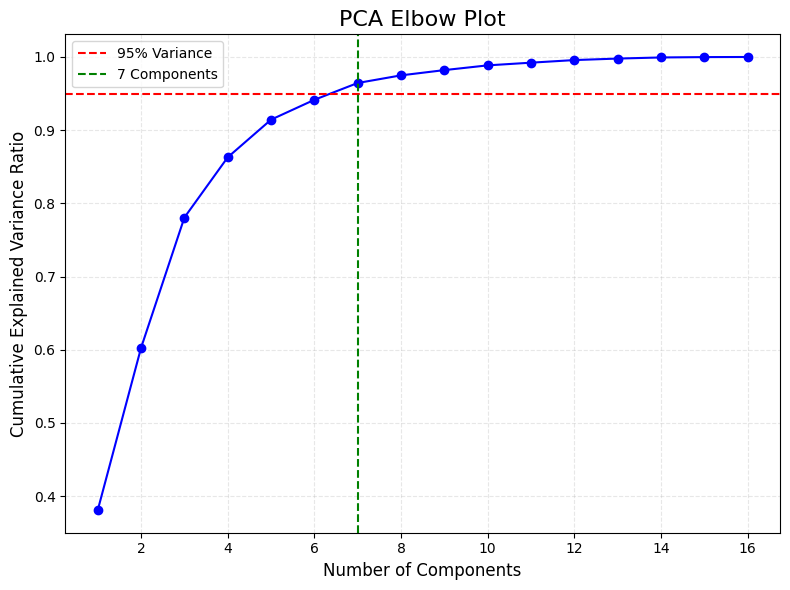

PCA Components: 7
Explained Variance Ratio: [0.38083695 0.22177222 0.17801677 0.08227693 0.0514392  0.02713697
 0.02297953]
Cumulative Explained Variance: 0.9645
PCA Loadings:
 [[ 0.27651386  0.15356773  0.23769806  0.28982507  0.27811869  0.2868283
   0.10167005 -0.10435431  0.20099235  0.13240558 -0.17831961  0.28532346
   0.3319782  -0.23838785  0.3443665   0.34906717]
 [ 0.31831665  0.22308163  0.21389109 -0.27048522 -0.34069685 -0.30119341
   0.3482561  -0.32780132  0.22928747  0.17886853 -0.24457477 -0.34113993
  -0.03130206 -0.16293582 -0.00071663 -0.07862083]
 [ 0.14452472  0.47345397  0.38656268  0.15886243 -0.00248874 -0.03353306
  -0.2373092   0.24574257  0.44109806 -0.2713643   0.30641111 -0.01280749
  -0.16193505  0.21902194 -0.10779937 -0.11990861]
 [ 0.16873964 -0.01709639  0.00855833  0.18994085  0.15478233  0.3004658
   0.16811657 -0.26187987 -0.01471758  0.32205103 -0.21710566  0.18255548
  -0.38229022  0.52015106 -0.11117214 -0.33248358]
 [-0.182946    0.05452498  0.

In [6]:
## Block 4: PCA with Elbow Plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle


def apply_pca(features):
    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # Fit PCA with maximum components to compute explained variance
    pca = PCA(n_components=None)  # Fit with all components first
    pca.fit(features_scaled)

    # Compute cumulative explained variance
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    n_components_95 = (
        np.argmax(cumulative_variance >= 0.95) + 1
    )  # Components for 95% variance

    # Plot elbow plot
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        marker="o",
        linestyle="-",
        color="b",
    )
    plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")
    plt.axvline(
        x=n_components_95,
        color="g",
        linestyle="--",
        label=f"{n_components_95} Components",
    )
    plt.xlabel("Number of Components", fontsize=12)
    plt.ylabel("Cumulative Explained Variance Ratio", fontsize=12)
    plt.title("PCA Elbow Plot", fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("pca_elbow_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Apply PCA with 95% variance
    pca = PCA(n_components=0.95)
    features_pca = pca.fit_transform(features_scaled)
    print(f"PCA Components: {pca.n_components_}")
    print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

    # Save results
    np.save("features_pca.npy", features_pca)
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open("pca_model.pkl", "wb") as f:
        pickle.dump(pca, f)

    return features_pca


# Load features from Block 3
features = np.load("features.npy", allow_pickle=True)  # Shape: (18160, 16)
features_pca = apply_pca(features)

# Load PCA model for verification
pca = pickle.load(open("pca_model.pkl", "rb"))
print("PCA Loadings:\n", pca.components_)

##  5. Data Splitting



In [7]:
def split_data(labels, output_dir="preprocessed_data"):
    # Convert labels to NumPy array for indexing
    labels = np.array(labels)
    # Split indices with stratification
    train_indices, test_indices = train_test_split(
        range(len(labels)), test_size=0.2, random_state=42, stratify=labels
    )
    print(f"Train: {len(train_indices)} samples, Test: {len(test_indices)} samples")

    # Use StratifiedKFold on training indices
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = [
        (train_idx, val_idx)
        for train_idx, val_idx in kf.split(
            np.zeros(len(train_indices)), labels[train_indices]
        )
    ]

    # Save splits
    os.makedirs(output_dir, exist_ok=True)
    np.save(os.path.join(output_dir, "train_indices.npy"), train_indices)
    np.save(os.path.join(output_dir, "test_indices.npy"), test_indices)
    with open(os.path.join(output_dir, "cv_splits.pkl"), "wb") as f:
        pickle.dump(cv_splits, f)
    print("Saved splits to preprocessed_data")

    # Check class proportions
    le = LabelEncoder()
    y = le.fit_transform(labels)
    train_labels = labels[train_indices]
    test_labels = labels[test_indices]
    original_counts = np.bincount(y)
    train_counts = np.bincount(le.transform(train_labels))
    test_counts = np.bincount(le.transform(test_labels))
    original_prop = original_counts / len(y)
    train_prop = train_counts / len(train_labels)
    test_prop = test_counts / len(test_labels)
    print("Original Class Proportions:", original_prop)
    print("Train Class Proportions:", train_prop)
    print("Test Class Proportions:", test_prop)
    assert np.allclose(
        original_prop, train_prop, atol=0.01
    ), "Train proportions mismatch"
    assert np.allclose(original_prop, test_prop, atol=0.01), "Test proportions mismatch"

    return train_indices, test_indices, cv_splits


train_indices, test_indices, cv_splits = split_data(labels)

Train: 14528 samples, Test: 3632 samples
Saved splits to preprocessed_data
Original Class Proportions: [0.11712555 0.05506608 0.10512115 0.05242291 0.09752203 0.09229075
 0.07731278 0.29498899 0.02053965 0.08761013]
Train Class Proportions: [0.11715308 0.05506608 0.10510738 0.05238161 0.09753579 0.09230452
 0.07729901 0.29501652 0.02051211 0.0876239 ]
Test Class Proportions: [0.11701542 0.05506608 0.10517621 0.05258811 0.09746696 0.09223568
 0.07736784 0.29487885 0.02064978 0.08755507]


## 6. Metrics and Statistical Tests



In [8]:
def compute_metrics(y_true, y_pred, model_name):
    true_classes = np.unique(y_true)
    pred_classes = np.unique(y_pred)
    present_classes = np.intersect1d(true_classes, pred_classes)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0, labels=present_classes
    )
    recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0, labels=present_classes
    )
    f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0, labels=present_classes
    )
    n_bootstraps = 100
    boot_acc = []
    rng = np.random.default_rng(42)
    for _ in range(n_bootstraps):
        indices = rng.choice(len(y_true), len(y_true), replace=True)
        boot_acc.append(accuracy_score(y_true[indices], y_pred[indices]))
    ci_lower, ci_upper = np.percentile(boot_acc, [2.5, 97.5])
    print(
        f"{model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, "
        f"Recall: {recall:.4f}, F1: {f1:.4f}, 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]"
    )
    return [accuracy, precision, recall, f1, ci_lower, ci_upper]


def mcnemar_test(y_true, y_pred1, y_pred2, model1_name, model2_name):
    n11 = n12 = n21 = n22 = 0
    for t, p1, p2 in zip(y_true, y_pred1, y_pred2):
        c1 = p1 == t
        c2 = p2 == t
        if c1 and c2:
            n11 += 1
        elif c1 and not c2:
            n12 += 1
        elif not c1 and c2:
            n21 += 1
        else:
            n22 += 1
    stat = ((n12 - n21) ** 2) / (n12 + n21 + 1e-10)
    p_value = 1 - stats.chi2.cdf(stat, df=1)
    print(
        f"McNemar's Test ({model1_name} vs. {model2_name}): Stat={stat:.4f}, p-value={p_value:.4f}"
    )
    return stat, p_value

## 7. Load and Encode Data, Check Proportions



In [9]:
features = np.load("features_pca.npy", allow_pickle=True)  # Shape: (18160, k)
labels = np.load("labels.npy", allow_pickle=True)
le = LabelEncoder()
y = le.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42, stratify=y
)
print(
    f"Train: {len(X_train)} samples, Test: {len(X_test)} samples, Features: {X_train.shape[1]}"
)
assert len(X_train) == 14528 and len(X_test) == 3632, f"Expected 14528 train, 3632 test"

# Check class proportions
original_counts = np.bincount(y)
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)
original_prop = original_counts / len(y)
train_prop = train_counts / len(y_train)
test_prop = test_counts / len(y_test)
print("Original Class Proportions:", original_prop)
print("Train Class Proportions:", train_prop)
print("Test Class Proportions:", test_prop)
assert np.allclose(original_prop, train_prop, atol=0.01), "Train proportions mismatch"
assert np.allclose(original_prop, test_prop, atol=0.01), "Test proportions mismatch"

# Apply SMOTE for kNN
smote = SMOTE(random_state=42)
X_train_knn, y_train_knn = smote.fit_resample(X_train, y_train)
print(
    f"After SMOTE (kNN) - Train: {len(X_train_knn)} samples, Class counts: {np.bincount(y_train_knn)}"
)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

Train: 14528 samples, Test: 3632 samples, Features: 7
Original Class Proportions: [0.11712555 0.05506608 0.10512115 0.05242291 0.09752203 0.09229075
 0.07731278 0.29498899 0.02053965 0.08761013]
Train Class Proportions: [0.11715308 0.05506608 0.10510738 0.05238161 0.09753579 0.09230452
 0.07729901 0.29501652 0.02051211 0.0876239 ]
Test Class Proportions: [0.11701542 0.05506608 0.10517621 0.05258811 0.09746696 0.09223568
 0.07736784 0.29487885 0.02064978 0.08755507]
After SMOTE (kNN) - Train: 42860 samples, Class counts: [4286 4286 4286 4286 4286 4286 4286 4286 4286 4286]


## 8. NN

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchviz import make_dot
import matplotlib.pyplot as plt


class PlantVillagePCADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.model(x)


def train_nn(model, train_loader, criterion, optimizer, num_epochs=50):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to("cpu"), y_batch.to("cpu")
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"NN Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


def evaluate_nn(model, test_loader):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to("cpu"), y_batch.to("cpu")
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_scores)


def plot_nn_architecture(model, input_dim, filename="nn_architecture.png"):
    # Create a sample input tensor
    x = torch.randn(1, input_dim)
    # Forward pass to create computational graph
    y = model(x)
    # Generate graph using torchviz
    dot = make_dot(y, params=dict(model.named_parameters()))
    dot.format = "png"
    dot.render(filename.split(".")[0], cleanup=True)
    print(f"NN architecture saved as {filename}")


train_dataset = PlantVillagePCADataset(X_train, y_train)
test_dataset = PlantVillagePCADataset(X_test, y_test)
train_loader_nn = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader_nn = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_dim = X_train.shape[1]  # PCA components (~10–12)
num_classes = len(np.unique(y))  # 10 classes
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    [len(y_train) / (num_classes * count) for count in class_counts],
    dtype=torch.float32,
).to("cpu")
criterion = nn.CrossEntropyLoss(weight=class_weights)
nn_model = SimpleNN(input_dim, num_classes).to("cpu")
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

# Plot architecture before training
plot_nn_architecture(nn_model, input_dim)

# Train and evaluate
train_nn(nn_model, train_loader_nn, criterion, optimizer, num_epochs=200)
y_true_nn, y_pred_nn, y_scores_nn = evaluate_nn(nn_model, test_loader_nn)
nn_metrics = compute_metrics(y_true_nn, y_pred_nn, "Neural Network")

torch.save(nn_model.state_dict(), "nn_model.pth")
np.save("nn_metrics.npy", np.array(nn_metrics))

NN architecture saved as nn_architecture.png
NN Epoch 1, Loss: 1.3475
NN Epoch 2, Loss: 0.9690
NN Epoch 3, Loss: 0.8769
NN Epoch 4, Loss: 0.8281
NN Epoch 5, Loss: 0.7919
NN Epoch 6, Loss: 0.7558
NN Epoch 7, Loss: 0.7377
NN Epoch 8, Loss: 0.7274
NN Epoch 9, Loss: 0.6980
NN Epoch 10, Loss: 0.6909
NN Epoch 11, Loss: 0.6809
NN Epoch 12, Loss: 0.6668
NN Epoch 13, Loss: 0.6638
NN Epoch 14, Loss: 0.6567
NN Epoch 15, Loss: 0.6478
NN Epoch 16, Loss: 0.6372
NN Epoch 17, Loss: 0.6372
NN Epoch 18, Loss: 0.6322
NN Epoch 19, Loss: 0.6248
NN Epoch 20, Loss: 0.6165
NN Epoch 21, Loss: 0.6066
NN Epoch 22, Loss: 0.6070
NN Epoch 23, Loss: 0.5975
NN Epoch 24, Loss: 0.5946
NN Epoch 25, Loss: 0.5890
NN Epoch 26, Loss: 0.5917
NN Epoch 27, Loss: 0.5822
NN Epoch 28, Loss: 0.5862
NN Epoch 29, Loss: 0.5773
NN Epoch 30, Loss: 0.5676
NN Epoch 31, Loss: 0.5701
NN Epoch 32, Loss: 0.5767
NN Epoch 33, Loss: 0.5601
NN Epoch 34, Loss: 0.5637
NN Epoch 35, Loss: 0.5543
NN Epoch 36, Loss: 0.5519
NN Epoch 37, Loss: 0.5519
NN

NN architecture saved as nn_architecture_clean.png


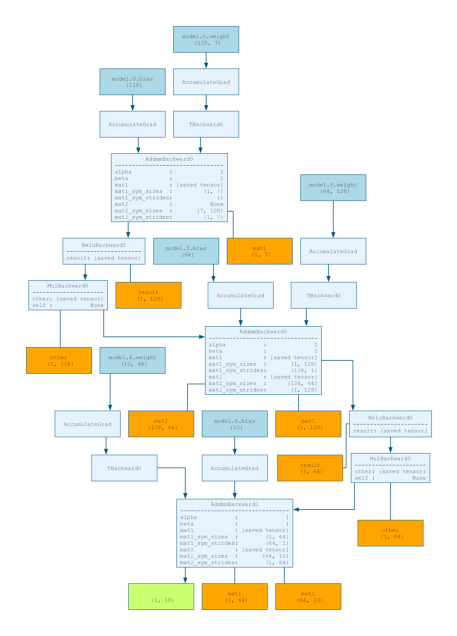

In [12]:
import torch
import torch.nn as nn
from torchviz import make_dot
import matplotlib.pyplot as plt


def plot_nn_architecture(model, input_dim, filename="nn_architecture_clean.png"):
    # Create a sample input tensor
    x = torch.randn(1, input_dim)
    # Forward pass to create computational graph
    y = model(x)

    # Generate graph with customized attributes
    dot = make_dot(
        y,
        params=dict(model.named_parameters()),
        show_attrs=True,  # Show layer attributes (e.g., weights, biases)
        show_saved=True,  # Show saved tensors (e.g., intermediate outputs)
    )

    # Customize graph attributes for clarity
    dot.graph_attr.update(
        {
            "dpi": "300",  # High resolution
            "fontsize": "14",  # Larger font for graph title
            "fontcolor": "black",
            "bgcolor": "white",
            "rankdir": "TB",  # Top-to-bottom layout
            "splines": "ortho",  # Straight edges for cleaner look
            "pad": "0.5",  # Padding around graph
        }
    )

    # Customize node attributes
    dot.node_attr.update(
        {
            "shape": "box",  # Box shape for layers
            "style": "filled",  # Filled nodes for visibility
            "fillcolor": "#e6f3ff",  # Light blue fill
            "color": "#005580",  # Dark blue border
            "fontsize": "12",  # Larger font for node labels
            "fontcolor": "black",
            "width": "2",  # Wider nodes for readability
            "height": "0.8",
        }
    )

    # Customize edge attributes
    dot.edge_attr.update(
        {
            "color": "#005580",  # Dark blue edges
            "penwidth": "1.5",  # Thicker edges
        }
    )

    # Render and save the graph
    dot.format = "png"
    dot.render(filename.split(".")[0], cleanup=True)
    print(f"NN architecture saved as {filename}")

    # Display the image using matplotlib for verification
    img = plt.imread(filename)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Example usage (assumes model and input_dim are defined)
input_dim = X_train.shape[1]  # PCA components (~10–12)
num_classes = len(np.unique(y))  # 10 classes
nn_model = SimpleNN(input_dim, num_classes).to("cpu")
plot_nn_architecture(nn_model, input_dim)

Custom NN architecture saved as nn_architecture_custom.png


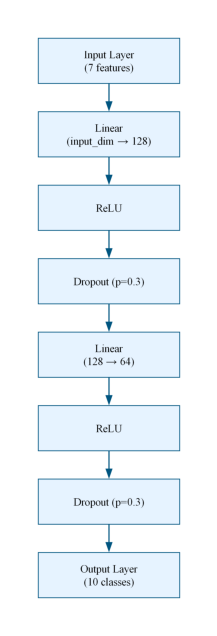

In [11]:
from graphviz import Digraph


def plot_custom_nn_architecture(
    input_dim, num_classes, filename="nn_architecture_custom.png"
):
    # Initialize Digraph
    dot = Digraph(
        comment="SimpleNN Architecture",
        format="png",
        graph_attr={
            "dpi": "300",
            "fontsize": "16",
            "fontcolor": "black",
            "bgcolor": "white",
            "rankdir": "TB",
            "splines": "ortho",
            "pad": "0.5",
        },
        node_attr={
            "shape": "box",
            "style": "filled",
            "fillcolor": "#e6f3ff",
            "color": "#005580",
            "fontsize": "14",
            "fontcolor": "black",
            "width": "2.5",
            "height": "0.8",
        },
        edge_attr={
            "color": "#005580",
            "penwidth": "1.5",
        },
    )

    # Add nodes for layers
    dot.node("input", f"Input Layer\n({input_dim} features)")
    dot.node("linear1", "Linear\n(input_dim → 128)")
    dot.node("relu1", "ReLU")
    dot.node("dropout1", "Dropout (p=0.3)")
    dot.node("linear2", "Linear\n(128 → 64)")
    dot.node("relu2", "ReLU")
    dot.node("dropout2", "Dropout (p=0.3)")
    dot.node("output", f"Output Layer\n({num_classes} classes)")

    # Add edges
    dot.edges(
        [
            ("input", "linear1"),
            ("linear1", "relu1"),
            ("relu1", "dropout1"),
            ("dropout1", "linear2"),
            ("linear2", "relu2"),
            ("relu2", "dropout2"),
            ("dropout2", "output"),
        ]
    )

    # Render and save
    dot.render(filename.split(".")[0], cleanup=True)
    print(f"Custom NN architecture saved as {filename}")

    # Display using matplotlib
    img = plt.imread(filename)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Example usage
input_dim = X_train.shape[1]  # PCA components (~10–12)
num_classes = len(np.unique(y))  # 10 classes
plot_custom_nn_architecture(input_dim, num_classes)

## 9. SVM

Best SVM params: {'C': 100, 'class_weight': None, 'kernel': 'rbf'}
SVM - Accuracy: 0.8742, Precision: 0.8550, Recall: 0.8481, F1: 0.8511, 95% CI: [0.8644, 0.8834]


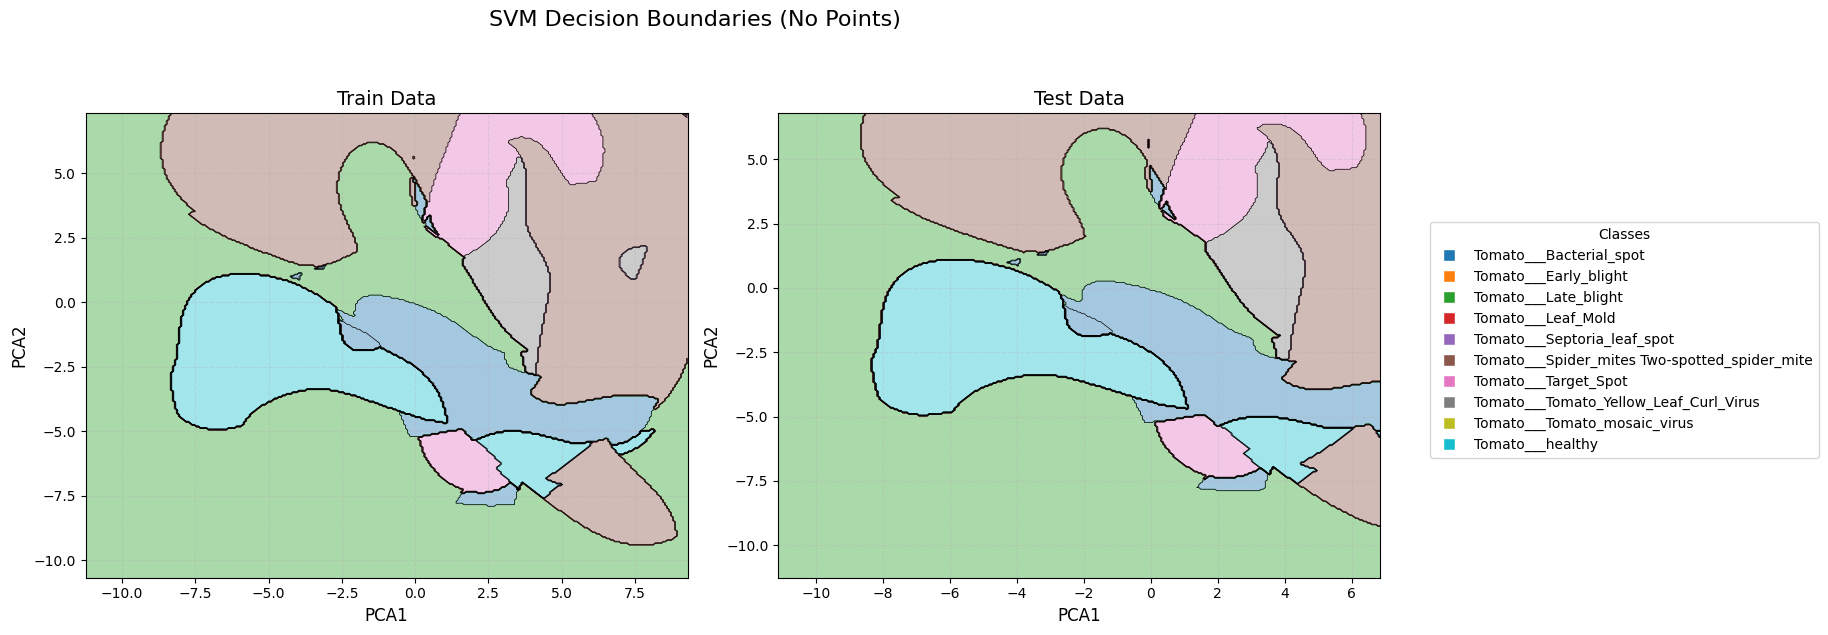

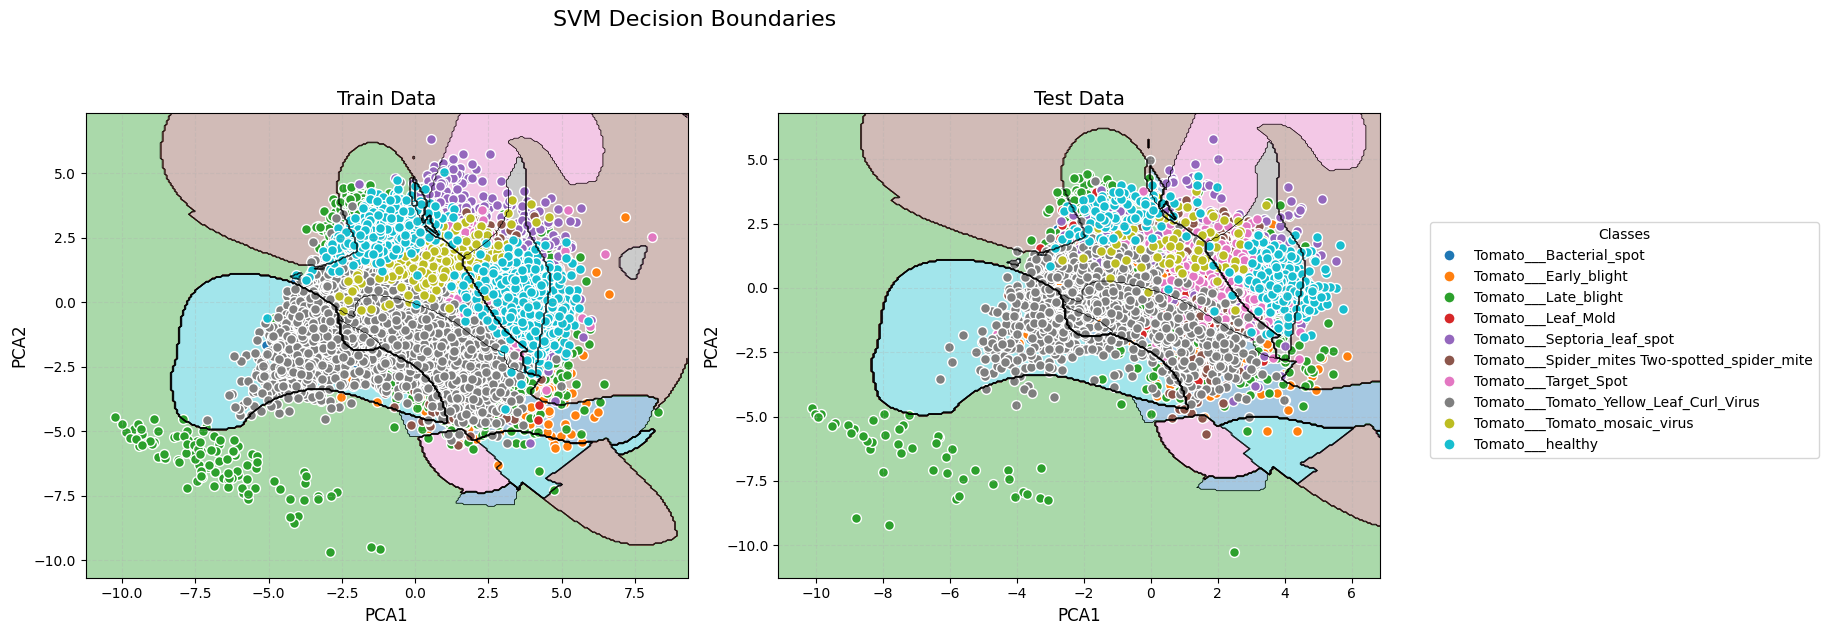

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pickle

# SVM Training
svm = SVC(random_state=42, probability=True)
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "class_weight": ["balanced", None],
}
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_
print(f"Best SVM params: {grid_search.best_params_}")
y_pred_svm = best_svm.predict(X_test)
y_scores_svm = best_svm.predict_proba(X_test)
svm_metrics = compute_metrics(y_test, y_pred_svm, "SVM")

with open("svm_model.pkl", "wb") as f:
    pickle.dump(best_svm, f)
np.save("svm_metrics.npy", np.array(svm_metrics))


# New Function: Plot Only SVM Decision Boundaries
def plot_svm_boundaries_only(
    model, X_train, X_test, le, title="SVM Decision Boundaries (No Points)"
):
    pca_plot = PCA(n_components=2)
    X_train_plot = pca_plot.fit_transform(X_train)
    X_test_plot = pca_plot.transform(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    datasets = [
        ("Train Data", X_train_plot, X_train),
        ("Test Data", X_test_plot, X_test),
    ]
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax, (name, X_plot, X_orig) in zip(axes, datasets):
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300)
        )
        Z = model.predict(pca_plot.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(colors))
        ax.contour(xx, yy, Z, colors="black", linewidths=0.5)

        ax.set_xlabel("PCA1", fontsize=12)
        ax.set_ylabel("PCA2", fontsize=12)
        ax.set_title(name, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.3)

    fig.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                label=cls,
                markerfacecolor=colors[i],
                markersize=8,
            )
            for i, cls in enumerate(le.classes_)
        ],
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )
    fig.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig("svm_boundaries_only.png", dpi=300, bbox_inches="tight")
    plt.show()


# Original Function: Plot SVM Decision Boundaries with Points
def plot_svm_boundaries(
    model, X_train, y_train, X_test, y_test, le, title="SVM Decision Boundaries"
):
    pca_plot = PCA(n_components=2)
    X_train_plot = pca_plot.fit_transform(X_train)
    X_test_plot = pca_plot.transform(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    datasets = [
        ("Train Data", X_train_plot, X_train, y_train),
        ("Test Data", X_test_plot, X_test, y_test),
    ]
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax, (name, X_plot, X_orig, y) in zip(axes, datasets):
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300)
        )
        Z = model.predict(pca_plot.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(colors))
        ax.contour(xx, yy, Z, colors="black", linewidths=0.5)

        for i, cls in enumerate(le.classes_):
            idx = y == le.transform([cls])[0]
            ax.scatter(
                X_plot[idx, 0],
                X_plot[idx, 1],
                c=[colors[i]],
                label=cls,
                s=50,
                edgecolors="white",
            )

        ax.set_xlabel("PCA1", fontsize=12)
        ax.set_ylabel("PCA2", fontsize=12)
        ax.set_title(name, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.3)

    fig.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=cls,
                markerfacecolor=colors[i],
                markersize=8,
            )
            for i, cls in enumerate(le.classes_)
        ],
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )
    fig.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig("svm_boundaries.png", dpi=300, bbox_inches="tight")
    plt.show()


# Call both plotting functions
plot_svm_boundaries_only(best_svm, X_train, X_test, le)
plot_svm_boundaries(best_svm, X_train, y_train, X_test, y_test, le)

## 10. Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pickle
import graphviz

# Decision Tree Training
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "class_weight": ["balanced", None],
}
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f"Best Decision Tree params: {grid_search.best_params_}")
y_pred_dt = best_dt.predict(X_test)
y_scores_dt = best_dt.predict_proba(X_test)
dt_metrics = compute_metrics(y_test, y_pred_dt, "Decision Tree")

with open("dt_model.pkl", "wb") as f:
    pickle.dump(best_dt, f)
np.save("dt_metrics.npy", np.array(dt_metrics))

# Decision Tree Visualization
feature_names = [f"PC{i+1}" for i in range(X_train.shape[1])]

# Top 3 levels
dot_data_top3 = export_graphviz(
    best_dt,
    out_file=None,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=True,
    max_depth=3,
)
graph_top3 = graphviz.Source(dot_data_top3)
graph_top3.render("decision_tree_top3", format="pdf", cleanup=True)
print("Decision Tree (top 3 levels) saved as decision_tree_top3.pdf")

# Full Decision Tree
dot_data_full = export_graphviz(
    best_dt,
    out_file=None,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=True,
)
graph_full = graphviz.Source(dot_data_full)
graph_full.render("decision_tree_full", format="pdf", cleanup=True)
print("Full Decision Tree saved as decision_tree_full.pdf")

Best Decision Tree params: {'class_weight': None, 'max_depth': 20, 'min_samples_split': 10}
Decision Tree - Accuracy: 0.7525, Precision: 0.7106, Recall: 0.7070, F1: 0.7085, 95% CI: [0.7405, 0.7659]
Decision Tree (top 3 levels) saved as decision_tree_top3.pdf
Full Decision Tree saved as decision_tree_full.pdf


## 11. RF

In [13]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "class_weight": ["balanced", None],
    "max_leaf_nodes": [100, 200, None],
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best RF params: {grid_search.best_params_}")
y_pred_rf = best_rf.predict(X_test)
y_scores_rf = best_rf.predict_proba(X_test)
rf_metrics = compute_metrics(y_test, y_pred_rf, "Random Forest")

with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)
np.save("rf_metrics.npy", np.array(rf_metrics))

Best RF params: {'class_weight': 'balanced', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest - Accuracy: 0.8389, Precision: 0.8185, Recall: 0.7989, F1: 0.8062, 95% CI: [0.8318, 0.8511]


## 12. KNN

Best kNN params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
kNN - Accuracy: 0.8100, Precision: 0.7690, Recall: 0.7916, F1: 0.7794, 95% CI: [0.7983, 0.8209]


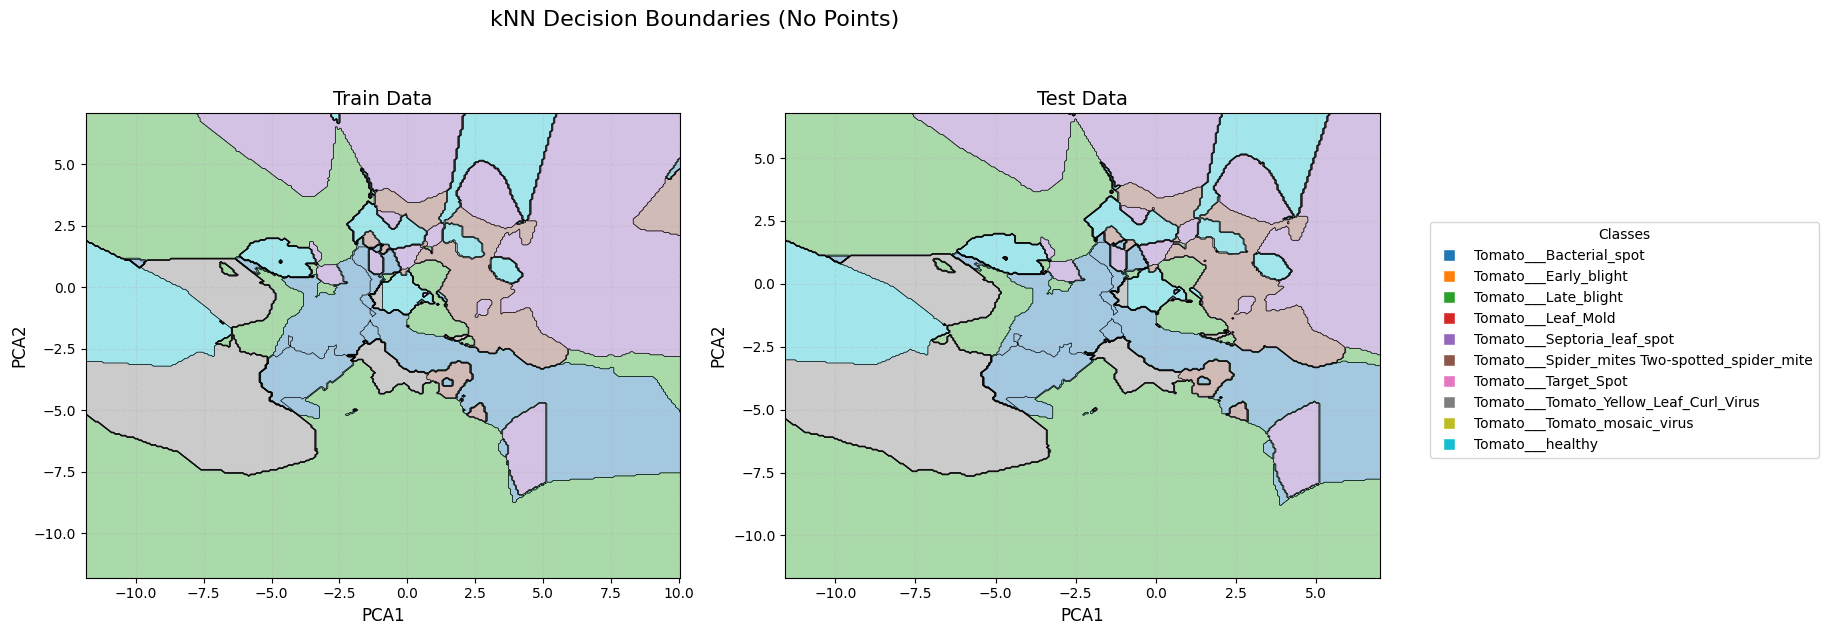

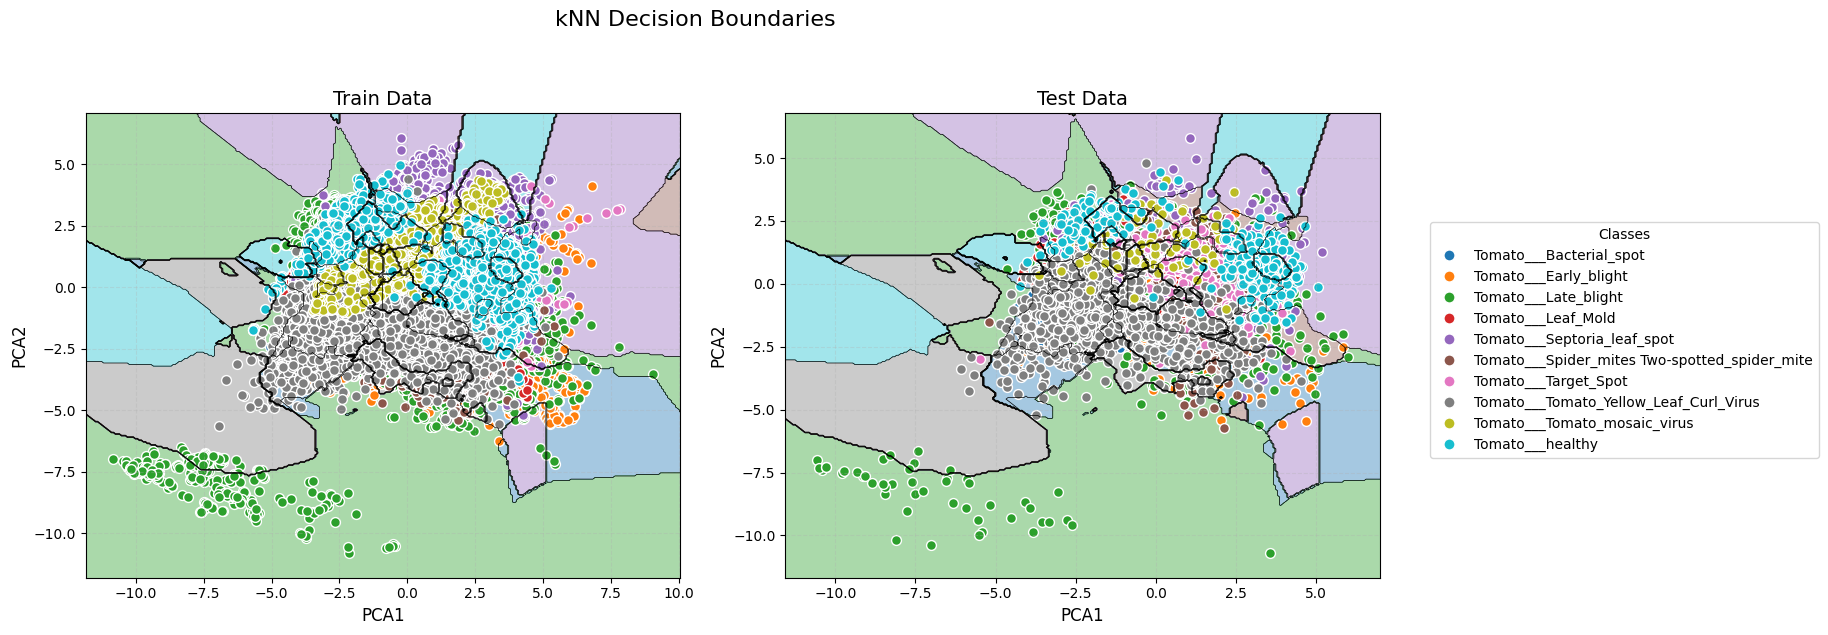

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pickle

# kNN Training
knn = KNeighborsClassifier(n_jobs=-1)
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_knn, y_train_knn)  # Use SMOTE data

best_knn = grid_search.best_estimator_
print(f"Best kNN params: {grid_search.best_params_}")
y_pred_knn = best_knn.predict(X_test)
y_scores_knn = best_knn.predict_proba(X_test)
knn_metrics = compute_metrics(y_test, y_pred_knn, "kNN")

with open("knn_model.pkl", "wb") as f:
    pickle.dump(best_knn, f)
np.save("knn_metrics.npy", np.array(knn_metrics))


# New Function: Plot Only kNN Decision Boundaries
def plot_knn_boundaries_only(
    model, X_train, X_test, le, title="kNN Decision Boundaries (No Points)"
):
    pca_plot = PCA(n_components=2)
    X_train_plot = pca_plot.fit_transform(X_train)
    X_test_plot = pca_plot.transform(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    datasets = [
        ("Train Data", X_train_plot, X_train),
        ("Test Data", X_test_plot, X_test),
    ]
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax, (name, X_plot, X_orig) in zip(axes, datasets):
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300)
        )
        Z = model.predict(pca_plot.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(colors))
        ax.contour(xx, yy, Z, colors="black", linewidths=0.5)

        ax.set_xlabel("PCA1", fontsize=12)
        ax.set_ylabel("PCA2", fontsize=12)
        ax.set_title(name, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.3)

    fig.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                label=cls,
                markerfacecolor=colors[i],
                markersize=8,
            )
            for i, cls in enumerate(le.classes_)
        ],
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )
    fig.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig("knn_boundaries_only.png", dpi=300, bbox_inches="tight")
    plt.show()


# Original Function: Plot kNN Decision Boundaries with Points
def plot_knn_boundaries(
    model, X_train, y_train, X_test, y_test, le, title="kNN Decision Boundaries"
):
    pca_plot = PCA(n_components=2)
    X_train_plot = pca_plot.fit_transform(X_train)
    X_test_plot = pca_plot.transform(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    datasets = [
        ("Train Data", X_train_plot, X_train, y_train),
        ("Test Data", X_test_plot, X_test, y_test),
    ]
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax, (name, X_plot, X_orig, y) in zip(axes, datasets):
        x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300)
        )
        Z = model.predict(pca_plot.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(colors))
        ax.contour(xx, yy, Z, colors="black", linewidths=0.5)

        for i, cls in enumerate(le.classes_):
            idx = y == le.transform([cls])[0]
            ax.scatter(
                X_plot[idx, 0],
                X_plot[idx, 1],
                c=[colors[i]],
                label=cls,
                s=50,
                edgecolors="white",
            )

        ax.set_xlabel("PCA1", fontsize=12)
        ax.set_ylabel("PCA2", fontsize=12)
        ax.set_title(name, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.3)

    fig.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=cls,
                markerfacecolor=colors[i],
                markersize=8,
            )
            for i, cls in enumerate(le.classes_)
        ],
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )
    fig.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig("knn_boundaries.png", dpi=300, bbox_inches="tight")
    plt.show()


# Call both plotting functions
plot_knn_boundaries_only(best_knn, X_train_knn, X_test, le)
plot_knn_boundaries(best_knn, X_train_knn, y_train_knn, X_test, y_test, le)

## 13. Logistic Regression

In [15]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_scores_lr = lr.predict_proba(X_test)
lr_metrics = compute_metrics(y_test, y_pred_lr, "Logistic Regression")

Logistic Regression - Accuracy: 0.6333, Precision: 0.5806, Recall: 0.6353, F1: 0.5956, 95% CI: [0.6217, 0.6481]


## 14. Cross-Validation Stability


In [16]:
def compute_cv_stability(X, y, model, model_name, cv_splits=5):
    kf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    cv_accuracies = []
    for train_idx, val_idx in kf.split(X, y):
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_val_cv)
        cv_accuracies.append(accuracy_score(y_val_cv, y_pred_cv))
    cv_mean = np.mean(cv_accuracies)
    cv_std = np.std(cv_accuracies)
    cv_coef = cv_std / cv_mean
    print(
        f"{model_name} CV Stability - Mean Accuracy: {cv_mean:.4f}, CV: {cv_coef:.4f}"
    )
    return cv_accuracies


def compute_cv_stability_nn(X, y, input_dim, num_classes, cv_splits=5):
    kf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    cv_accuracies = []
    for train_idx, val_idx in kf.split(X, y):
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        train_dataset_cv = PlantVillagePCADataset(X_train_cv, y_train_cv)
        val_dataset_cv = PlantVillagePCADataset(X_val_cv, y_val_cv)
        train_loader_cv = DataLoader(train_dataset_cv, batch_size=32, shuffle=True)
        val_loader_cv = DataLoader(val_dataset_cv, batch_size=32, shuffle=False)
        model_cv = SimpleNN(input_dim, num_classes).to("cpu")
        class_counts = np.bincount(y_train_cv)
        class_weights = torch.tensor(
            [len(y_train_cv) / (num_classes * count) for count in class_counts],
            dtype=torch.float32,
        ).to("cpu")
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(model_cv.parameters(), lr=0.001)
        train_nn(model_cv, train_loader_cv, criterion, optimizer, num_epochs=50)
        y_true_cv, y_pred_cv, _ = evaluate_nn(model_cv, val_loader_cv)
        cv_accuracies.append(accuracy_score(y_true_cv, y_pred_cv))
    cv_mean = np.mean(cv_accuracies)
    cv_std = np.std(cv_accuracies)
    cv_coef = cv_std / cv_mean
    print(f"NN CV Stability - Mean Accuracy: {cv_mean:.4f}, CV: {cv_coef:.4f}")
    return cv_accuracies


nn_cv = compute_cv_stability_nn(X_train, y_train, input_dim, num_classes)
svm_cv = compute_cv_stability(X_train, y_train, best_svm, "SVM")
dt_cv = compute_cv_stability(X_train, y_train, best_dt, "Decision Tree")
rf_cv = compute_cv_stability(X_train, y_train, best_rf, "Random Forest")
knn_cv = compute_cv_stability(X_train_knn, y_train_knn, best_knn, "kNN")

np.save("nn_cv_accuracies.npy", np.array(nn_cv))
np.save("svm_cv_accuracies.npy", np.array(svm_cv))
np.save("dt_cv_accuracies.npy", np.array(dt_cv))
np.save("rf_cv_accuracies.npy", np.array(rf_cv))
np.save("knn_cv_accuracies.npy", np.array(knn_cv))

NN Epoch 1, Loss: 1.4307
NN Epoch 2, Loss: 1.0174
NN Epoch 3, Loss: 0.9222
NN Epoch 4, Loss: 0.8680
NN Epoch 5, Loss: 0.8103
NN Epoch 6, Loss: 0.7852
NN Epoch 7, Loss: 0.7774
NN Epoch 8, Loss: 0.7459
NN Epoch 9, Loss: 0.7235
NN Epoch 10, Loss: 0.7222
NN Epoch 11, Loss: 0.7042
NN Epoch 12, Loss: 0.6821
NN Epoch 13, Loss: 0.6877
NN Epoch 14, Loss: 0.6747
NN Epoch 15, Loss: 0.6581
NN Epoch 16, Loss: 0.6596
NN Epoch 17, Loss: 0.6509
NN Epoch 18, Loss: 0.6437
NN Epoch 19, Loss: 0.6422
NN Epoch 20, Loss: 0.6269
NN Epoch 21, Loss: 0.6284
NN Epoch 22, Loss: 0.6200
NN Epoch 23, Loss: 0.6234
NN Epoch 24, Loss: 0.6118
NN Epoch 25, Loss: 0.6081
NN Epoch 26, Loss: 0.6054
NN Epoch 27, Loss: 0.5960
NN Epoch 28, Loss: 0.5923
NN Epoch 29, Loss: 0.5858
NN Epoch 30, Loss: 0.5892
NN Epoch 31, Loss: 0.5955
NN Epoch 32, Loss: 0.5810
NN Epoch 33, Loss: 0.5857
NN Epoch 34, Loss: 0.5824
NN Epoch 35, Loss: 0.5798
NN Epoch 36, Loss: 0.5694
NN Epoch 37, Loss: 0.5730
NN Epoch 38, Loss: 0.5641
NN Epoch 39, Loss: 0.

## 15. Feature Importance



SVM permutation importance shape: (7,)
SVM PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
SVM Feature Importance (PCA, Sorted): {'PC1': np.float64(0.412028472631045), 'PC3': np.float64(0.3232948023553109), 'PC2': np.float64(0.3125905765281698), 'PC4': np.float64(0.24857328452469182), 'PC6': np.float64(0.24830778151024396), 'PC7': np.float64(0.24791170278982086), 'PC5': np.float64(0.22501470284990033)}
SVM Feature Importance (Original, Sorted): {'RGB_mean_R': np.float64(0.3313703154141706), 'HSV_mean_V': np.float64(0.3274922666908845), 'HSV_mean_H': np.float64(0.28508893099649046), 'GLCM_entropy': np.float64(0.25701132581729297), 'RGB_mean_G': np.float64(0.23878018027294995), 'RGB_mean_B': np.float64(0.22642281757506683), 'RGB_var_R': np.float64(0.2247485731599988), 'HSV_mean_S': np.float64(0.1418822022880847), 'HSV_var_S': np.float64(0.13803401867402387), 'HSV_var_H': np.float64(0.125334302471106), 'RGB_var_B': np.float64(0.

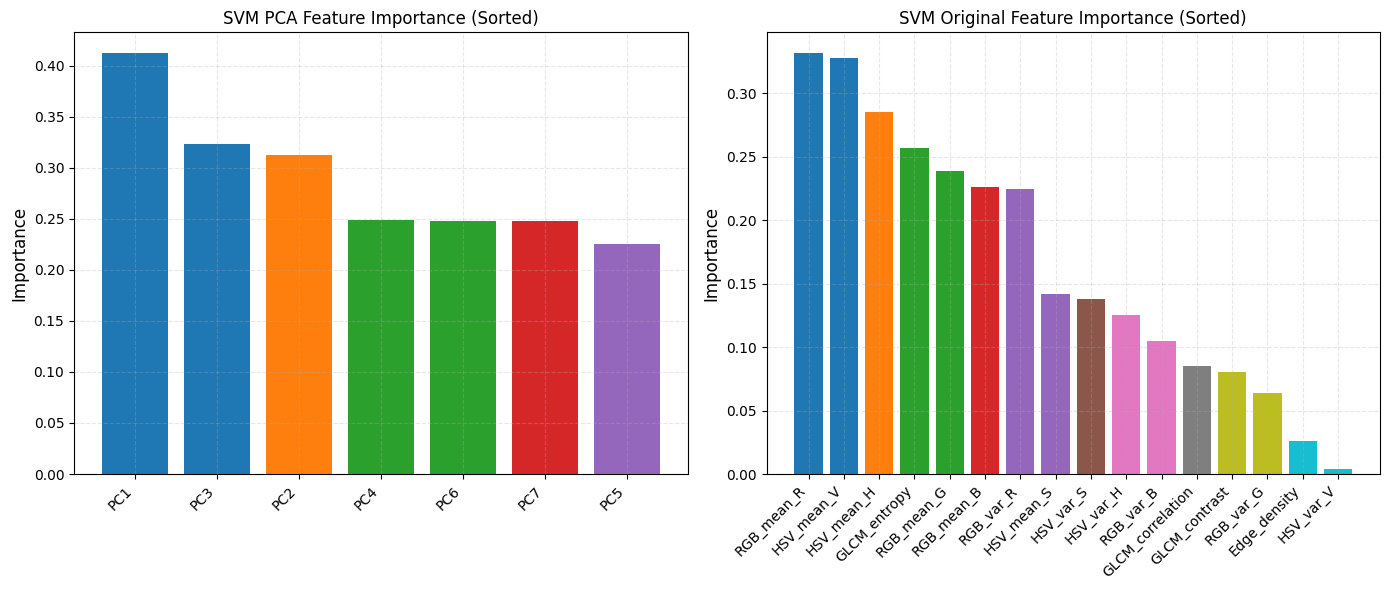

Decision Tree feature_importances_ shape: (7,)
Decision Tree PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
Decision Tree Feature Importance (PCA, Sorted): {'PC4': np.float64(0.16743094339450337), 'PC2': np.float64(0.16673298899130087), 'PC3': np.float64(0.15646614094472375), 'PC1': np.float64(0.15061505191895172), 'PC7': np.float64(0.13422895130927648), 'PC6': np.float64(0.11390398674738629), 'PC5': np.float64(0.11062193669385753)}
Decision Tree Feature Importance (Original, Sorted): {'RGB_mean_R': np.float64(0.16300758832762302), 'HSV_mean_H': np.float64(0.15749277658049082), 'HSV_mean_V': np.float64(0.15195637589848748), 'RGB_mean_G': np.float64(0.10989328130954634), 'RGB_var_R': np.float64(0.10386249424346056), 'GLCM_entropy': np.float64(0.09878082466183184), 'RGB_mean_B': np.float64(0.0976060887381762), 'GLCM_correlation': np.float64(0.07420028280777805), 'GLCM_contrast': np.float64(0.07307782470756796), 'HSV_var_S': np

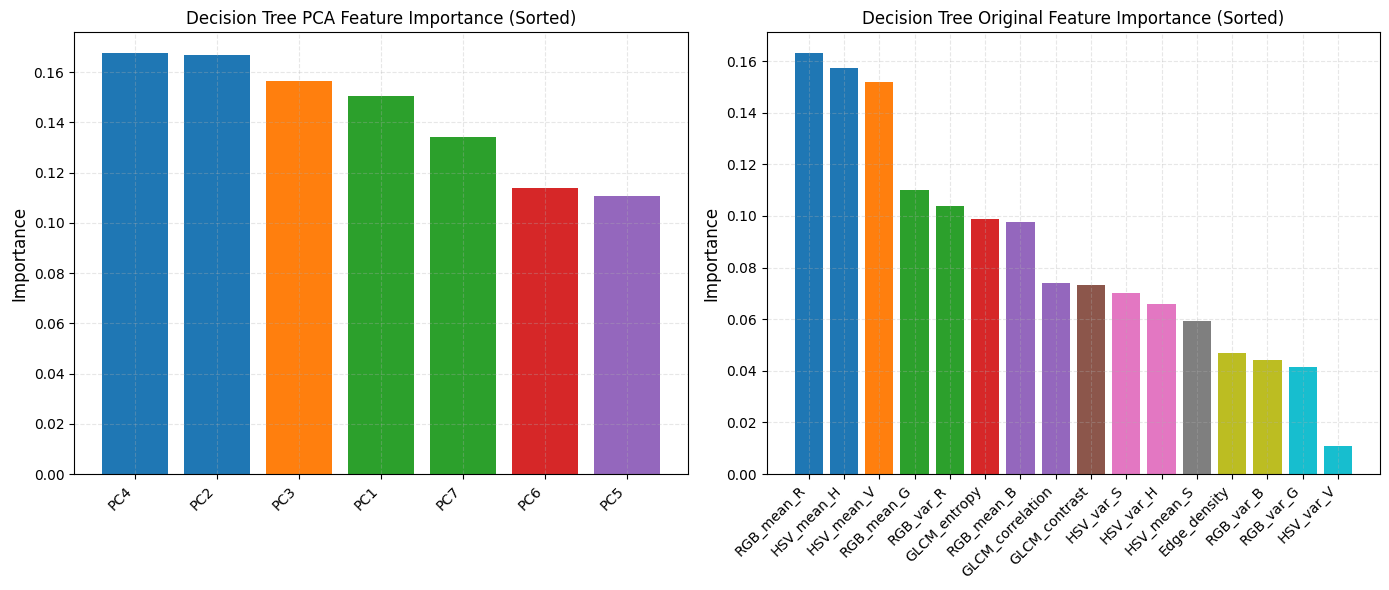

Random Forest feature_importances_ shape: (7,)
Random Forest PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
Random Forest Feature Importance (PCA, Sorted): {'PC7': np.float64(0.16763259864100144), 'PC1': np.float64(0.15875321930766706), 'PC4': np.float64(0.15431496228451494), 'PC3': np.float64(0.14020487996188202), 'PC2': np.float64(0.13224251685138017), 'PC6': np.float64(0.13150211831700792), 'PC5': np.float64(0.11534970463654647)}
Random Forest Feature Importance (Original, Sorted): {'HSV_mean_H': np.float64(0.16545647959607598), 'RGB_mean_R': np.float64(0.1579731394491685), 'HSV_mean_V': np.float64(0.1416466194916208), 'RGB_var_R': np.float64(0.11905904672166417), 'GLCM_entropy': np.float64(0.11609801959453761), 'RGB_mean_G': np.float64(0.09053021168516802), 'HSV_mean_S': np.float64(0.08898175014118877), 'RGB_mean_B': np.float64(0.07662483557184155), 'HSV_var_S': np.float64(0.07401977357670082), 'GLCM_correlation': np.flo

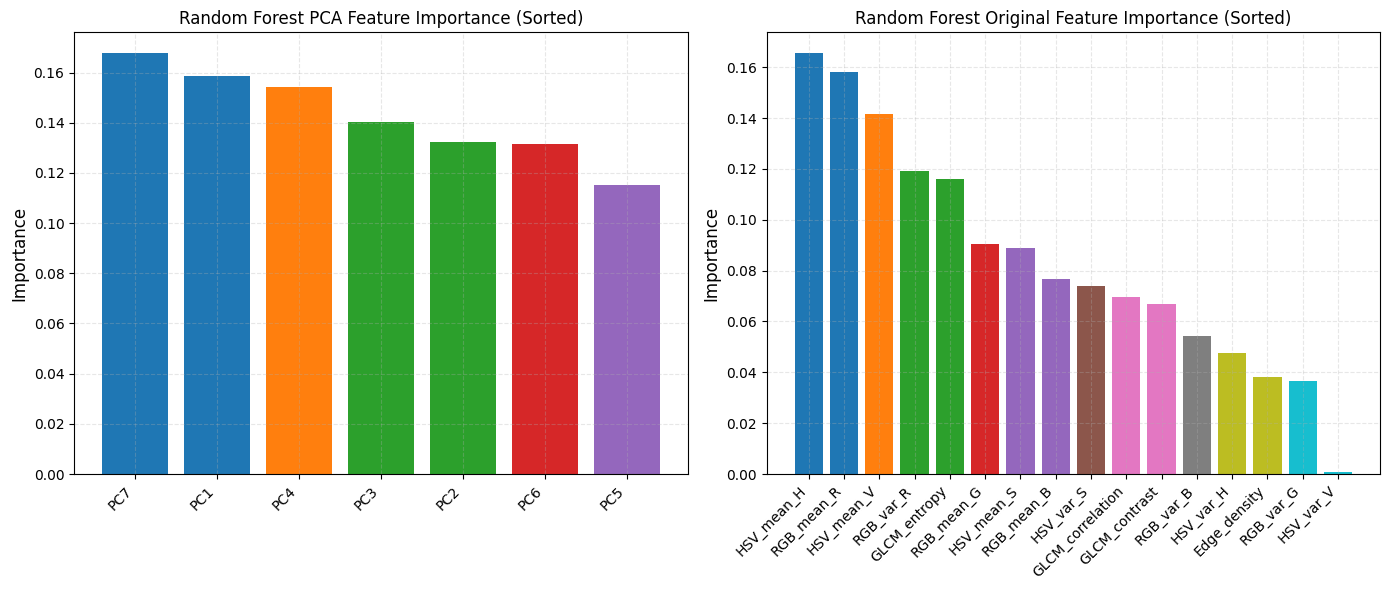

kNN permutation importance shape: (7,)
kNN PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
kNN Feature Importance (PCA, Sorted): {'PC1': np.float64(0.35971613344982234), 'PC3': np.float64(0.298452279620124), 'PC2': np.float64(0.24971536946901632), 'PC4': np.float64(0.1886017519475368), 'PC5': np.float64(0.166548318950929), 'PC7': np.float64(0.14443226481995802), 'PC6': np.float64(0.08766428611057704)}
kNN Feature Importance (Original, Sorted): {'HSV_mean_V': np.float64(0.27579947216319833), 'RGB_mean_R': np.float64(0.2631562500619835), 'RGB_mean_G': np.float64(0.23217672669374934), 'RGB_mean_B': np.float64(0.217128435385751), 'HSV_mean_H': np.float64(0.21233387735327386), 'RGB_var_R': np.float64(0.18318551886417542), 'GLCM_entropy': np.float64(0.14399860804601358), 'HSV_var_H': np.float64(0.10577589609029617), 'RGB_var_B': np.float64(0.07416010719795774), 'HSV_var_S': np.float64(0.05562877273870682), 'HSV_mean_S': np.float64(

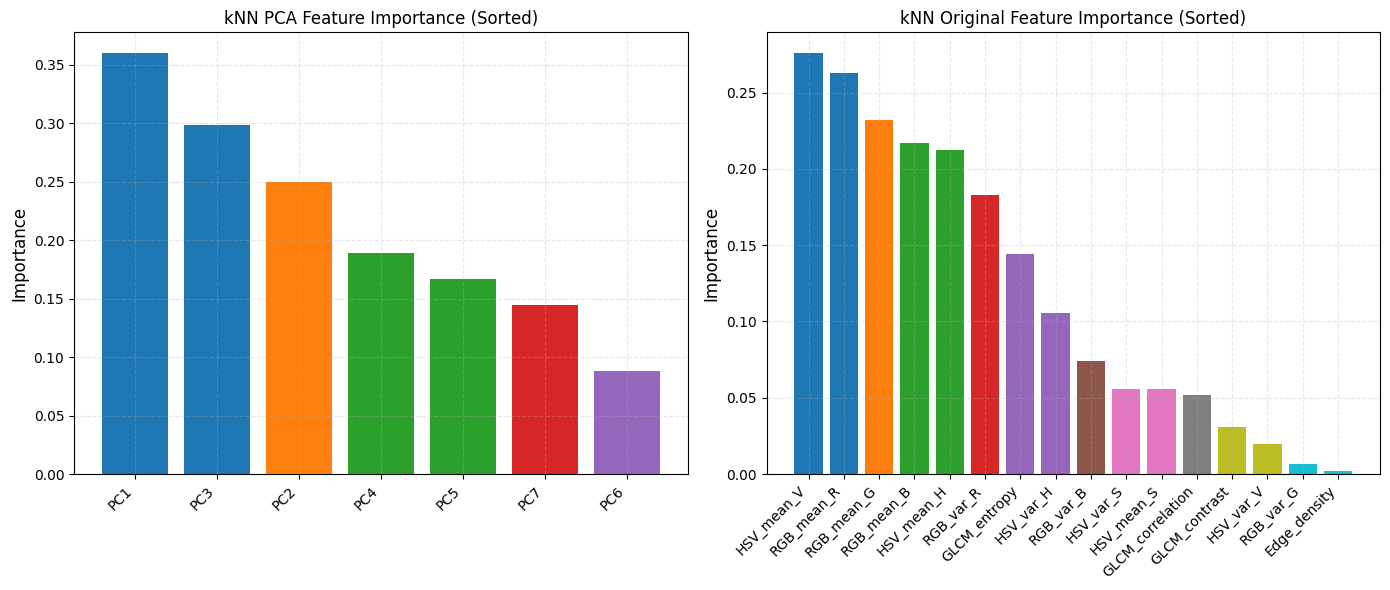

Neural Network permutation importance shape: (7,)
Neural Network PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
Neural Network Feature Importance (PCA, Sorted): {'PC1': np.float64(0.3405559463142433), 'PC3': np.float64(0.2702355179454944), 'PC2': np.float64(0.2576755801611914), 'PC6': np.float64(0.2524183116523552), 'PC7': np.float64(0.22115311213340966), 'PC4': np.float64(0.219951505217798), 'PC5': np.float64(0.20295195749586234)}
Neural Network Feature Importance (Original, Sorted): {'RGB_mean_R': np.float64(0.278779702875197), 'HSV_mean_V': np.float64(0.2757964270391257), 'GLCM_entropy': np.float64(0.24109807217917217), 'HSV_mean_H': np.float64(0.2404646682715845), 'RGB_var_R': np.float64(0.19366167335422546), 'RGB_mean_G': np.float64(0.19227609223370037), 'RGB_mean_B': np.float64(0.18442591299482086), 'HSV_mean_S': np.float64(0.1456178590714867), 'HSV_var_S': np.float64(0.13016866045635359), 'HSV_var_H': np.float64(0.111

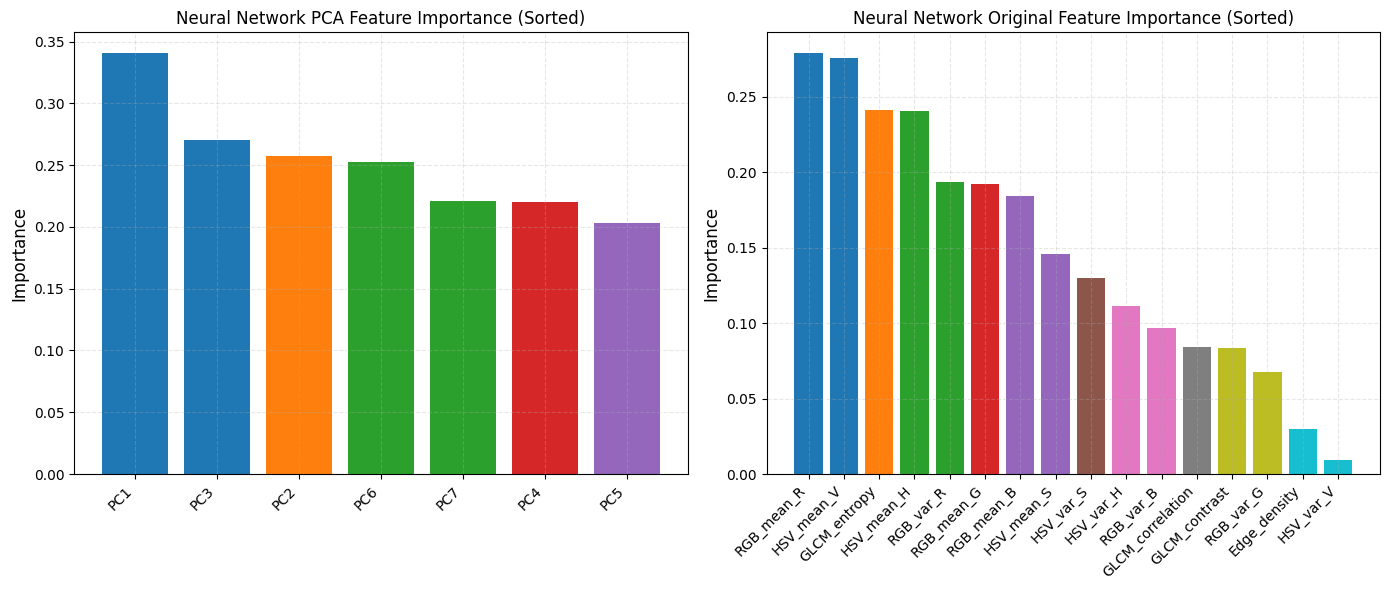

Logistic Regression coef_ shape: (10, 7)
Logistic Regression PCA components: 7, Importance shape: (7,)
PCA components_.T shape: (16, 7), Original importance shape: (16,)
Logistic Regression Feature Importance (PCA, Sorted): {'PC6': np.float64(2.083624702029246), 'PC7': np.float64(1.789070076592863), 'PC3': np.float64(1.0791219952357198), 'PC1': np.float64(1.0610316778901319), 'PC5': np.float64(0.842097609712817), 'PC4': np.float64(0.8053744207886631), 'PC2': np.float64(0.6398080233805302)}
Logistic Regression Feature Importance (Original, Sorted): {'GLCM_entropy': np.float64(1.5241032407364008), 'HSV_mean_S': np.float64(1.4982634251256632), 'RGB_mean_R': np.float64(1.149902044702191), 'HSV_mean_V': np.float64(1.0662930632874912), 'HSV_mean_H': np.float64(1.0536085018494026), 'RGB_var_R': np.float64(0.9561272918071142), 'HSV_var_S': np.float64(0.8777894349902786), 'GLCM_contrast': np.float64(0.665589702011285), 'RGB_var_G': np.float64(0.6045402193946986), 'GLCM_correlation': np.float64(

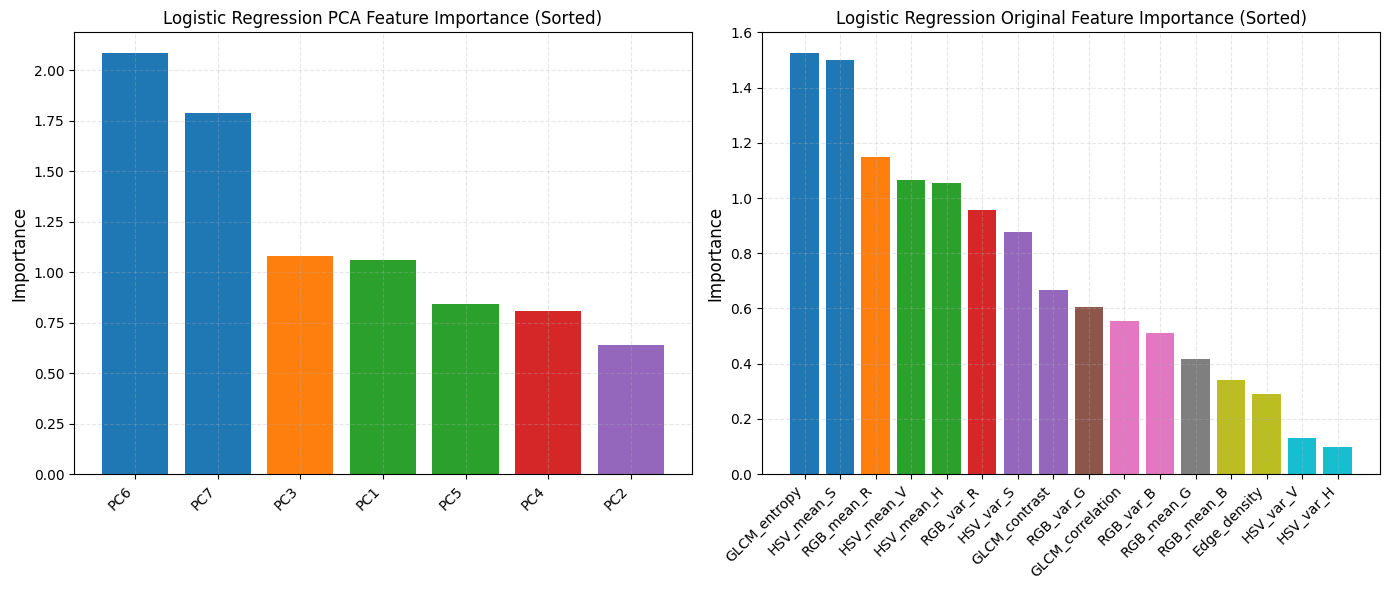

In [17]:
## Block 15: Feature Importance with Sorted Plots
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import torch


# Wrapper for PyTorch NN to make it scikit-learn compatible
class NNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, device="cpu"):
        self.model = model
        self.device = device

    def fit(self, X, y):
        # Already trained, no-op
        return self

    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            preds = torch.argmax(outputs, dim=1)
        return preds.cpu().numpy()

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = torch.softmax(outputs, dim=1)
        return probs.cpu().numpy()


def compute_feature_importance(model, X, y, model_name, pca):
    original_features = [
        "RGB_mean_R",
        "RGB_mean_G",
        "RGB_mean_B",
        "RGB_var_R",
        "RGB_var_G",
        "RGB_var_B",
        "HSV_mean_H",
        "HSV_mean_S",
        "HSV_mean_V",
        "HSV_var_H",
        "HSV_var_S",
        "HSV_var_V",
        "GLCM_contrast",
        "GLCM_correlation",
        "GLCM_entropy",
        "Edge_density",
    ]

    # Ensure model is compatible for permutation_importance
    if model_name == "Neural Network":
        model = NNWrapper(model, device="cpu")

    # Compute feature importance
    try:
        if (
            model_name == "SVM"
            and hasattr(model, "kernel")
            and model.kernel == "linear"
        ):
            importance = np.abs(model.coef_).mean(axis=0)
            print(f"{model_name} using linear kernel coef_ shape: {model.coef_.shape}")
        elif model_name in ["Decision Tree", "Random Forest"]:
            importance = model.feature_importances_
            print(f"{model_name} feature_importances_ shape: {importance.shape}")
        elif model_name == "Logistic Regression":
            importance = np.abs(model.coef_).mean(axis=0)
            print(f"{model_name} coef_ shape: {model.coef_.shape}")
        else:  # NN, kNN, or non-linear SVM
            result = permutation_importance(
                model,
                X,
                y,
                n_repeats=5,
                random_state=42,
                n_jobs=1,
                scoring="f1_weighted",
            )
            importance = result.importances_mean
            print(f"{model_name} permutation importance shape: {importance.shape}")
        # Check for zero importance
        if np.all(importance == 0):
            print(
                f"Warning: Zero importance for {model_name}. Check model predictions."
            )
    except Exception as e:
        print(f"Error computing importance for {model_name}: {e}")
        importance = np.zeros(X.shape[1])

    # Ensure importance is 1D
    if importance.ndim > 1:
        importance = importance.mean(axis=0)

    # Map to original features
    try:
        if importance.shape[0] != pca.n_components_:
            raise ValueError(
                f"Importance shape {importance.shape} does not match PCA components {pca.n_components_}"
            )
        original_importance = np.abs(pca.components_.T @ importance)
        print(
            f"{model_name} PCA components: {pca.n_components_}, Importance shape: {importance.shape}"
        )
        print(
            f"PCA components_.T shape: {pca.components_.T.shape}, Original importance shape: {original_importance.shape}"
        )
    except ValueError as e:
        print(f"Error in PCA mapping for {model_name}: {e}")
        original_importance = np.zeros(len(original_features))

    # Sort features by importance
    pca_indices = np.argsort(importance)[::-1]  # Descending order
    original_indices = np.argsort(original_importance)[::-1]
    sorted_pca_features = [f"PC{i+1}" for i in pca_indices]
    sorted_original_features = [original_features[i] for i in original_indices]
    sorted_importance = importance[pca_indices]
    sorted_original_importance = original_importance[original_indices]

    # Print sorted importance
    print(
        f"{model_name} Feature Importance (PCA, Sorted):",
        {f: i for f, i in zip(sorted_pca_features, sorted_importance)},
    )
    print(
        f"{model_name} Feature Importance (Original, Sorted):",
        {f: i for f, i in zip(sorted_original_features, sorted_original_importance)},
    )

    # Plot with tab10 colors
    colors = plt.cm.tab10(
        np.linspace(0, 1, max(len(importance), len(original_importance)))
    )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=100)

    # Sorted PCA feature importance
    ax1.bar(
        range(len(sorted_importance)),
        sorted_importance,
        color=colors[: len(sorted_importance)],
    )
    ax1.set_xticks(range(len(sorted_importance)))
    ax1.set_xticklabels(sorted_pca_features, rotation=45, ha="right", fontsize=10)
    ax1.set_title(f"{model_name} PCA Feature Importance (Sorted)")
    ax1.set_ylabel("Importance", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.3)

    # Sorted original feature importance
    ax2.bar(
        range(len(sorted_original_importance)),
        sorted_original_importance,
        color=colors[: len(sorted_original_importance)],
    )
    ax2.set_xticks(range(len(sorted_original_importance)))
    ax2.set_xticklabels(sorted_original_features, rotation=45, ha="right", fontsize=10)
    ax2.set_title(f"{model_name} Original Feature Importance (Sorted)")
    ax2.set_ylabel("Importance", fontsize=12)
    ax2.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f"{model_name.lower().replace(' ', '_')}_feature_importance_sorted.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return importance, original_importance


# Compute feature importance for all models
svm_importance, svm_orig_importance = compute_feature_importance(
    best_svm, X_test, y_test, "SVM", pca
)
dt_importance, dt_orig_importance = compute_feature_importance(
    best_dt, X_test, y_test, "Decision Tree", pca
)
rf_importance, rf_orig_importance = compute_feature_importance(
    best_rf, X_test, y_test, "Random Forest", pca
)
knn_importance, knn_orig_importance = compute_feature_importance(
    best_knn, X_test, y_test, "kNN", pca
)
nn_importance, nn_orig_importance = compute_feature_importance(
    nn_model, X_test, y_test, "Neural Network", pca
)
lr_importance, lr_orig_importance = compute_feature_importance(
    lr, X_test, y_test, "Logistic Regression", pca
)

# Save results
np.save("svm_feature_importance.npy", svm_importance)
np.save("dt_feature_importance.npy", dt_importance)
np.save("rf_feature_importance.npy", rf_importance)
np.save("knn_feature_importance.npy", knn_importance)
np.save("nn_feature_importance.npy", nn_importance)
np.save("lr_feature_importance.npy", lr_importance)

## 16. BIC

In [18]:
def compute_bic(model, X, y, model_name, test_loader=None):
    try:
        if model_name == "Neural Network":
            model.eval()
            y_pred_proba = []
            with torch.no_grad():
                for X_batch, _ in test_loader:
                    X_batch = X_batch.to("cpu")
                    outputs = model(X_batch)
                    probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    y_pred_proba.extend(probs)
            y_pred_proba = np.array(y_pred_proba)
            n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        else:
            y_pred_proba = model.predict_proba(X)
            if model_name == "SVM":
                n_params = len(model.support_vectors_) + model.n_features_in_
            elif model_name == "Decision Tree":
                n_params = sum(1 for node in range(model.tree_.node_count))
            elif model_name == "Random Forest":
                n_params = sum(
                    sum(
                        1
                        for node in range(tree.tree_.node_count)
                        if tree.tree_.children_left[node] == -1
                    )
                    for tree in model.estimators_
                )
            elif model_name == "kNN":
                n_params = model.n_neighbors
            else:
                n_params = model.coef_.size + model.intercept_.size

        y_pred_proba = np.clip(y_pred_proba, 1e-10, 1.0)
        log_likelihood = np.sum(np.log(np.max(y_pred_proba, axis=1)))
        n_samples = len(X)
        bic = -2 * log_likelihood + n_params * np.log(n_samples)
        print(f"{model_name} BIC: {bic:.4f}, Parameters: {n_params}")
        return bic
    except Exception as e:
        print(f"{model_name} BIC: Failed ({str(e)})")
        return None


nn_bic = compute_bic(
    nn_model, X_test, y_test, "Neural Network", test_loader=test_loader_nn
)
svm_bic = compute_bic(best_svm, X_test, y_test, "SVM")
dt_bic = compute_bic(best_dt, X_test, y_test, "Decision Tree")
rf_bic = compute_bic(best_rf, X_test, y_test, "Random Forest")
knn_bic = compute_bic(best_knn, X_test, y_test, "kNN")
lr_bic = compute_bic(lr, X_test, y_test, "Logistic Regression")

np.save("nn_bic.npy", np.array(nn_bic) if nn_bic is not None else np.array([]))
np.save("svm_bic.npy", np.array(svm_bic) if svm_bic is not None else np.array([]))
np.save("dt_bic.npy", np.array(dt_bic) if dt_bic is not None else np.array([]))
np.save("rf_bic.npy", np.array(rf_bic) if rf_bic is not None else np.array([]))
np.save("knn_bic.npy", np.array(knn_bic) if knn_bic is not None else np.array([]))
np.save("lr_bic.npy", np.array(lr_bic) if lr_bic is not None else np.array([]))

Neural Network BIC: 82868.2455, Parameters: 9930
SVM BIC: 33745.7446, Parameters: 3935
Decision Tree BIC: 18929.2079, Parameters: 2193
Random Forest BIC: 3233371.7235, Parameters: 394114
kNN BIC: 668.1662, Parameters: 3
Logistic Regression BIC: 4547.4567, Parameters: 80


## 17. ROC, AUC, and DeLong's Test

Neural Network AUC: 0.9868
SVM AUC: 0.9876
Decision Tree AUC: 0.8815
Random Forest AUC: 0.9824
kNN AUC: 0.9154
Logistic Regression AUC: 0.9252


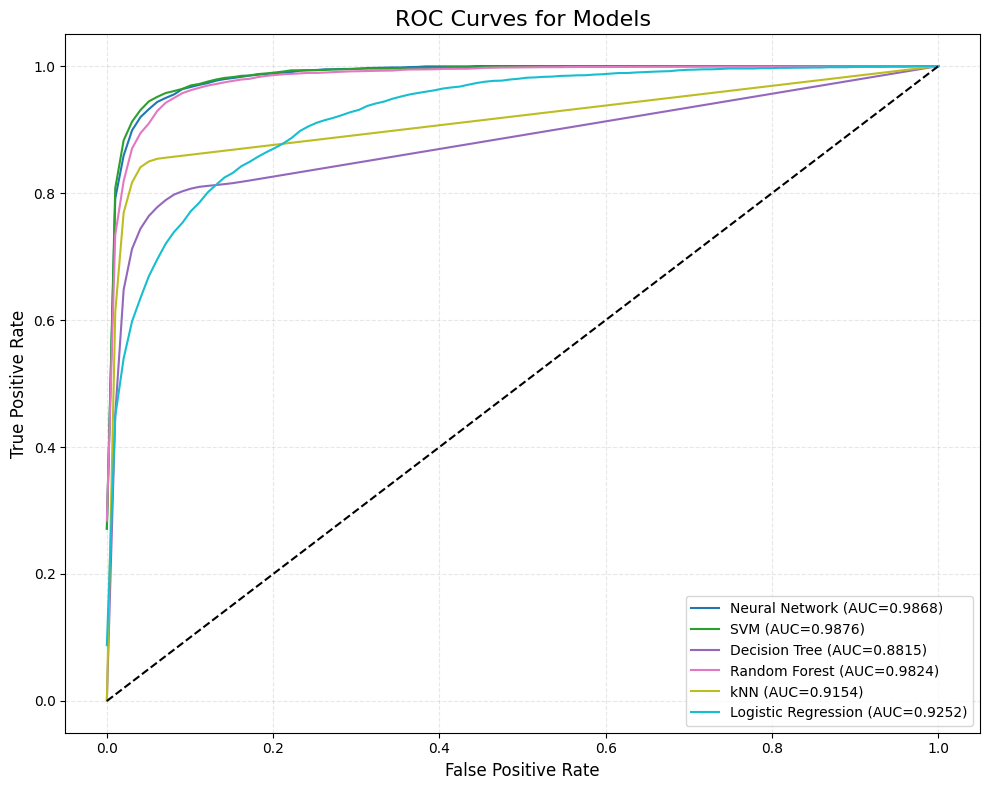

DeLong's Test (Neural Network vs. SVM): Z=-0.3079, P-value=0.7582
DeLong's Test (Neural Network vs. Decision Tree): Z=18.7569, P-value=0.0000
DeLong's Test (Neural Network vs. Random Forest): Z=1.5352, P-value=0.1247
DeLong's Test (Neural Network vs. kNN): Z=14.4501, P-value=0.0000
DeLong's Test (SVM vs. Decision Tree): Z=18.9648, P-value=0.0000
DeLong's Test (SVM vs. Random Forest): Z=1.8403, P-value=0.0657
DeLong's Test (SVM vs. kNN): Z=14.6775, P-value=0.0000
DeLong's Test (Decision Tree vs. Random Forest): Z=-17.6502, P-value=0.0000
DeLong's Test (Decision Tree vs. kNN): Z=-4.8461, P-value=0.0000
DeLong's Test (Random Forest vs. kNN): Z=13.2478, P-value=0.0000


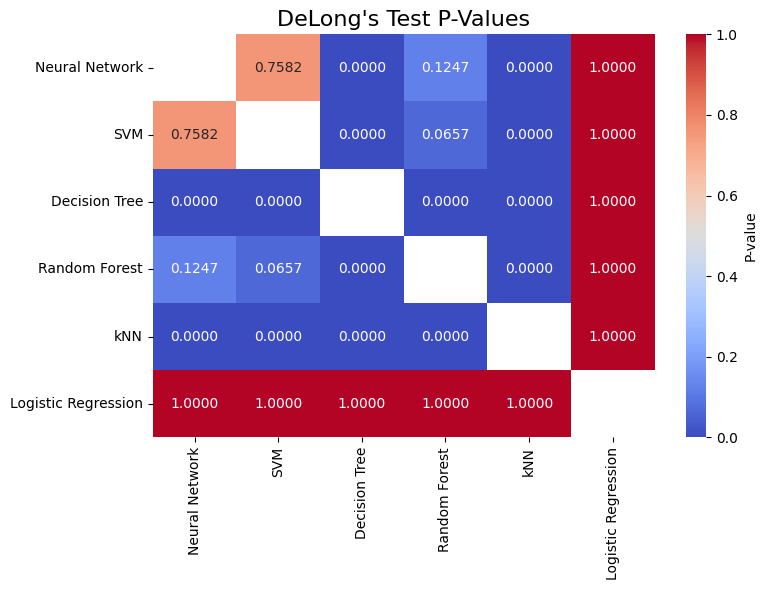

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import scipy.stats as stats


def delong_roc_test(
    y_true, y_scores1, y_scores2, model1_name, model2_name, num_classes=10
):
    def compute_roc_variance(y_true, y_scores, num_classes):
        aucs = []
        variances = []
        n = len(y_true)
        for i in range(num_classes):
            y_true_bin = (y_true == i).astype(int)  # OvR for class i
            auc = roc_auc_score(y_true_bin, y_scores[:, i])
            aucs.append(auc)
            # Compute Mann-Whitney U-like statistic (V)
            V = 0
            n_pos = np.sum(y_true_bin)
            n_neg = n - n_pos
            if n_pos == 0 or n_neg == 0:
                variances.append(0)
                continue
            for j in range(n):
                if y_true_bin[j] == 1:  # Positive class
                    for k in range(n):
                        if y_true_bin[k] == 0:  # Negative class
                            if y_scores[j, i] > y_scores[k, i]:
                                V += 1
                            elif y_scores[j, i] == y_scores[k, i]:
                                V += 0.5
            V = V / (n_pos * n_neg) if n_pos * n_neg > 0 else 0.5
            V = np.clip(V, 1e-10, 1 - 1e-10)  # Prevent V=0 or V=1
            variances.append(V * (1 - V) / n)
        auc_mean = np.mean(aucs)
        variance_mean = (
            np.mean([v for v in variances if v > 0])
            if any(v > 0 for v in variances)
            else 1e-10
        )
        return auc_mean, variance_mean

    auc1, V1 = compute_roc_variance(y_true, y_scores1, num_classes)
    auc2, V2 = compute_roc_variance(y_true, y_scores2, num_classes)
    diff = auc1 - auc2
    se_diff = np.sqrt(V1 + V2)
    if np.isnan(se_diff) or se_diff == 0:
        se_diff = 1e-10  # Avoid division by zero
    z = diff / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    print(
        f"DeLong's Test ({model1_name} vs. {model2_name}): Z={z:.4f}, P-value={p_value:.4f}"
    )
    return z, p_value


def plot_roc_curves(
    y_true, y_scores_dict, num_classes=10, title="ROC Curves for Models"
):
    colors = plt.cm.tab10(np.linspace(0, 1, 6))  # 6 colors for 6 models
    plt.figure(figsize=(10, 8), dpi=100)

    for idx, (model_name, y_scores) in enumerate(y_scores_dict.items()):
        # Compute OvR AUC
        auc = roc_auc_score(y_true, y_scores, multi_class="ovr")

        # Compute macro-average ROC curve
        fpr_grid = np.linspace(0, 1, 100)  # Common FPR grid
        tpr_mean = np.zeros_like(fpr_grid)
        for i in range(num_classes):
            y_true_bin = (y_true == i).astype(int)  # Binary OvR for class i
            fpr, tpr, _ = roc_curve(y_true_bin, y_scores[:, i])
            tpr_interp = np.interp(fpr_grid, fpr, tpr)  # Interpolate TPR
            tpr_mean += tpr_interp / num_classes  # Average TPR
        plt.plot(
            fpr_grid, tpr_mean, c=colors[idx], label=f"{model_name} (AUC={auc:.4f})"
        )
        print(f"{model_name} AUC: {auc:.4f}")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=16)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_delong_pvalue_heatmap(p_values, model_names, title="DeLong's Test P-Values"):
    # Create a 6x6 matrix for p-values
    p_matrix = np.ones((len(model_names), len(model_names)))  # Initialize with 1.0
    for (model1, model2), p_val in p_values.items():
        i = model_names.index(model1)
        j = model_names.index(model2)
        p_matrix[i, j] = p_val
        p_matrix[j, i] = p_val  # Symmetric matrix

    # Mask diagonal (self-comparisons)
    np.fill_diagonal(p_matrix, np.nan)

    # Plot heatmap
    plt.figure(figsize=(8, 6), dpi=100)
    sns.heatmap(
        p_matrix,
        annot=True,
        fmt=".4f",
        cmap="coolwarm",
        xticklabels=model_names,
        yticklabels=model_names,
        cbar_kws={"label": "P-value"},
        vmin=0,
        vmax=1,
    )
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig("delong_pvalue_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()


# Assuming y_scores_dict is defined from Blocks 8–13
y_scores_dict = {
    "Neural Network": y_scores_nn,
    "SVM": y_scores_svm,
    "Decision Tree": y_scores_dt,
    "Random Forest": y_scores_rf,
    "kNN": y_scores_knn,
    "Logistic Regression": y_scores_lr,
}

# Plot ROC curves and compute AUCs
plot_roc_curves(y_test, y_scores_dict, num_classes=10)

# DeLong's Test for model pairs
model_names = list(y_scores_dict.keys())
model_pairs = [
    ("Neural Network", y_scores_nn, "SVM", y_scores_svm),
    ("Neural Network", y_scores_nn, "Decision Tree", y_scores_dt),
    ("Neural Network", y_scores_nn, "Random Forest", y_scores_rf),
    ("Neural Network", y_scores_nn, "kNN", y_scores_knn),
    ("SVM", y_scores_svm, "Decision Tree", y_scores_dt),
    ("SVM", y_scores_svm, "Random Forest", y_scores_rf),
    ("SVM", y_scores_svm, "kNN", y_scores_knn),
    ("Decision Tree", y_scores_dt, "Random Forest", y_scores_rf),
    ("Decision Tree", y_scores_dt, "kNN", y_scores_knn),
    ("Random Forest", y_scores_rf, "kNN", y_scores_knn),
]

p_values = {}
for model1_name, y_scores1, model2_name, y_scores2 in model_pairs:
    z, p_value = delong_roc_test(
        y_test, y_scores1, y_scores2, model1_name, model2_name, num_classes=10
    )
    p_values[(model1_name, model2_name)] = p_value

# Plot p-value heatmap
plot_delong_pvalue_heatmap(p_values, model_names)

## 18. Model Summaries

In [20]:
def print_model_summary(
    model_name, metrics, cv_accuracies, importance, orig_importance, bic, params, le
):
    original_features = [
        "RGB_mean_R",
        "RGB_mean_G",
        "RGB_mean_B",
        "RGB_var_R",
        "RGB_var_G",
        "RGB_var_B",
        "HSV_mean_H",
        "HSV_mean_S",
        "HSV_mean_V",
        "HSV_var_H",
        "HSV_var_S",
        "HSV_var_V",
        "GLCM_contrast",
        "GLCM_correlation",
        "GLCM_entropy",
        "Edge_density",
    ]
    print(f"\n=== {model_name} Summary ===")
    print(f"Hyperparameters: {params}")
    print(
        f"Metrics: Accuracy={metrics[0]:.4f}, Precision={metrics[1]:.4f}, Recall={metrics[2]:.4f}, F1={metrics[3]:.4f}"
    )
    print(f"95% CI: [{metrics[4]:.4f}, {metrics[5]:.4f}]")

    # Compute AUC safely
    try:
        auc_scores = []
        for i in range(num_classes):
            if np.sum(y_test == i) > 0:  # Skip classes with no samples
                score = roc_auc_score(
                    (y_test == i).astype(int), y_scores_dict[model_name][:, i]
                )
                if not np.isnan(score) and not np.isinf(score):
                    auc_scores.append(score)
                else:
                    print(
                        f"Warning: Invalid AUC for {model_name} class {le.classes_[i]}"
                    )
            else:
                print(f"Warning: Class {le.classes_[i]} has no samples in y_test")
        avg_auc = np.mean(auc_scores) if auc_scores else np.nan
        print(
            f"Average AUC: {avg_auc:.4f}"
            if not np.isnan(avg_auc)
            else "Average AUC: Not computed"
        )
    except (KeyError, ValueError) as e:
        print(f"Average AUC: Not computed (Error: {e})")

    # Compute CV Stability safely
    if len(cv_accuracies) > 0:
        cv_mean = np.mean(cv_accuracies)
        cv_std = np.std(cv_accuracies)
        cv_coef = cv_std / cv_mean if cv_mean > 0 else np.nan
        print(
            f"CV Stability: Mean={cv_mean:.4f}, CV={cv_coef:.4f}"
            if not np.isnan(cv_coef)
            else "CV Stability: Not computed (invalid mean)"
        )
    else:
        print("CV Stability: Not computed (no CV accuracies provided)")

    print(f"BIC: {bic:.4f}")
    print("PCA Feature Importance:", importance)
    print(
        "Original Feature Importance:",
        {f: i for f, i in zip(original_features, orig_importance)},
    )

    print("\nInterpretation:")
    if model_name == "Decision Tree":
        print(
            "- Splits on PCA components (PC1, PC2, ...). Check decision_tree_top3.pdf."
        )
        print(
            "- Map splits to original features using PCA loadings (e.g., PC1 may be driven by RGB mean, HSV variance)."
        )
        print(
            "- High original feature importance (e.g., GLCM_entropy) indicates key features for disease classification."
        )
    elif model_name == "SVM":
        print("- Decision boundaries in PCA space (see svm_boundaries.png).")
        print(
            "- For linear kernel, high |coef_| for a PC indicates importance. For RBF, use permutation importance."
        )
        print(
            "- Original feature importance shows which features (e.g., HSV variance) drive separation."
        )
    elif model_name == "Random Forest":
        print(
            "- Feature importance for PCA components. High values indicate predictive PCs."
        )
        print(
            "- Original feature contributions (e.g., RGB mean, GLCM entropy) show key image properties."
        )
    elif model_name == "kNN":
        print(
            "- Distances in PCA space determine predictions (see knn_boundaries.png)."
        )
        print("- Permutation importance shows which PCs affect accuracy most.")
    elif model_name == "Neural Network":
        print(
            "- Permutation importance for PCA components. Map to original features for interpretability."
        )
        print("- High importance for PCs indicates key features for classification.")
    elif model_name == "Logistic Regression":
        print(
            "- Coefficients for PCA components. Map to original features via PCA loadings."
        )
        print("- High |coef_| indicates influential PCs for disease prediction.")
        print(
            f"- Iterations used: {lr.n_iter_[0] if model_name == 'Logistic Regression' else 'N/A'}"
        )
        if model_name == "Logistic Regression" and lr.n_iter_[0] >= 1000:
            print(
                "  Warning: Logistic Regression may not have converged. Consider increasing max_iter."
            )


# Verify Logistic Regression setup
print("Logistic Regression Setup Check:")
print(f"Iterations: {lr.n_iter_[0]}")
print(f"y_scores_lr shape: {y_scores_lr.shape}")
print(f"y_test class counts: {np.bincount(y_test)}")
print(
    f"NaN in y_scores_lr: {np.isnan(y_scores_lr).any()}, Inf in y_scores_lr: {np.isinf(y_scores_lr).any()}"
)

# Call for each model
print_model_summary(
    "Neural Network",
    nn_metrics,
    nn_cv,
    nn_importance,
    nn_orig_importance,
    nn_bic,
    {"lr": 0.001, "epochs": 50},
    le,
)
print_model_summary(
    "SVM",
    svm_metrics,
    svm_cv,
    svm_importance,
    svm_orig_importance,
    svm_bic,
    best_svm.get_params(),
    le,
)
print_model_summary(
    "Decision Tree",
    dt_metrics,
    dt_cv,
    dt_importance,
    dt_orig_importance,
    dt_bic,
    best_dt.get_params(),
    le,
)
print_model_summary(
    "Random Forest",
    rf_metrics,
    rf_cv,
    rf_importance,
    rf_orig_importance,
    rf_bic,
    best_rf.get_params(),
    le,
)
print_model_summary(
    "kNN",
    knn_metrics,
    knn_cv,
    knn_importance,
    knn_orig_importance,
    knn_bic,
    best_knn.get_params(),
    le,
)
print_model_summary(
    "Logistic Regression",
    lr_metrics,
    [],
    lr_importance,
    lr_orig_importance,
    lr_bic,
    lr.get_params(),
    le,
)

Logistic Regression Setup Check:
Iterations: 78
y_scores_lr shape: (3632, 10)
y_test class counts: [ 425  200  382  191  354  335  281 1071   75  318]
NaN in y_scores_lr: False, Inf in y_scores_lr: False

=== Neural Network Summary ===
Hyperparameters: {'lr': 0.001, 'epochs': 50}
Metrics: Accuracy=0.8477, Precision=0.8204, Recall=0.8540, F1=0.8345
95% CI: [0.8368, 0.8584]
Average AUC: 0.9868
CV Stability: Mean=0.8342, CV=0.0053
BIC: 82868.2455
PCA Feature Importance: [0.34055595 0.25767558 0.27023552 0.21995151 0.20295196 0.25241831
 0.22115311]
Original Feature Importance: {'RGB_mean_R': np.float64(0.278779702875197), 'RGB_mean_G': np.float64(0.19227609223370037), 'RGB_mean_B': np.float64(0.18442591299482086), 'RGB_var_R': np.float64(0.19366167335422546), 'RGB_var_G': np.float64(0.06757886646576611), 'RGB_var_B': np.float64(0.09670484476368427), 'HSV_mean_H': np.float64(0.2404646682715845), 'HSV_mean_S': np.float64(0.1456178590714867), 'HSV_mean_V': np.float64(0.2757964270391257), 'HS

In [21]:
# ## Block 22: Ensemble Model
# from sklearn.metrics import accuracy_score

# predictions = {
#     "NN": y_pred_nn,
#     "SVM": y_pred_svm,
#     "Decision Tree": y_pred_dt,
#     "Random Forest": y_pred_rf,
#     "kNN": y_pred_knn,
#     "Logistic Regression": y_pred_lr,
# }
# ensemble_pred = np.apply_along_axis(
#     lambda x: np.bincount(x).argmax(), axis=0, arr=np.vstack(list(predictions.values()))
# )
# print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
# np.save("ensemble_pred.npy", ensemble_pred)

## 19 C.M.

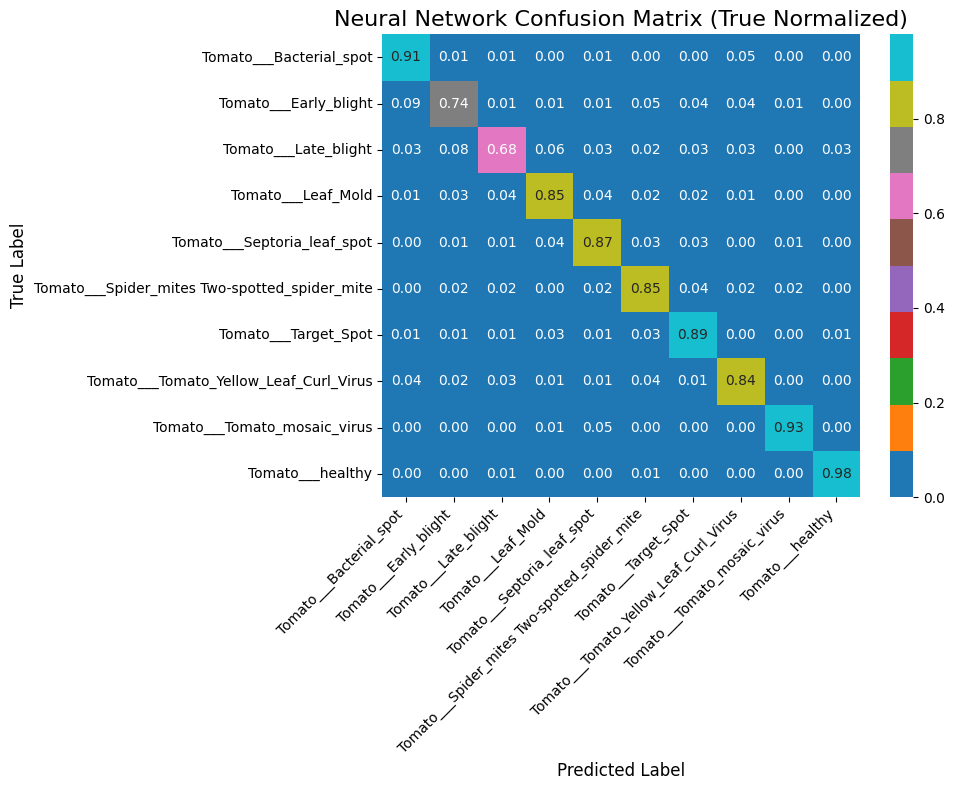


Neural Network Confusion Matrix (True Normalized):
[[0.91294118 0.00941176 0.01176471 0.         0.00705882 0.
  0.00470588 0.05411765 0.         0.        ]
 [0.085      0.745      0.01       0.01       0.015      0.05
  0.035      0.04       0.01       0.        ]
 [0.03141361 0.08376963 0.68324607 0.05759162 0.02879581 0.02094241
  0.03403141 0.03141361 0.         0.02879581]
 [0.0052356  0.02617801 0.03664921 0.84816754 0.03664921 0.02094241
  0.02094241 0.0052356  0.         0.        ]
 [0.         0.01129944 0.00847458 0.03954802 0.86723164 0.03107345
  0.03389831 0.         0.00847458 0.        ]
 [0.         0.02089552 0.0238806  0.00298507 0.02089552 0.84776119
  0.04477612 0.02089552 0.01791045 0.        ]
 [0.00711744 0.01423488 0.00711744 0.03202847 0.01067616 0.02846975
  0.886121   0.         0.00355872 0.01067616]
 [0.03828198 0.02427638 0.02614379 0.01493931 0.00840336 0.0410831
  0.00840336 0.83846872 0.         0.        ]
 [0.         0.         0.         0.013333

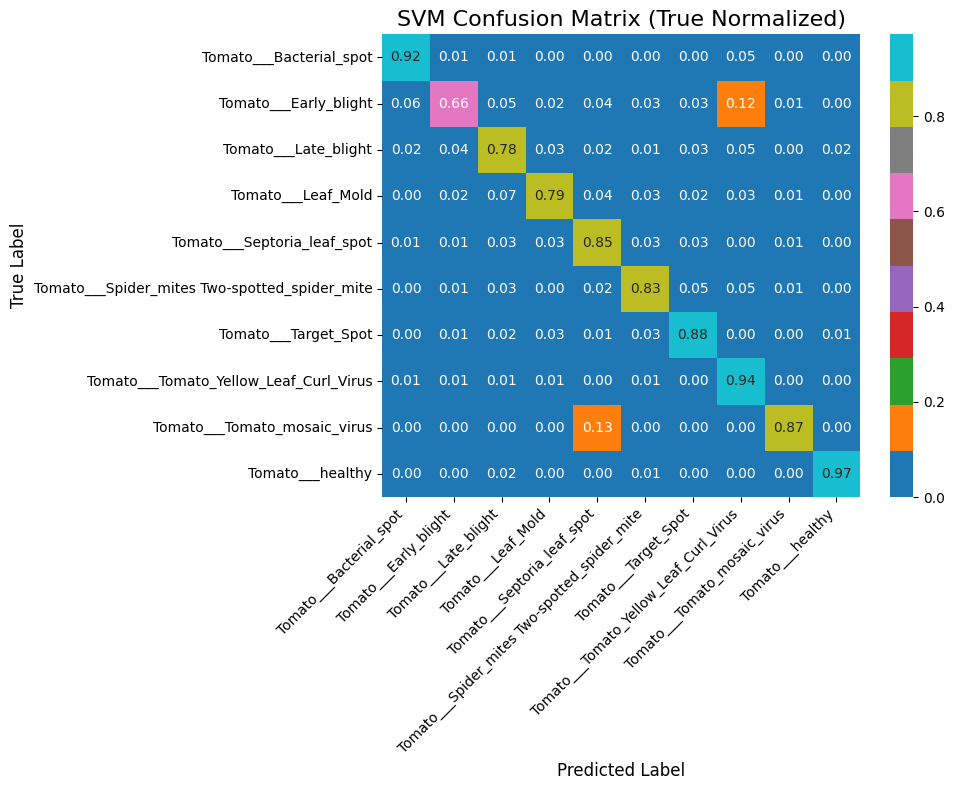


SVM Confusion Matrix (True Normalized):
[[0.91764706 0.01176471 0.01176471 0.         0.00470588 0.
  0.00235294 0.05176471 0.         0.        ]
 [0.055      0.66       0.05       0.02       0.035      0.025
  0.03       0.115      0.01       0.        ]
 [0.01570681 0.04188482 0.78010471 0.02617801 0.02356021 0.01308901
  0.03141361 0.05235602 0.         0.01570681]
 [0.         0.02094241 0.06806283 0.78534031 0.04188482 0.02617801
  0.02094241 0.02617801 0.0104712  0.        ]
 [0.00564972 0.01412429 0.03107345 0.02542373 0.85310734 0.03389831
  0.02824859 0.00282486 0.00564972 0.        ]
 [0.         0.00895522 0.02985075 0.         0.02089552 0.82985075
  0.05373134 0.05074627 0.00597015 0.        ]
 [0.00355872 0.00711744 0.02135231 0.02846975 0.01067616 0.03202847
  0.87900356 0.00355872 0.00355872 0.01067616]
 [0.01027077 0.00746965 0.01493931 0.00560224 0.00466853 0.01493931
  0.00466853 0.93744164 0.         0.        ]
 [0.         0.         0.         0.         0.1333

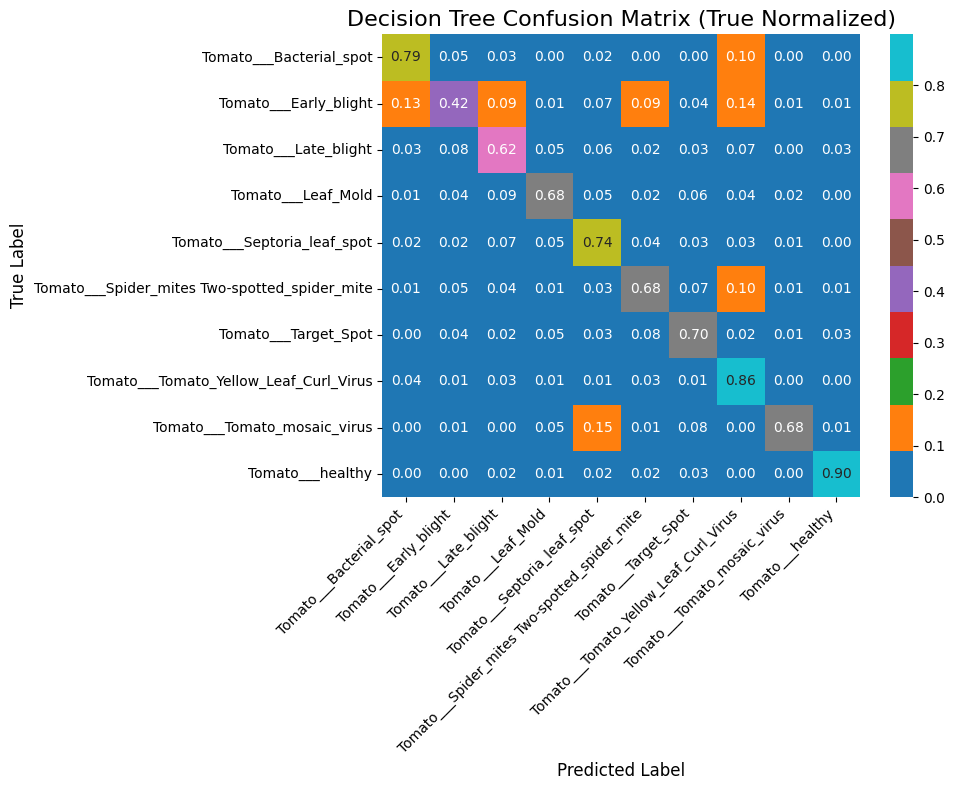


Decision Tree Confusion Matrix (True Normalized):
[[0.79058824 0.05176471 0.02823529 0.00235294 0.02117647 0.
  0.00470588 0.09882353 0.         0.00235294]
 [0.13       0.425      0.09       0.015      0.065      0.09
  0.04       0.135      0.005      0.005     ]
 [0.03141361 0.08115183 0.61780105 0.05497382 0.05759162 0.02356021
  0.03403141 0.06544503 0.0026178  0.03141361]
 [0.0052356  0.04188482 0.08900524 0.67539267 0.05235602 0.02094241
  0.05759162 0.04188482 0.01570681 0.        ]
 [0.01977401 0.01977401 0.06779661 0.05084746 0.73728814 0.03672316
  0.02824859 0.02824859 0.01129944 0.        ]
 [0.00597015 0.05373134 0.03880597 0.00597015 0.02985075 0.67761194
  0.07462687 0.09552239 0.00895522 0.00895522]
 [0.00355872 0.04270463 0.02491103 0.05338078 0.02846975 0.08185053
  0.70462633 0.02135231 0.01067616 0.02846975]
 [0.03921569 0.01120448 0.02894491 0.01120448 0.00933707 0.02987862
  0.00653595 0.8627451  0.00093371 0.        ]
 [0.         0.01333333 0.         0.053333

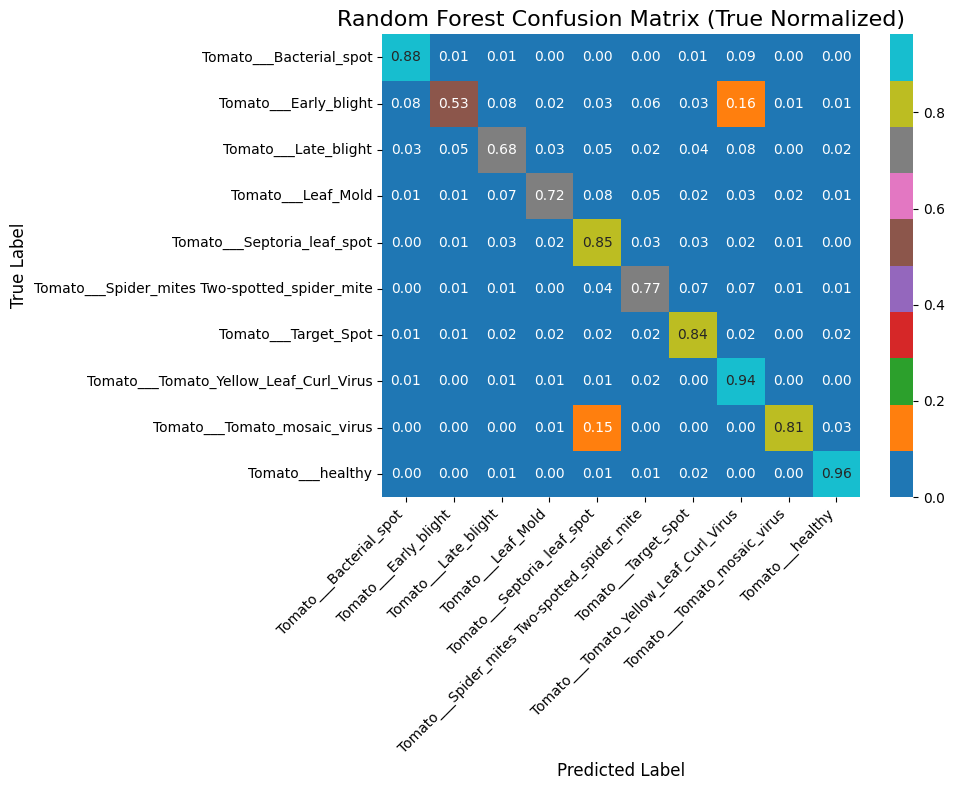


Random Forest Confusion Matrix (True Normalized):
[[0.87529412 0.01176471 0.00705882 0.         0.00470588 0.
  0.00941176 0.09176471 0.         0.        ]
 [0.08       0.53       0.08       0.02       0.03       0.06
  0.025      0.16       0.005      0.01      ]
 [0.02879581 0.04973822 0.68324607 0.03141361 0.04712042 0.02094241
  0.03664921 0.07853403 0.         0.02356021]
 [0.0052356  0.0052356  0.07329843 0.72251309 0.07853403 0.04712042
  0.02094241 0.02617801 0.01570681 0.0052356 ]
 [0.00282486 0.01412429 0.02824859 0.01694915 0.85028249 0.03107345
  0.02824859 0.01977401 0.00847458 0.        ]
 [0.00298507 0.0119403  0.01492537 0.         0.04179104 0.76716418
  0.06567164 0.07164179 0.01492537 0.00895522]
 [0.00711744 0.01423488 0.01779359 0.02491103 0.01779359 0.02491103
  0.84341637 0.02135231 0.00355872 0.02491103]
 [0.00933707 0.00373483 0.01120448 0.00560224 0.00746965 0.01774043
  0.00373483 0.94117647 0.         0.        ]
 [0.         0.         0.         0.013333

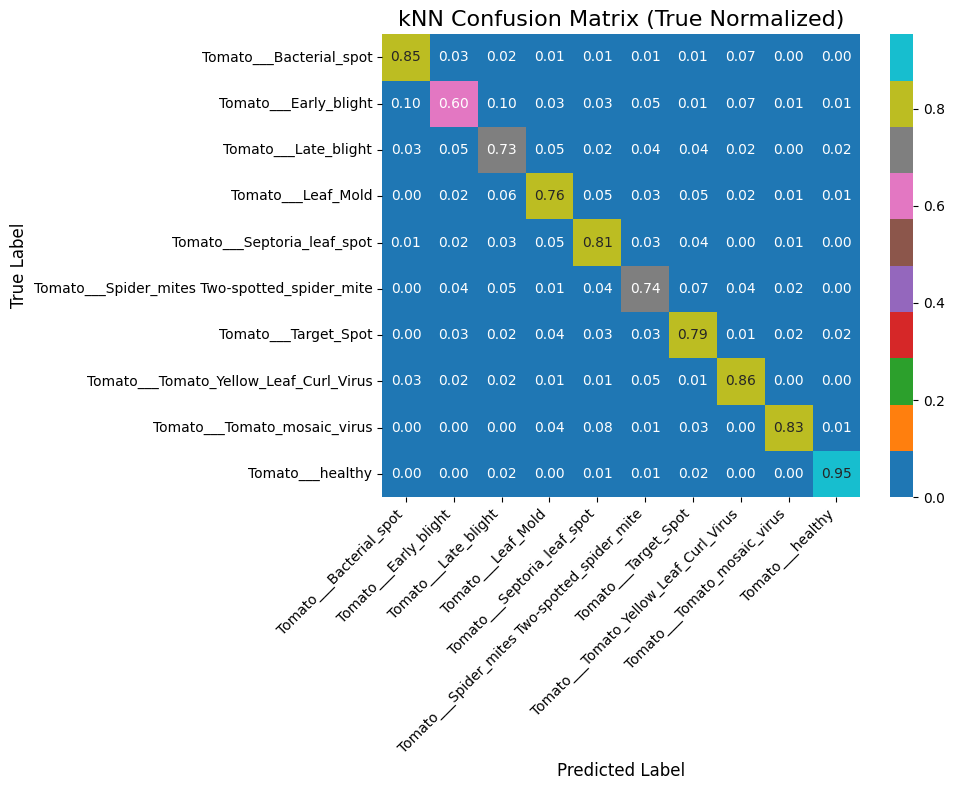


kNN Confusion Matrix (True Normalized):
[[0.85176471 0.02823529 0.01882353 0.00705882 0.00705882 0.00705882
  0.00705882 0.07058824 0.         0.00235294]
 [0.095      0.605      0.095      0.025      0.025      0.05
  0.015      0.075      0.01       0.005     ]
 [0.02879581 0.05497382 0.72774869 0.05235602 0.02094241 0.03926702
  0.03664921 0.02094241 0.0026178  0.01570681]
 [0.         0.02094241 0.05759162 0.76439791 0.04712042 0.02617801
  0.04712042 0.02094241 0.0104712  0.0052356 ]
 [0.00564972 0.01977401 0.03389831 0.05084746 0.80508475 0.02542373
  0.04237288 0.         0.01412429 0.00282486]
 [0.         0.0358209  0.04776119 0.00597015 0.03880597 0.74029851
  0.07462687 0.03880597 0.01791045 0.        ]
 [0.00355872 0.02846975 0.02491103 0.03914591 0.03202847 0.03202847
  0.78647687 0.01067616 0.01779359 0.02491103]
 [0.03174603 0.02147526 0.01867414 0.01213819 0.00653595 0.04668534
  0.00746965 0.85527544 0.         0.        ]
 [0.         0.         0.         0.04      

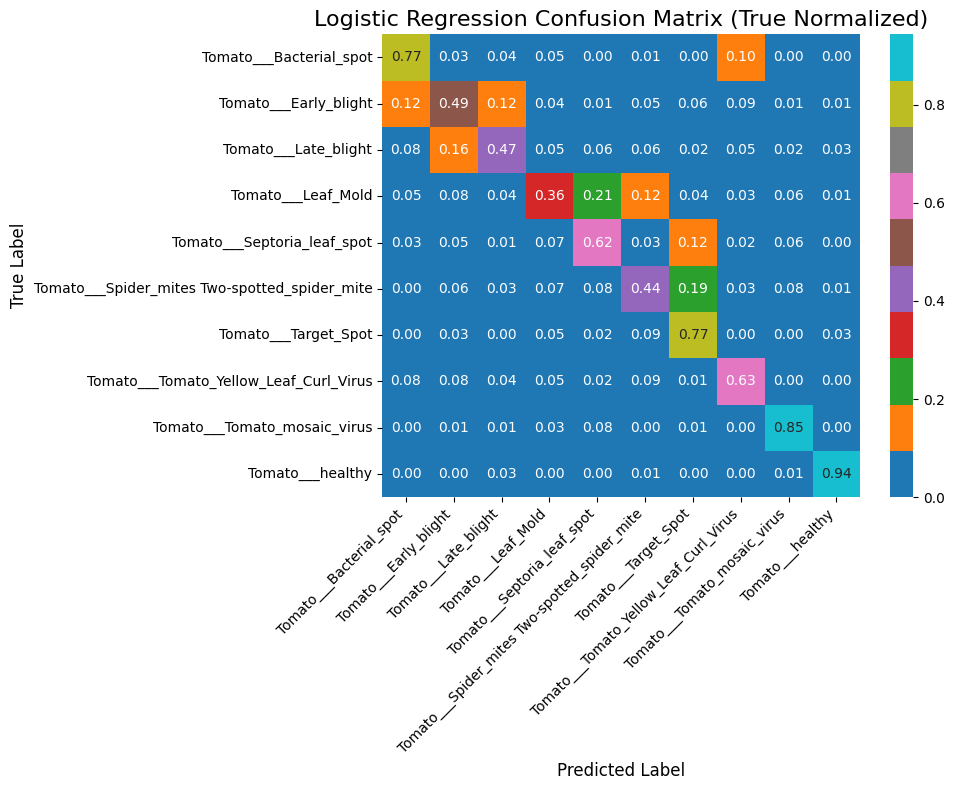


Logistic Regression Confusion Matrix (True Normalized):
[[7.67058824e-01 2.58823529e-02 4.00000000e-02 5.17647059e-02
  0.00000000e+00 7.05882353e-03 4.70588235e-03 1.03529412e-01
  0.00000000e+00 0.00000000e+00]
 [1.25000000e-01 4.90000000e-01 1.20000000e-01 4.00000000e-02
  1.50000000e-02 5.00000000e-02 6.00000000e-02 8.50000000e-02
  1.00000000e-02 5.00000000e-03]
 [7.59162304e-02 1.64921466e-01 4.71204188e-01 5.49738220e-02
  5.75916230e-02 6.02094241e-02 1.83246073e-02 4.71204188e-02
  1.83246073e-02 3.14136126e-02]
 [4.71204188e-02 7.85340314e-02 4.18848168e-02 3.61256545e-01
  2.14659686e-01 1.20418848e-01 4.18848168e-02 3.14136126e-02
  5.75916230e-02 5.23560209e-03]
 [2.82485876e-02 5.08474576e-02 5.64971751e-03 7.34463277e-02
  6.24293785e-01 2.54237288e-02 1.18644068e-01 1.69491525e-02
  5.64971751e-02 0.00000000e+00]
 [0.00000000e+00 6.26865672e-02 3.28358209e-02 6.56716418e-02
  8.35820896e-02 4.44776119e-01 1.91044776e-01 3.28358209e-02
  8.05970149e-02 5.97014925e-03]
 

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(
    y_true, y_pred, model_name, le, normalize="true", save_path=None
):
    # Compute confusion matrix
    cm = confusion_matrix(
        y_true, y_pred, labels=range(len(le.classes_)), normalize=normalize
    )

    # Create heatmap
    plt.figure(figsize=(10, 8), dpi=100)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="tab10",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(
        f"{model_name} Confusion Matrix ({normalize.capitalize()} Normalized)",
        fontsize=16,
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save plot
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Print matrix for reference
    print(f"\n{model_name} Confusion Matrix ({normalize.capitalize()} Normalized):")
    print(cm)


# Block 20: Plot confusion matrices for all models
model_predictions = {
    "Neural Network": y_pred_nn,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "kNN": y_pred_knn,
    "Logistic Regression": y_pred_lr,
}

for model_name, y_pred in model_predictions.items():
    plot_confusion_matrix(
        y_test,
        y_pred,
        model_name,
        le,
        normalize="true",
        save_path=f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png",
    )

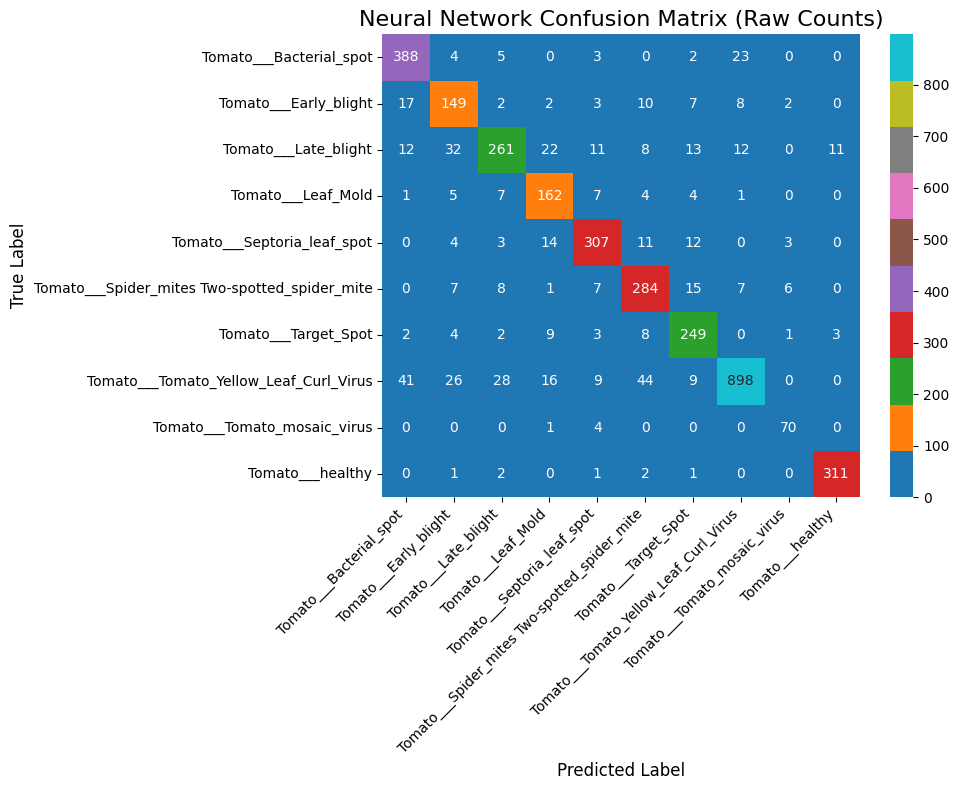


Neural Network Confusion Matrix (Raw Counts):
[[388   4   5   0   3   0   2  23   0   0]
 [ 17 149   2   2   3  10   7   8   2   0]
 [ 12  32 261  22  11   8  13  12   0  11]
 [  1   5   7 162   7   4   4   1   0   0]
 [  0   4   3  14 307  11  12   0   3   0]
 [  0   7   8   1   7 284  15   7   6   0]
 [  2   4   2   9   3   8 249   0   1   3]
 [ 41  26  28  16   9  44   9 898   0   0]
 [  0   0   0   1   4   0   0   0  70   0]
 [  0   1   2   0   1   2   1   0   0 311]]


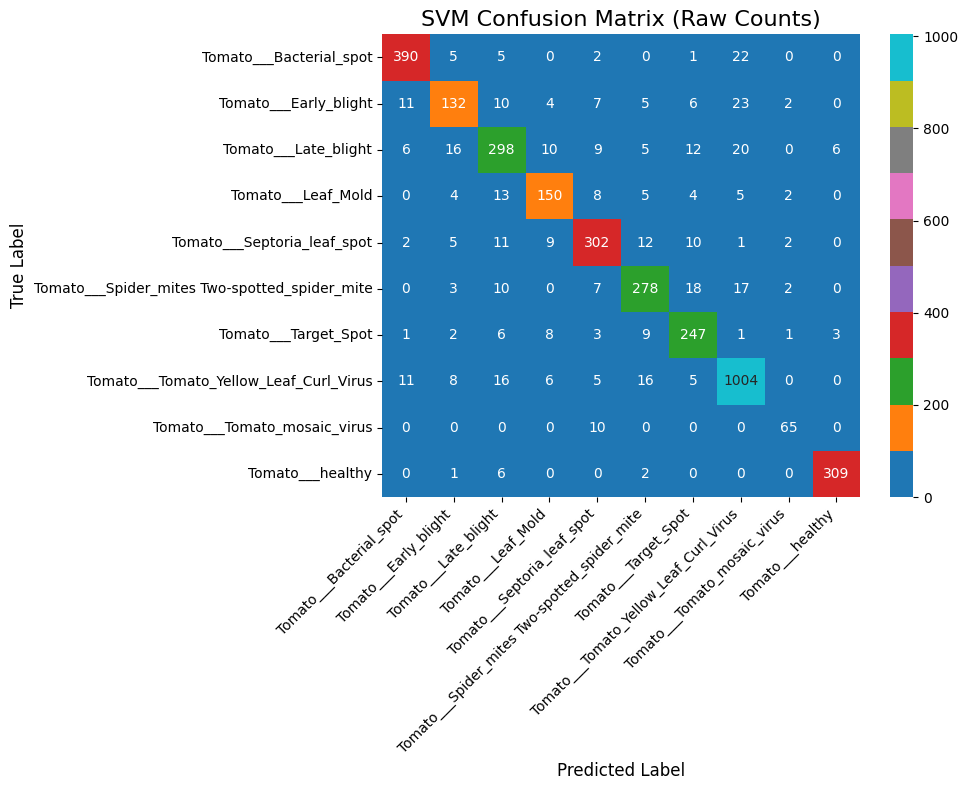


SVM Confusion Matrix (Raw Counts):
[[ 390    5    5    0    2    0    1   22    0    0]
 [  11  132   10    4    7    5    6   23    2    0]
 [   6   16  298   10    9    5   12   20    0    6]
 [   0    4   13  150    8    5    4    5    2    0]
 [   2    5   11    9  302   12   10    1    2    0]
 [   0    3   10    0    7  278   18   17    2    0]
 [   1    2    6    8    3    9  247    1    1    3]
 [  11    8   16    6    5   16    5 1004    0    0]
 [   0    0    0    0   10    0    0    0   65    0]
 [   0    1    6    0    0    2    0    0    0  309]]


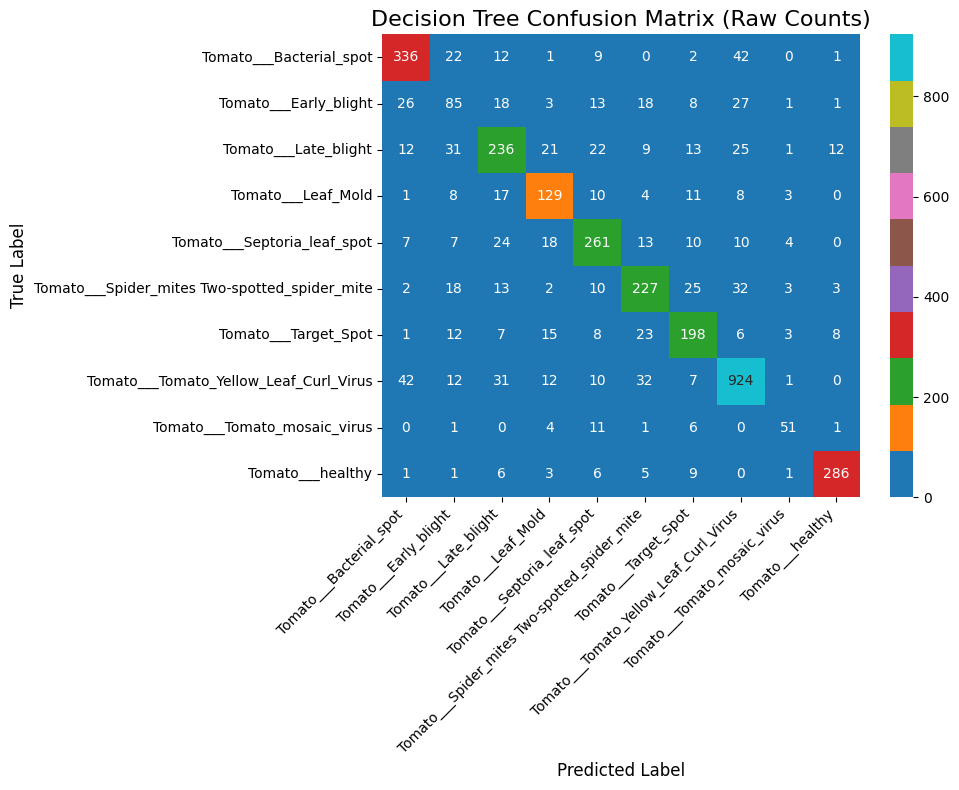


Decision Tree Confusion Matrix (Raw Counts):
[[336  22  12   1   9   0   2  42   0   1]
 [ 26  85  18   3  13  18   8  27   1   1]
 [ 12  31 236  21  22   9  13  25   1  12]
 [  1   8  17 129  10   4  11   8   3   0]
 [  7   7  24  18 261  13  10  10   4   0]
 [  2  18  13   2  10 227  25  32   3   3]
 [  1  12   7  15   8  23 198   6   3   8]
 [ 42  12  31  12  10  32   7 924   1   0]
 [  0   1   0   4  11   1   6   0  51   1]
 [  1   1   6   3   6   5   9   0   1 286]]


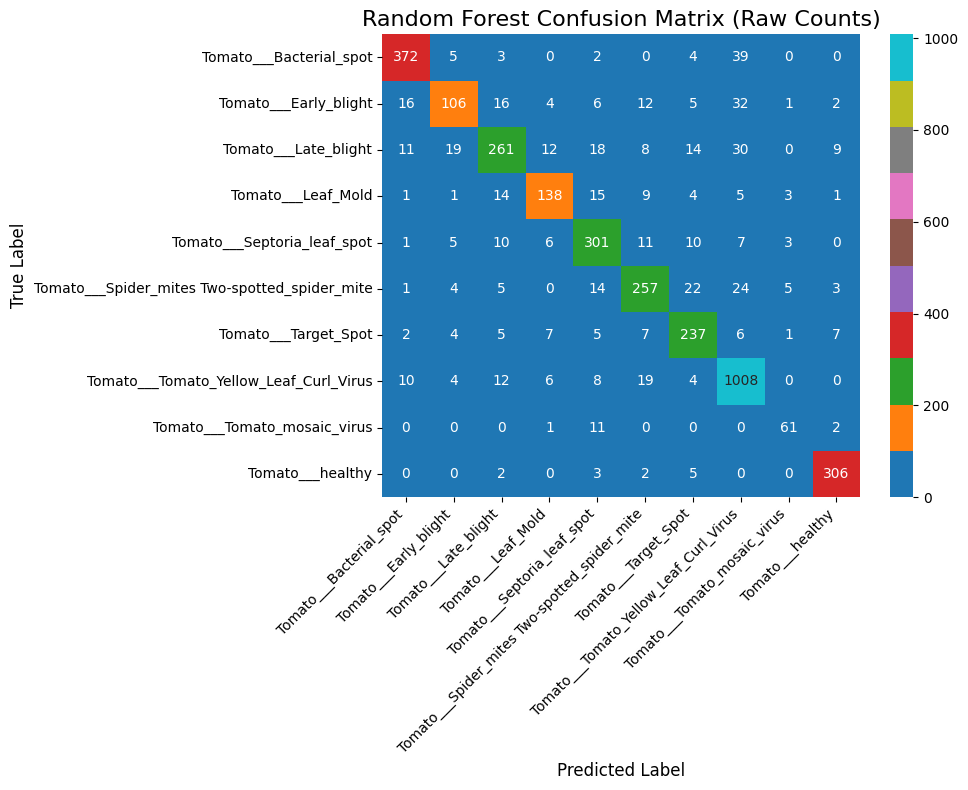


Random Forest Confusion Matrix (Raw Counts):
[[ 372    5    3    0    2    0    4   39    0    0]
 [  16  106   16    4    6   12    5   32    1    2]
 [  11   19  261   12   18    8   14   30    0    9]
 [   1    1   14  138   15    9    4    5    3    1]
 [   1    5   10    6  301   11   10    7    3    0]
 [   1    4    5    0   14  257   22   24    5    3]
 [   2    4    5    7    5    7  237    6    1    7]
 [  10    4   12    6    8   19    4 1008    0    0]
 [   0    0    0    1   11    0    0    0   61    2]
 [   0    0    2    0    3    2    5    0    0  306]]


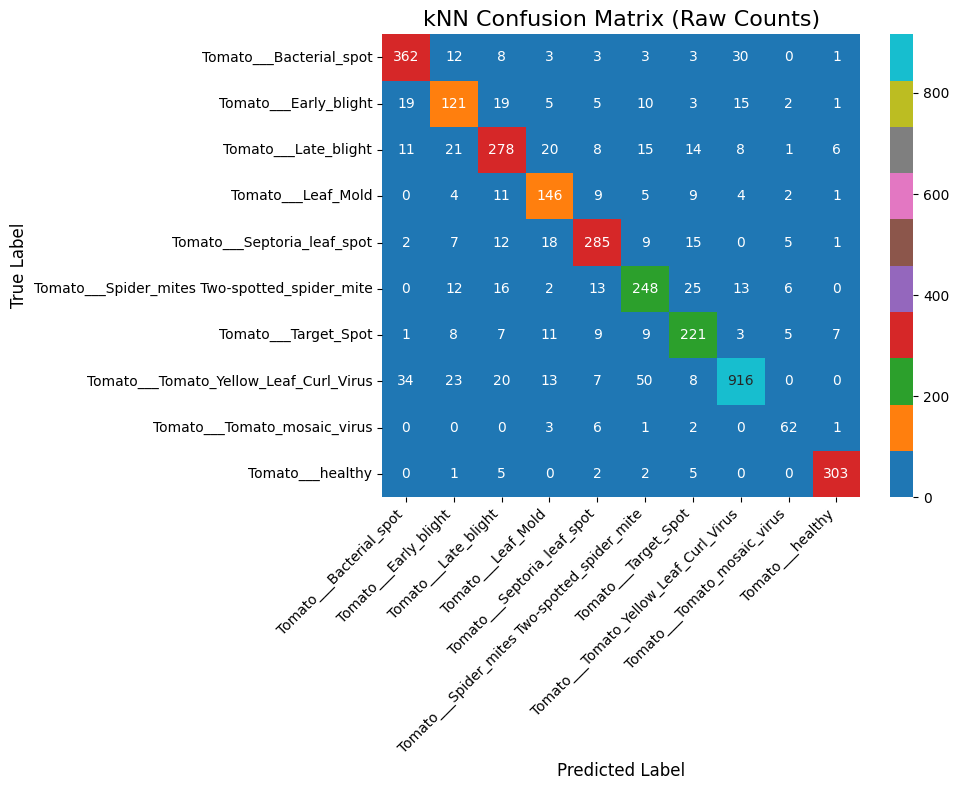


kNN Confusion Matrix (Raw Counts):
[[362  12   8   3   3   3   3  30   0   1]
 [ 19 121  19   5   5  10   3  15   2   1]
 [ 11  21 278  20   8  15  14   8   1   6]
 [  0   4  11 146   9   5   9   4   2   1]
 [  2   7  12  18 285   9  15   0   5   1]
 [  0  12  16   2  13 248  25  13   6   0]
 [  1   8   7  11   9   9 221   3   5   7]
 [ 34  23  20  13   7  50   8 916   0   0]
 [  0   0   0   3   6   1   2   0  62   1]
 [  0   1   5   0   2   2   5   0   0 303]]


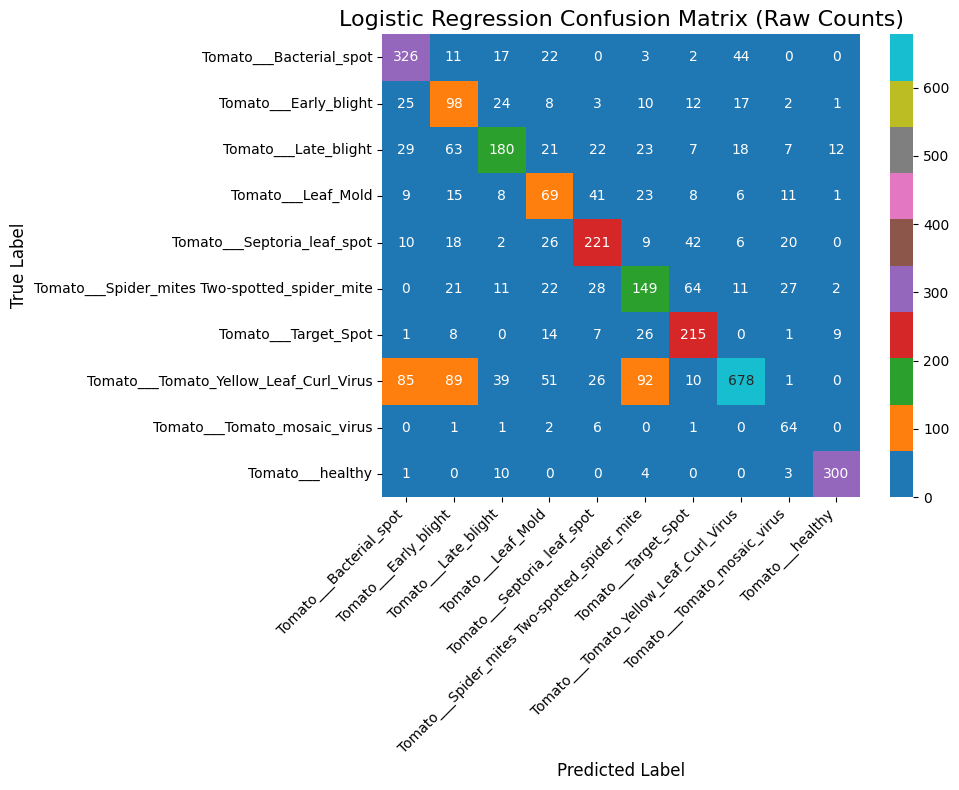


Logistic Regression Confusion Matrix (Raw Counts):
[[326  11  17  22   0   3   2  44   0   0]
 [ 25  98  24   8   3  10  12  17   2   1]
 [ 29  63 180  21  22  23   7  18   7  12]
 [  9  15   8  69  41  23   8   6  11   1]
 [ 10  18   2  26 221   9  42   6  20   0]
 [  0  21  11  22  28 149  64  11  27   2]
 [  1   8   0  14   7  26 215   0   1   9]
 [ 85  89  39  51  26  92  10 678   1   0]
 [  0   1   1   2   6   0   1   0  64   0]
 [  1   0  10   0   0   4   0   0   3 300]]


In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(
    y_true, y_pred, model_name, le, normalize=None, save_path=None
):
    """
    Compute and plot confusion matrix for a model with raw counts.

    Parameters:
    - y_true: True labels (e.g., y_test)
    - y_pred: Predicted labels (e.g., y_pred_nn)
    - model_name: Name of the model (e.g., "Neural Network")
    - le: LabelEncoder with class names
    - normalize: None for raw counts
    - save_path: Path to save the plot (e.g., "nn_confusion_matrix.png")
    """
    # Compute confusion matrix
    cm = confusion_matrix(
        y_true, y_pred, labels=range(len(le.classes_)), normalize=normalize
    )

    # Create heatmap
    plt.figure(figsize=(10, 8), dpi=100)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="tab10",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(f"{model_name} Confusion Matrix (Raw Counts)", fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save plot
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Print matrix for reference
    print(f"\n{model_name} Confusion Matrix (Raw Counts):")
    print(cm)


# Block 20: Plot confusion matrices for all models with raw counts
model_predictions = {
    "Neural Network": y_pred_nn,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "kNN": y_pred_knn,
    "Logistic Regression": y_pred_lr,
}

for model_name, y_pred in model_predictions.items():
    plot_confusion_matrix(
        y_test,
        y_pred,
        model_name,
        le,
        normalize=None,
        save_path=f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png",
    )

## Per class Feat. Imp.

Class distribution in y_test: [ 425  200  382  191  354  335  281 1071   75  318]
Neural Network Class Tomato___Bacterial_spot PCA Importance shape: (7,)
Neural Network Class Tomato___Bacterial_spot Original Importance shape: (16,)
Neural Network Class Tomato___Early_blight PCA Importance shape: (7,)
Neural Network Class Tomato___Early_blight Original Importance shape: (16,)
Neural Network Class Tomato___Late_blight PCA Importance shape: (7,)
Neural Network Class Tomato___Late_blight Original Importance shape: (16,)
Neural Network Class Tomato___Leaf_Mold PCA Importance shape: (7,)
Neural Network Class Tomato___Leaf_Mold Original Importance shape: (16,)
Neural Network Class Tomato___Septoria_leaf_spot PCA Importance shape: (7,)
Neural Network Class Tomato___Septoria_leaf_spot Original Importance shape: (16,)
Neural Network Class Tomato___Spider_mites Two-spotted_spider_mite PCA Importance shape: (7,)
Neural Network Class Tomato___Spider_mites Two-spotted_spider_mite Original Importance

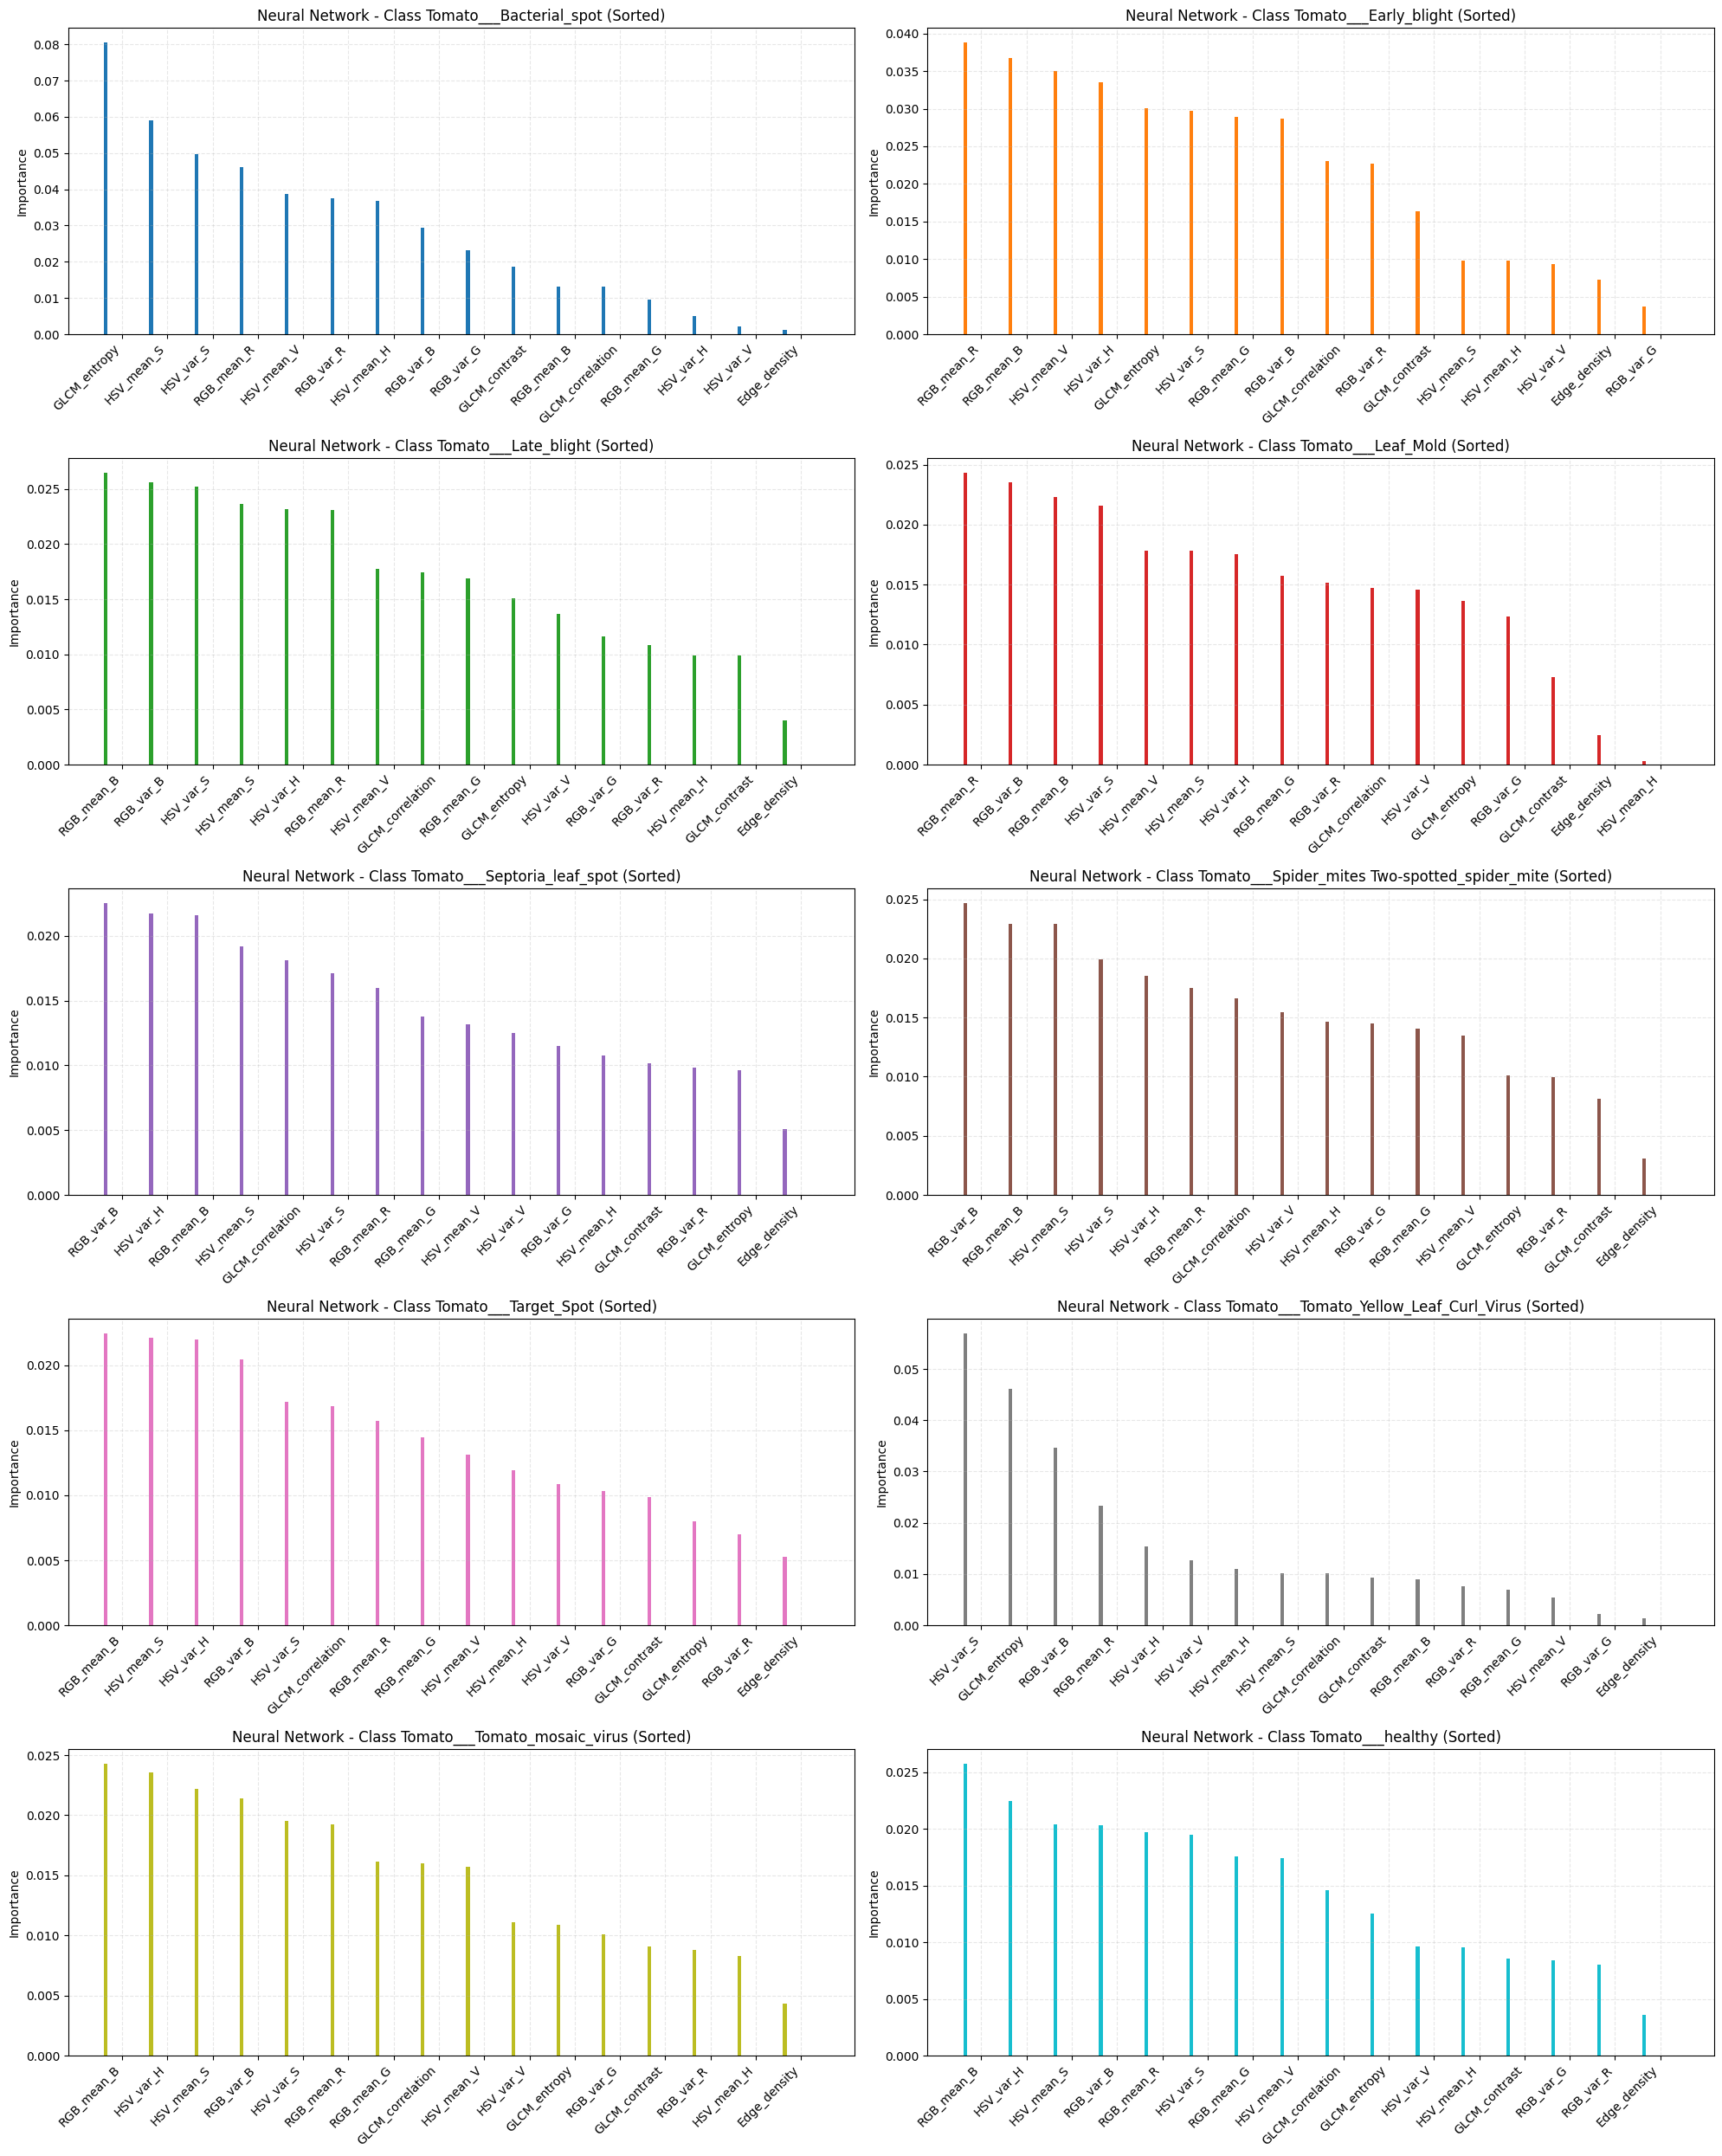


Neural Network Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'GLCM_entropy': np.float64(0.08048031598162889), 'HSV_mean_S': np.float64(0.058998428827069835), 'HSV_var_S': np.float64(0.049791616364715754), 'RGB_mean_R': np.float64(0.04609905185673993), 'HSV_mean_V': np.float64(0.03872187282164679), 'RGB_var_R': np.float64(0.0375456718209653), 'HSV_mean_H': np.float64(0.03670614311434066), 'RGB_var_B': np.float64(0.029362497621258078), 'RGB_var_G': np.float64(0.023241811754066092), 'GLCM_contrast': np.float64(0.01852118345836115), 'RGB_mean_B': np.float64(0.01316012110044135), 'GLCM_correlation': np.float64(0.013085660587689459), 'RGB_mean_G': np.float64(0.009522893396966835), 'HSV_var_H': np.float64(0.004921646074844738), 'HSV_var_V': np.float64(0.0020807744221557362), 'Edge_density': np.float64(0.0012307604194517728)}
Class Tomato___Early_blight: {'RGB_mean_R': np.float64(0.03880178103281398), 'RGB_mean_B': np.float64(0.03673207369285633), '

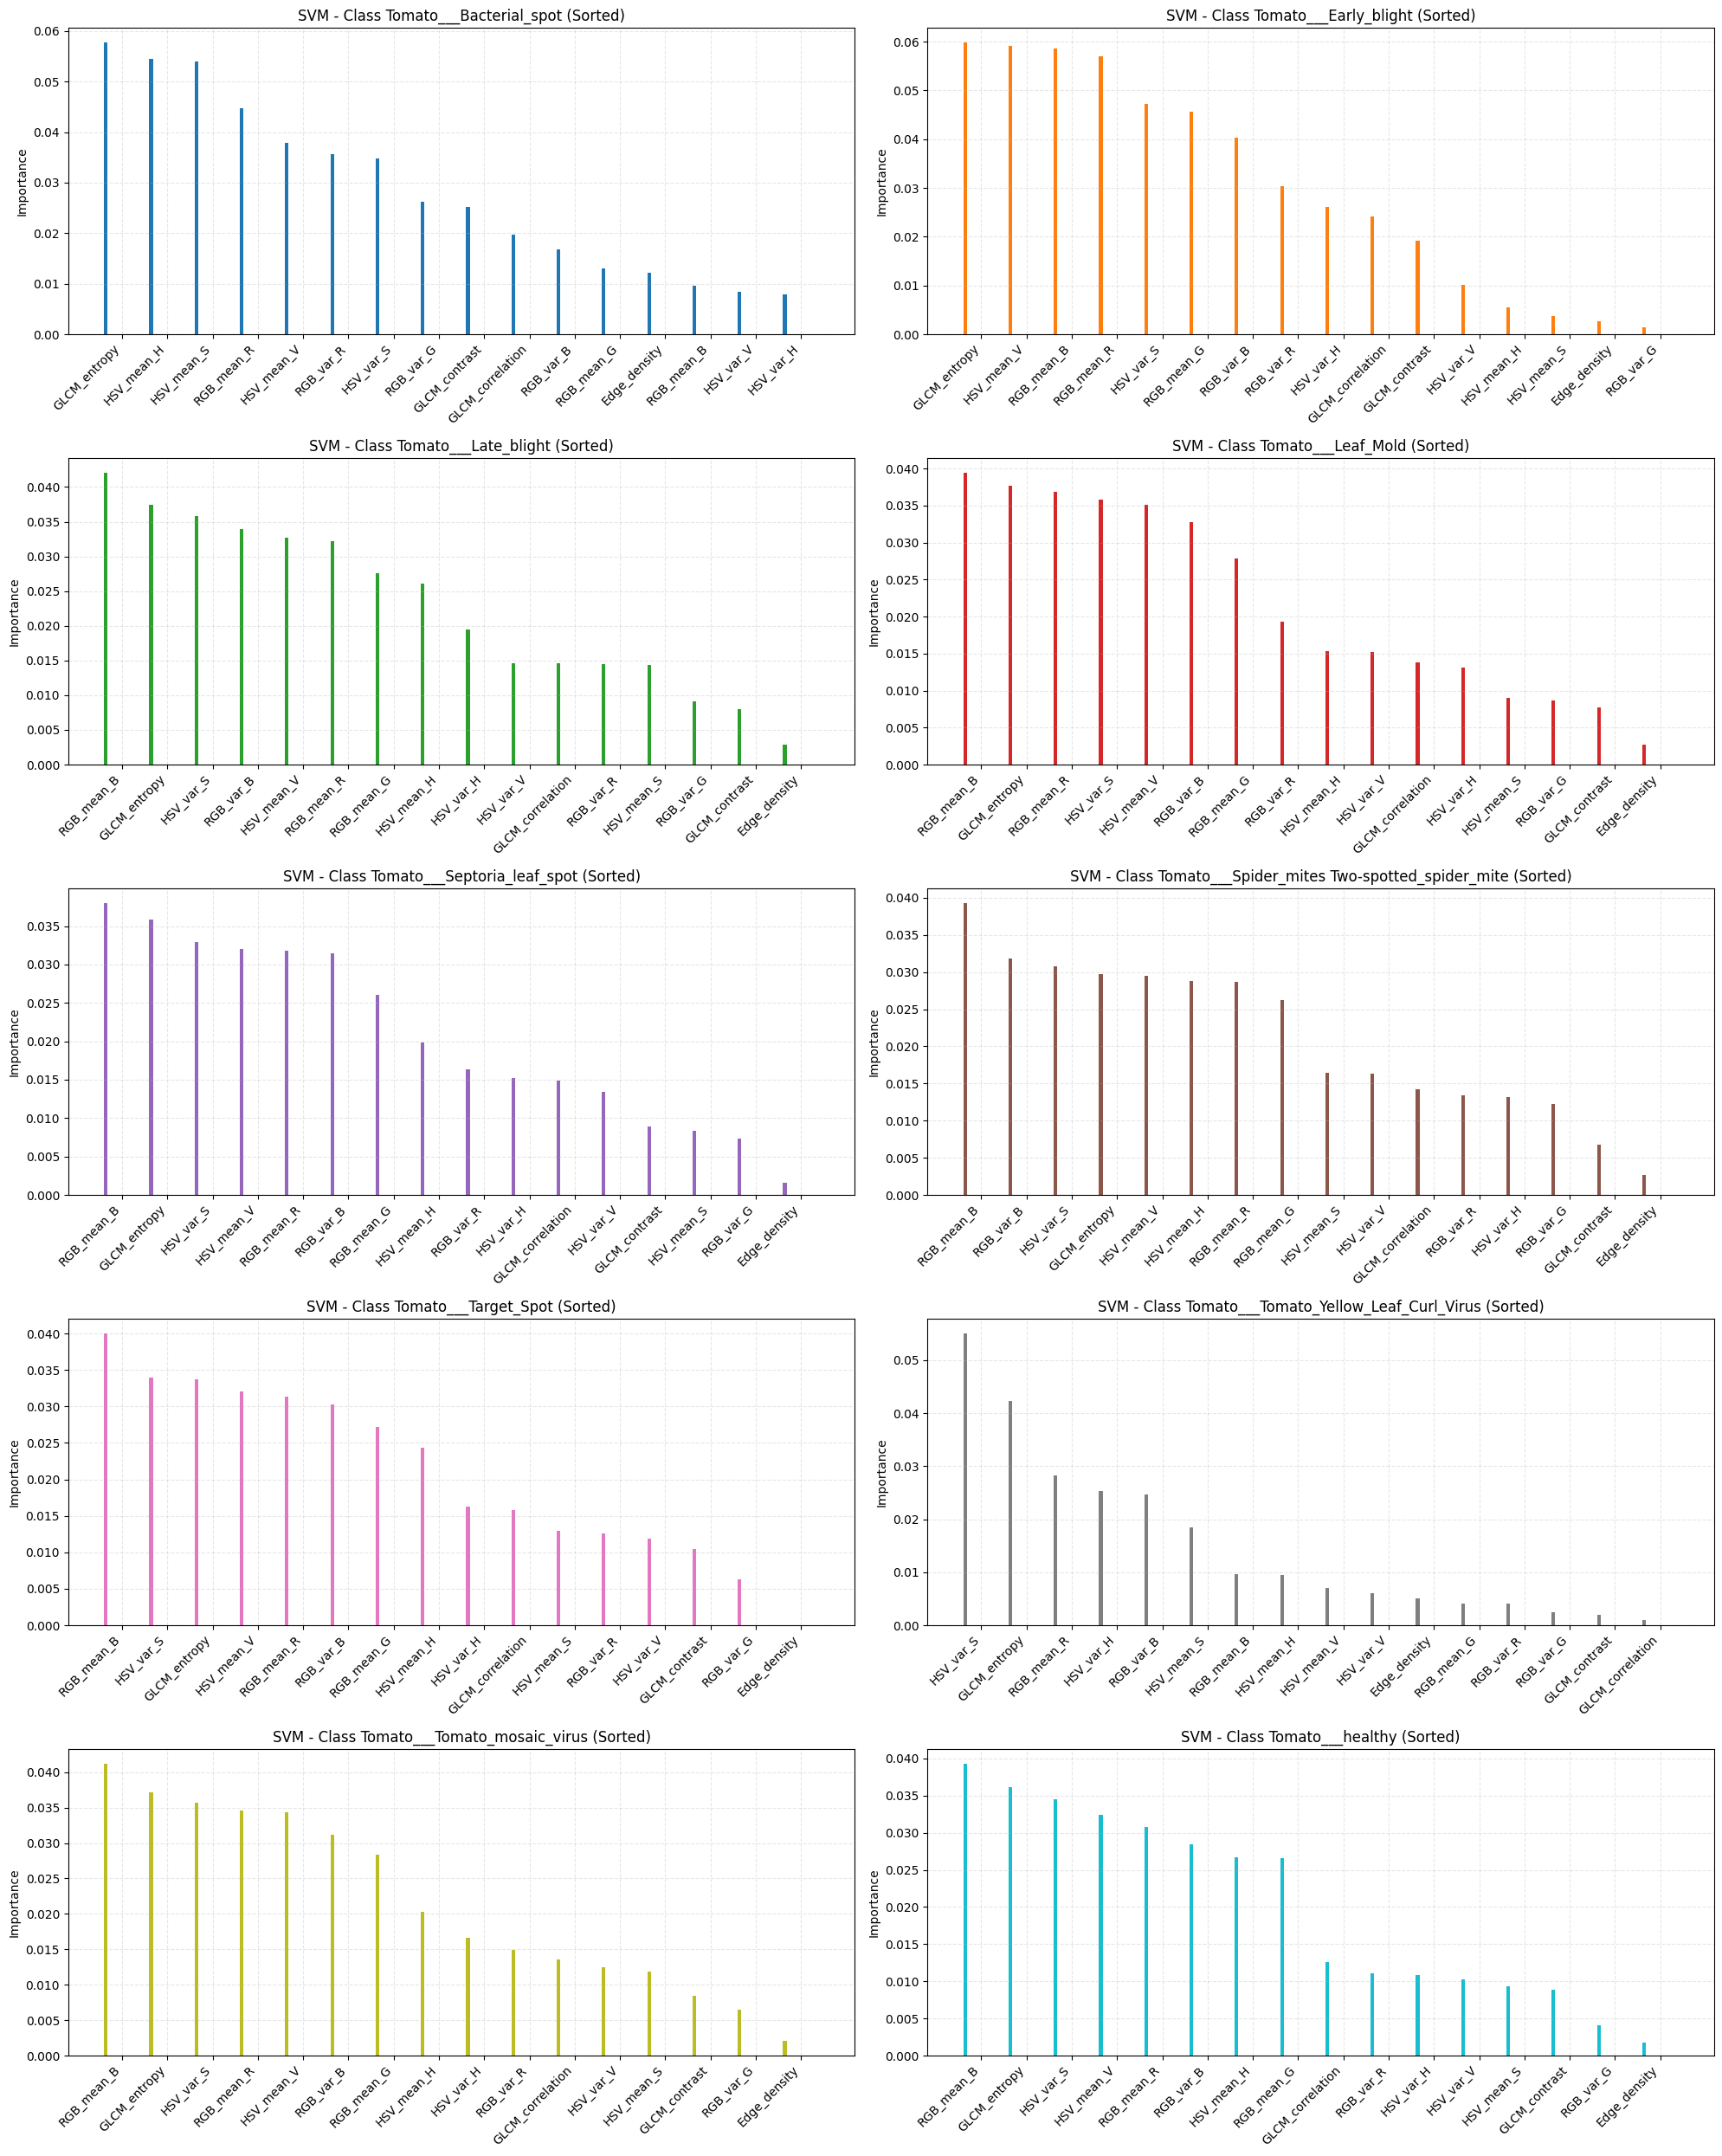


SVM Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'GLCM_entropy': np.float64(0.057721496528982924), 'HSV_mean_H': np.float64(0.05453668918393654), 'HSV_mean_S': np.float64(0.05406444800498752), 'RGB_mean_R': np.float64(0.044767313770947156), 'HSV_mean_V': np.float64(0.03786917190842785), 'RGB_var_R': np.float64(0.03560946472363746), 'HSV_var_S': np.float64(0.03471510308872989), 'RGB_var_G': np.float64(0.026290077461485848), 'GLCM_contrast': np.float64(0.025257278153109894), 'GLCM_correlation': np.float64(0.019636272509991105), 'RGB_var_B': np.float64(0.016844428950480536), 'RGB_mean_G': np.float64(0.01303741750920872), 'Edge_density': np.float64(0.012196207411375823), 'RGB_mean_B': np.float64(0.009518999120532584), 'HSV_var_V': np.float64(0.008464671621012929), 'HSV_var_H': np.float64(0.007799504014397314)}
Class Tomato___Early_blight: {'GLCM_entropy': np.float64(0.05982215533426377), 'HSV_mean_V': np.float64(0.05913932402720767), 'RGB_mean_

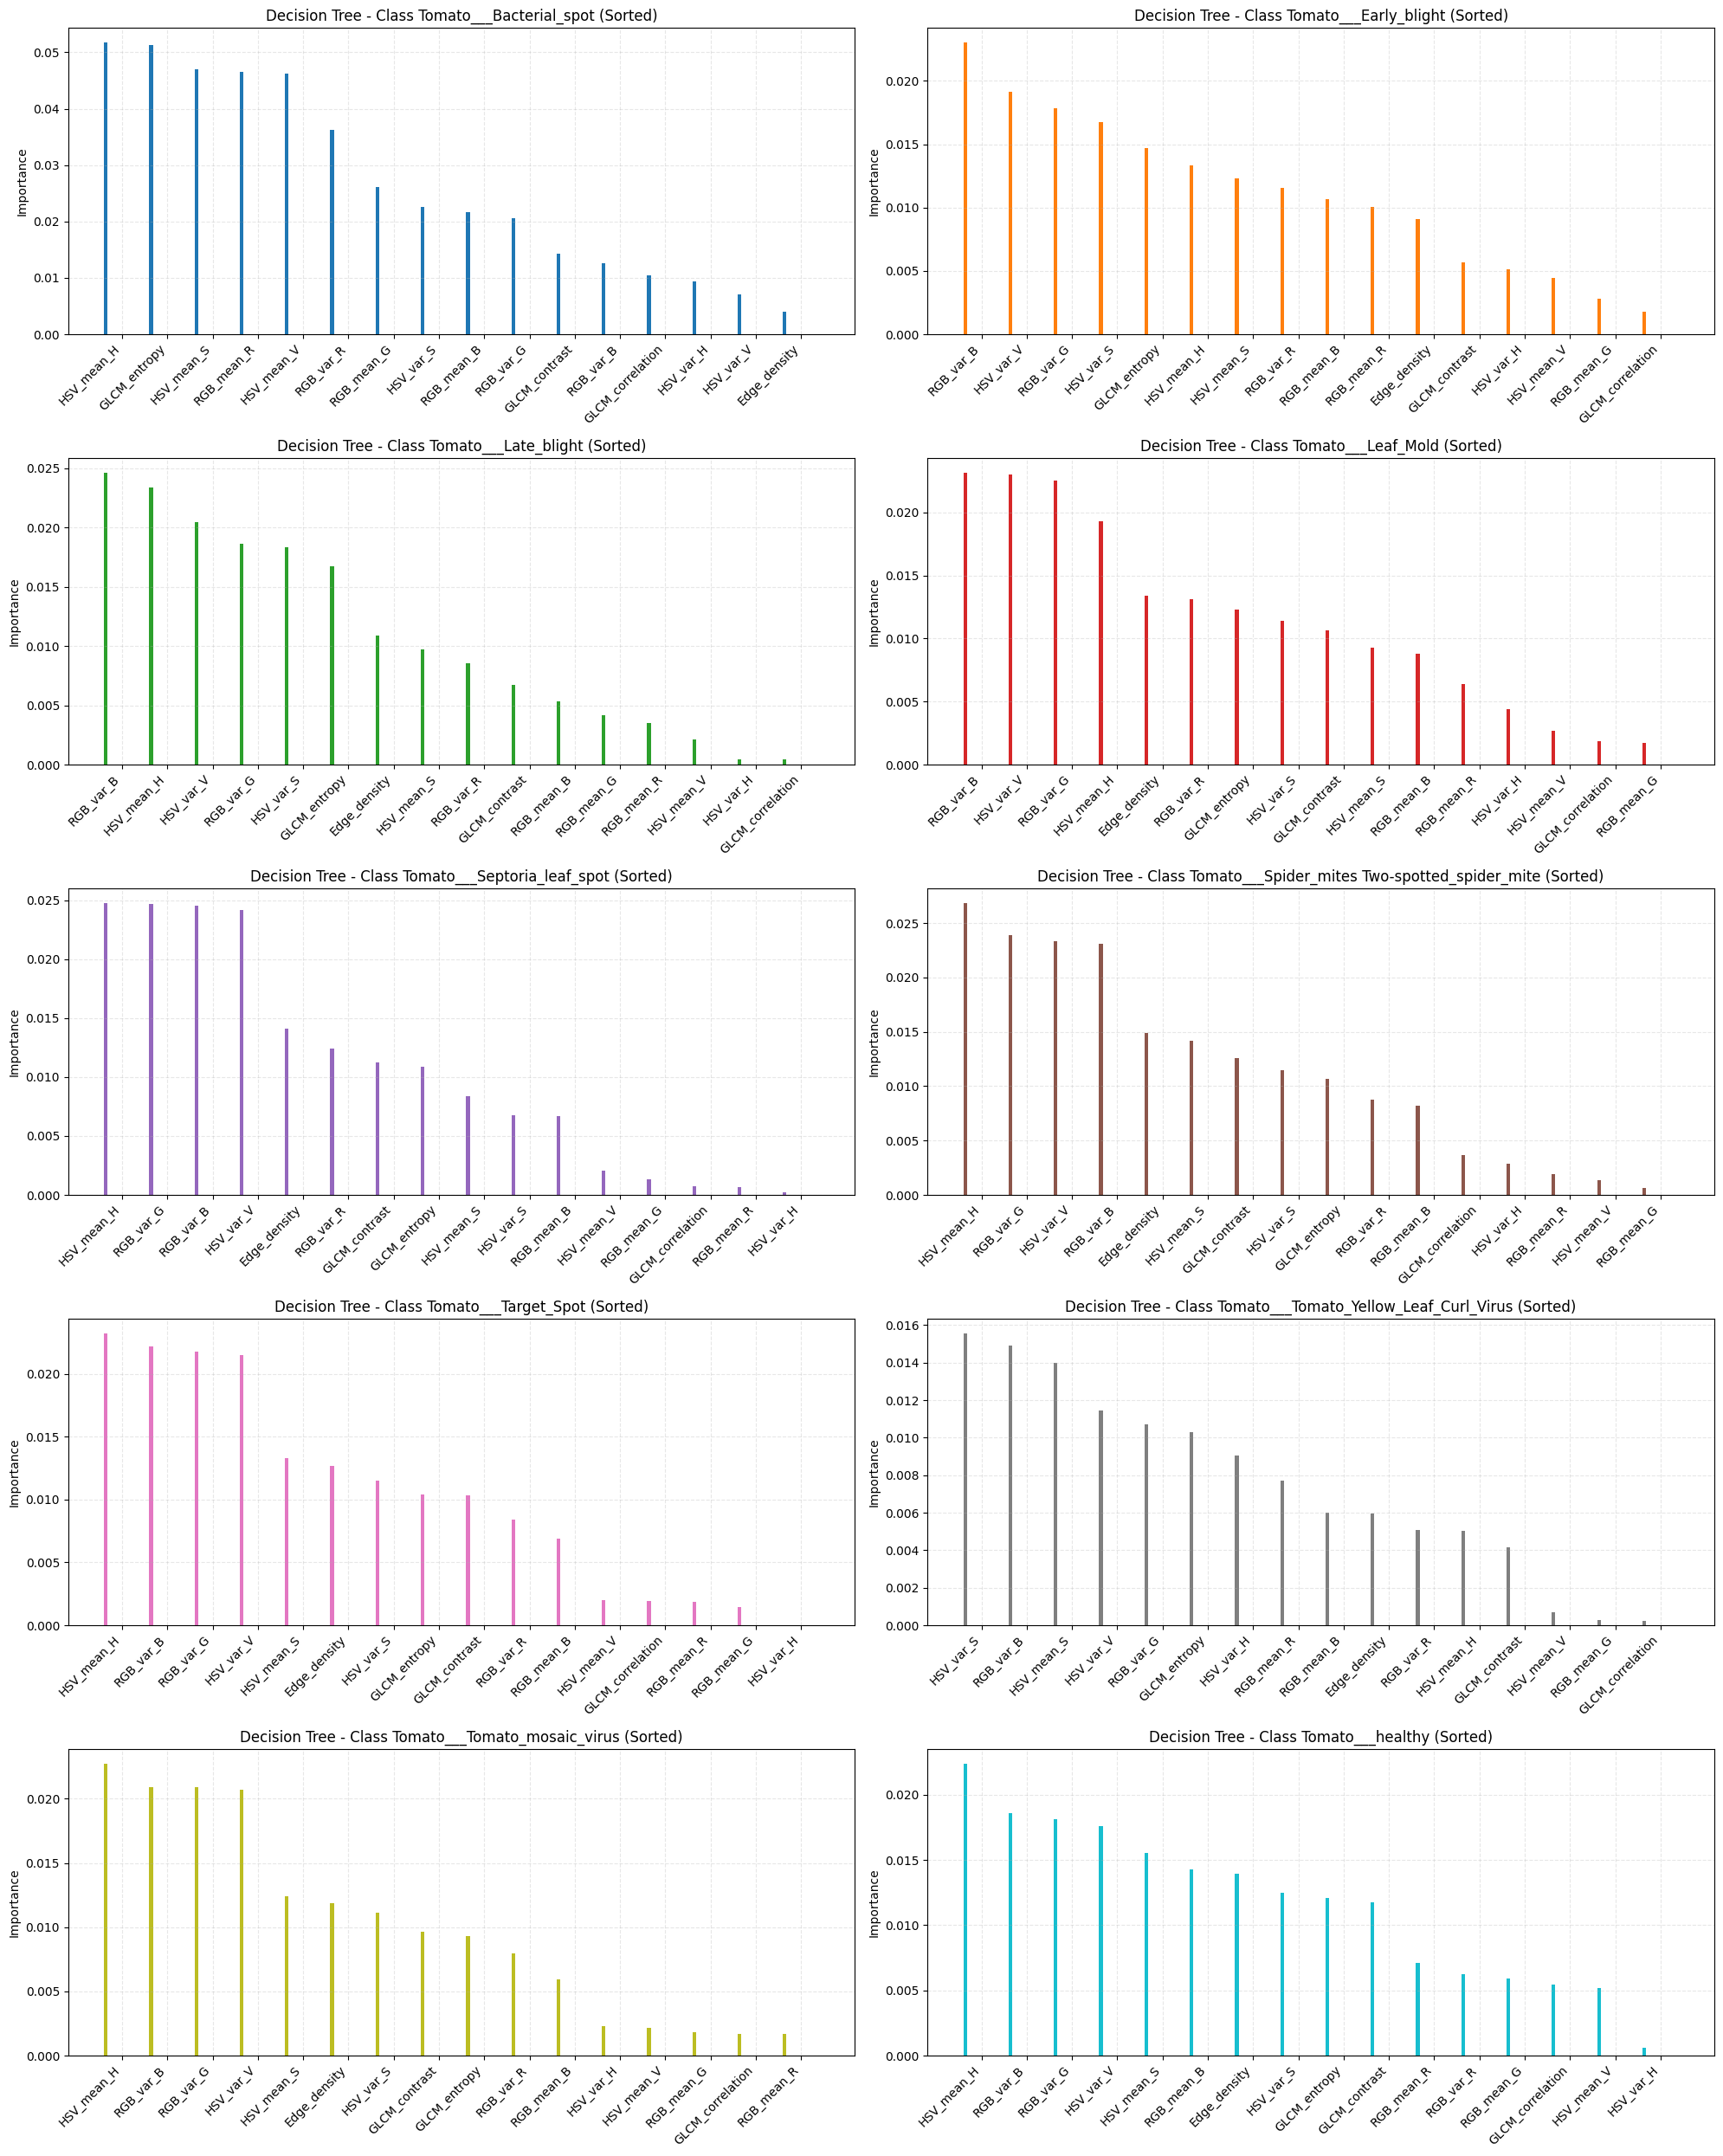


Decision Tree Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'HSV_mean_H': np.float64(0.051733914019842744), 'GLCM_entropy': np.float64(0.05123622710117406), 'HSV_mean_S': np.float64(0.04695567533036879), 'RGB_mean_R': np.float64(0.04653718358156647), 'HSV_mean_V': np.float64(0.04617093625957821), 'RGB_var_R': np.float64(0.03617965978841235), 'RGB_mean_G': np.float64(0.02610328268977082), 'HSV_var_S': np.float64(0.022535873377199093), 'RGB_mean_B': np.float64(0.021681862258483554), 'RGB_var_G': np.float64(0.02064944377690186), 'GLCM_contrast': np.float64(0.014341478826411697), 'RGB_var_B': np.float64(0.012527696345592976), 'GLCM_correlation': np.float64(0.010450228294223353), 'HSV_var_H': np.float64(0.009307283692828615), 'HSV_var_V': np.float64(0.006998317676162146), 'Edge_density': np.float64(0.003974140894318023)}
Class Tomato___Early_blight: {'RGB_var_B': np.float64(0.023020307466468753), 'HSV_var_V': np.float64(0.019119504721286804), 'RG

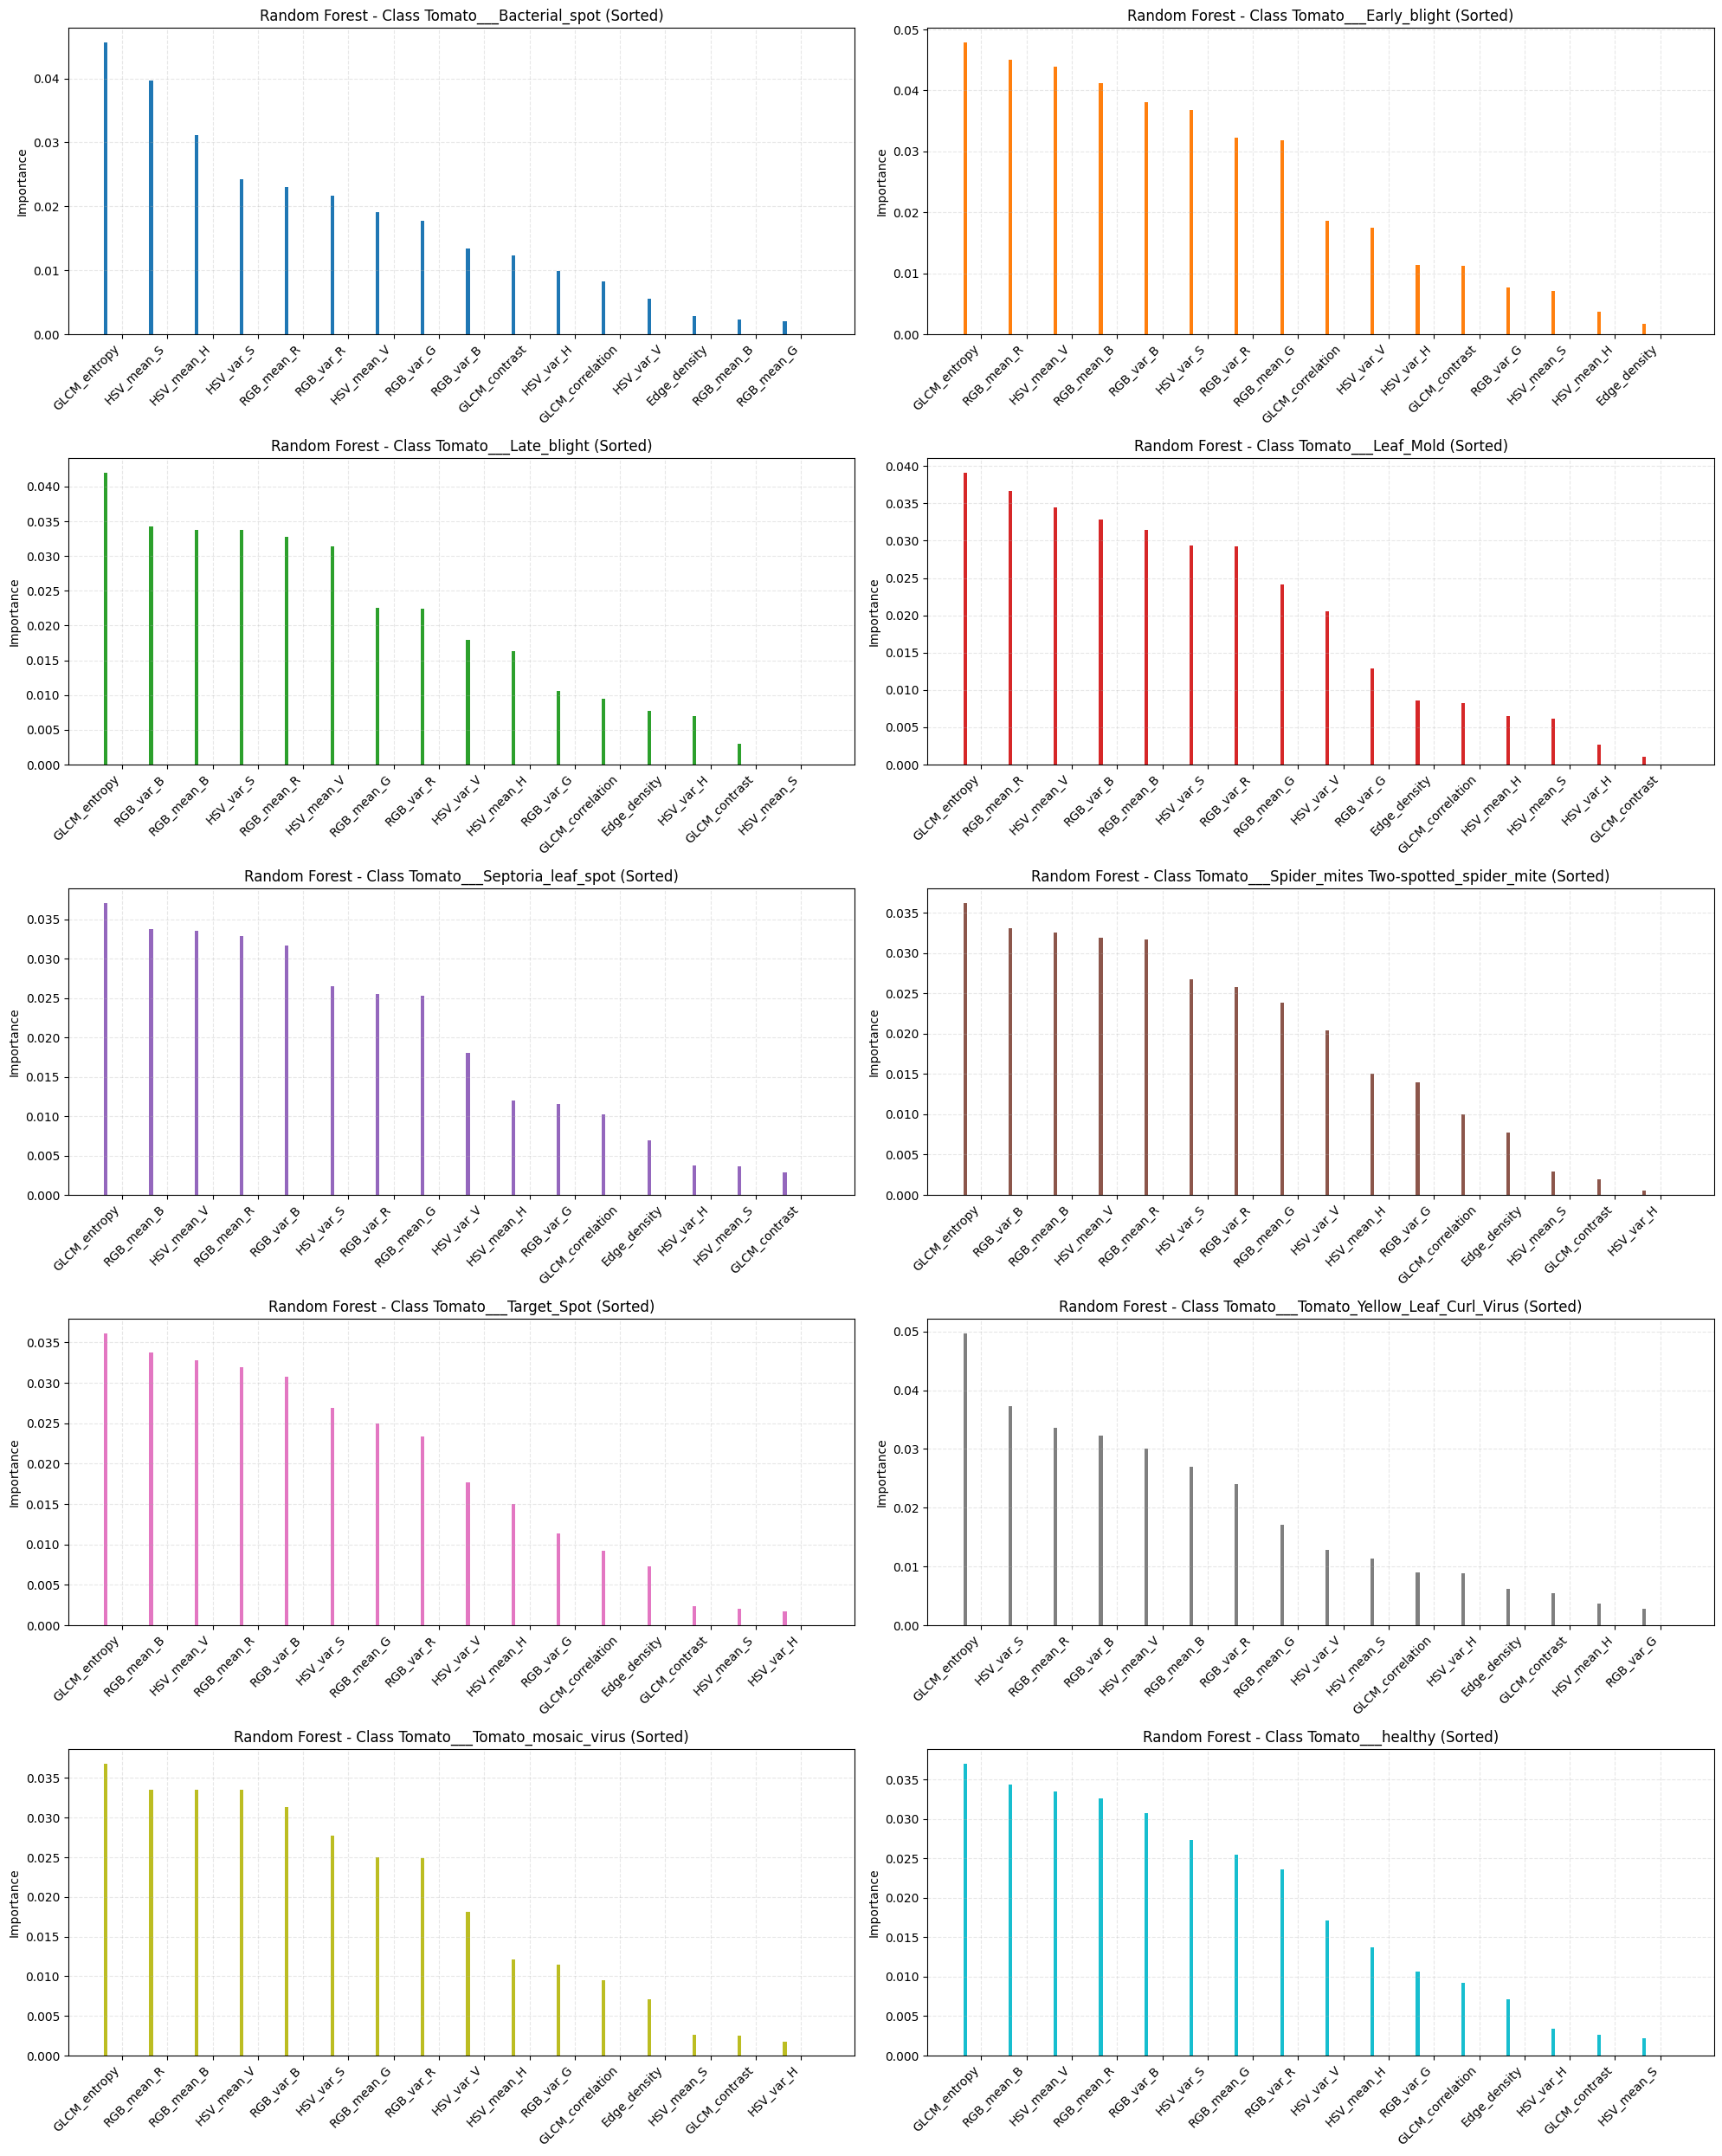


Random Forest Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'GLCM_entropy': np.float64(0.04561630931228307), 'HSV_mean_S': np.float64(0.03971892380305406), 'HSV_mean_H': np.float64(0.031151417510752497), 'HSV_var_S': np.float64(0.024290007896387633), 'RGB_mean_R': np.float64(0.02298803842471262), 'RGB_var_R': np.float64(0.021720817663845322), 'HSV_mean_V': np.float64(0.019042149430095023), 'RGB_var_G': np.float64(0.017750284065978873), 'RGB_var_B': np.float64(0.013383934097715879), 'GLCM_contrast': np.float64(0.012319162479157455), 'HSV_var_H': np.float64(0.009836701434178734), 'GLCM_correlation': np.float64(0.008217545455698866), 'HSV_var_V': np.float64(0.005522978979576208), 'Edge_density': np.float64(0.0028536272175083985), 'RGB_mean_B': np.float64(0.002292136729257299), 'RGB_mean_G': np.float64(0.0019831784827955903)}
Class Tomato___Early_blight: {'GLCM_entropy': np.float64(0.047850801162839185), 'RGB_mean_R': np.float64(0.04501779364307

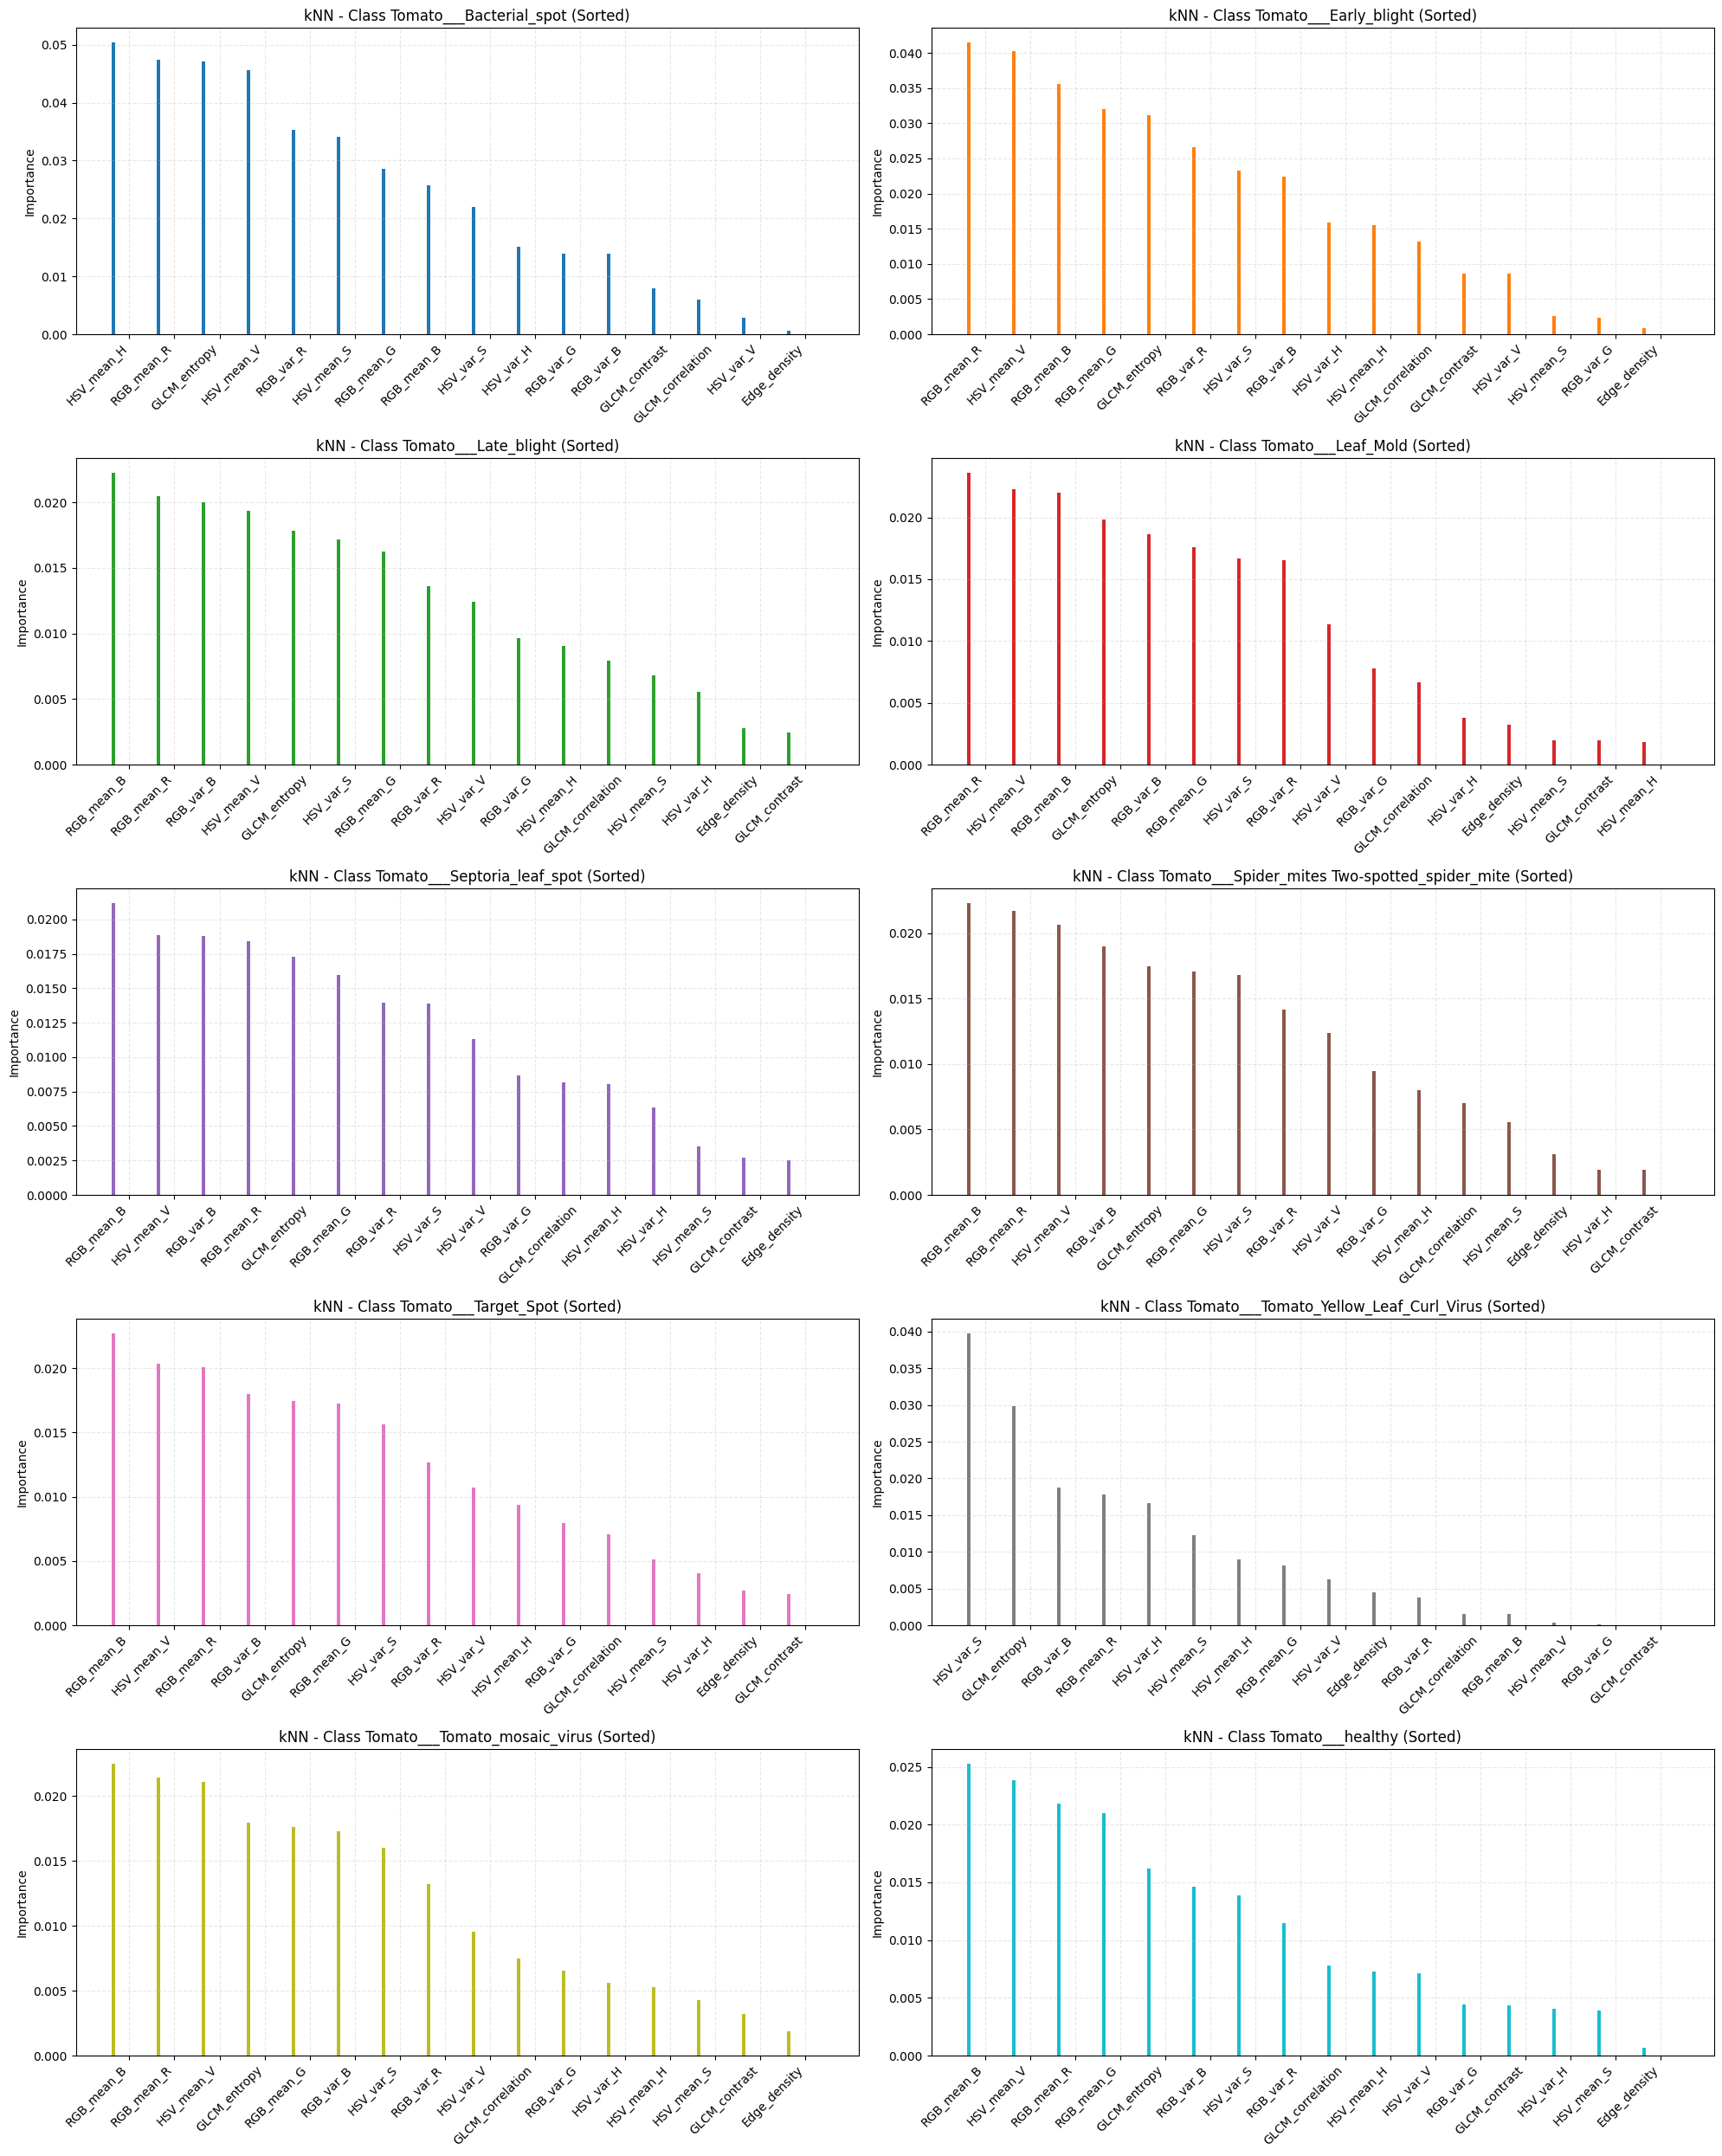


kNN Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'HSV_mean_H': np.float64(0.050385408618237086), 'RGB_mean_R': np.float64(0.04742461239368808), 'GLCM_entropy': np.float64(0.047140154131746756), 'HSV_mean_V': np.float64(0.045572747297601586), 'RGB_var_R': np.float64(0.03533099637601325), 'HSV_mean_S': np.float64(0.0340443767769933), 'RGB_mean_G': np.float64(0.028547621592978377), 'RGB_mean_B': np.float64(0.02573970253578562), 'HSV_var_S': np.float64(0.021943398890182667), 'HSV_var_H': np.float64(0.01507139325072323), 'RGB_var_G': np.float64(0.013987759705107313), 'RGB_var_B': np.float64(0.013949028362783672), 'GLCM_contrast': np.float64(0.007941890189299609), 'GLCM_correlation': np.float64(0.006005543559613446), 'HSV_var_V': np.float64(0.0028606129309383197), 'Edge_density': np.float64(0.0006317271250941628)}
Class Tomato___Early_blight: {'RGB_mean_R': np.float64(0.041478749178826824), 'HSV_mean_V': np.float64(0.04030037596175301), 'RGB_mean

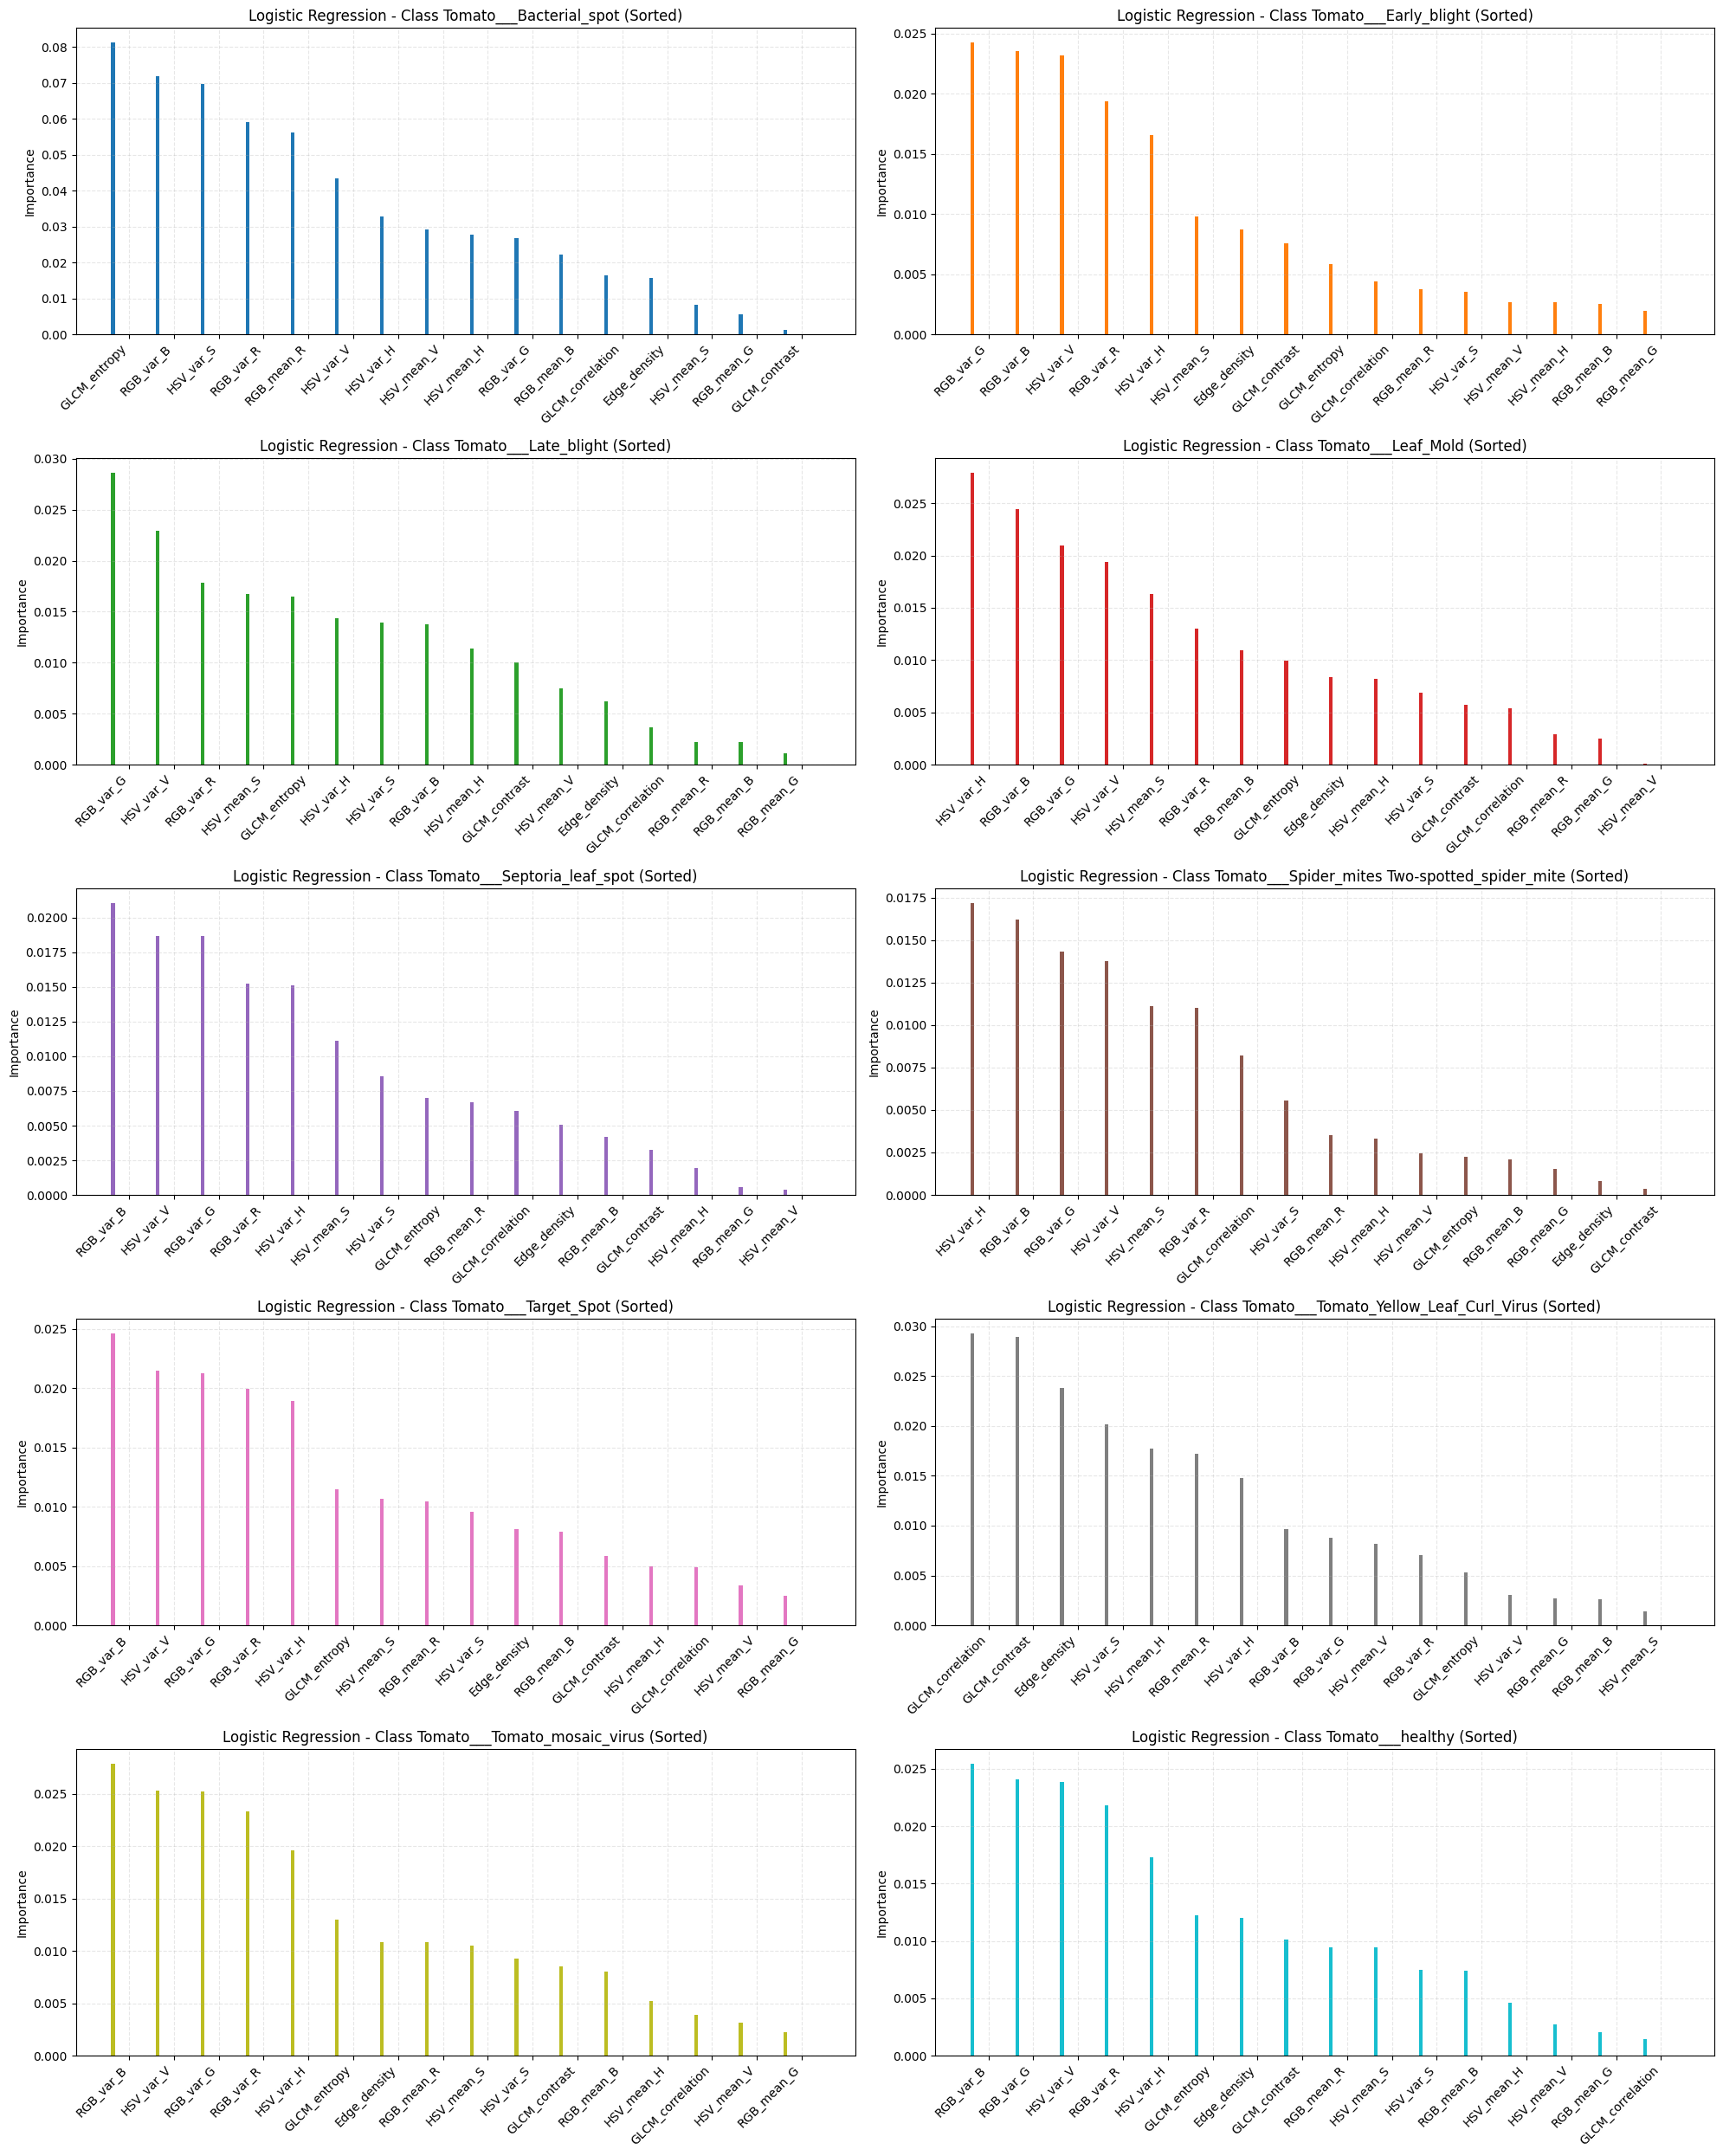


Logistic Regression Per-Class Feature Importance (Original Features, Sorted):
Class Tomato___Bacterial_spot: {'GLCM_entropy': np.float64(0.08124042465956553), 'RGB_var_B': np.float64(0.07193917778660427), 'HSV_var_S': np.float64(0.06965927835265559), 'RGB_var_R': np.float64(0.0591703103573562), 'RGB_mean_R': np.float64(0.05624416575079101), 'HSV_var_V': np.float64(0.043296066555035116), 'HSV_var_H': np.float64(0.03284318321815349), 'HSV_mean_V': np.float64(0.029142043067685107), 'HSV_mean_H': np.float64(0.02769757227444285), 'RGB_var_G': np.float64(0.026754298327056125), 'RGB_mean_B': np.float64(0.022152926418180632), 'GLCM_correlation': np.float64(0.01639646132236542), 'Edge_density': np.float64(0.015624421287611556), 'HSV_mean_S': np.float64(0.008210699193962022), 'RGB_mean_G': np.float64(0.005534931028555375), 'GLCM_contrast': np.float64(0.0011685673577941334)}
Class Tomato___Early_blight: {'RGB_var_G': np.float64(0.024241128520883976), 'RGB_var_B': np.float64(0.023536298360514147)

In [24]:
## Block 21: Per-Class Feature Importance with Sorted Plots
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
import os
import pickle  # Added for pickle.load


# Wrapper for PyTorch NN to make it scikit-learn compatible
class NNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, device="cpu"):
        self.model = model
        self.device = device

    def fit(self, X, y):
        return self  # Already trained

    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            preds = torch.argmax(outputs, dim=1)
        return preds.cpu().numpy()

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = torch.softmax(outputs, dim=1)
        return probs.cpu().numpy()


def compute_per_class_feature_importance(
    model, X, y, model_name, pca, le, num_classes=10
):
    original_features = [
        "RGB_mean_R",
        "RGB_mean_G",
        "RGB_mean_B",
        "RGB_var_R",
        "RGB_var_G",
        "RGB_var_B",
        "HSV_mean_H",
        "HSV_mean_S",
        "HSV_mean_V",
        "HSV_var_H",
        "HSV_var_S",
        "HSV_var_V",
        "GLCM_contrast",
        "GLCM_correlation",
        "GLCM_entropy",
        "Edge_density",
    ]
    class_names = le.classes_
    per_class_importance_pca = []
    per_class_importance_orig = []

    # Wrap NN model if needed
    if model_name == "Neural Network":
        model = NNWrapper(model, device="cpu")

    # Compute permutation importance for each class (One-vs-Rest)
    for class_idx in range(num_classes):
        if np.sum(y == class_idx) == 0:
            print(
                f"Warning: Class {class_names[class_idx]} has no samples in y. Assigning zero importance."
            )
            per_class_importance_pca.append(np.zeros(X.shape[1]))
            per_class_importance_orig.append(np.zeros(len(original_features)))
            continue

        # Create binary labels for One-vs-Rest
        y_binary = (y == class_idx).astype(int)

        # Compute permutation importance with weighted F1 score
        try:
            result = permutation_importance(
                model,
                X,
                y_binary,
                n_repeats=5,
                random_state=42,
                n_jobs=1,
                scoring="f1_weighted",
            )
            importance_pca = result.importances_mean
            print(
                f"{model_name} Class {class_names[class_idx]} PCA Importance shape: {importance_pca.shape}"
            )

            # Map to original features using PCA loadings
            if importance_pca.shape[0] != pca.n_components_:
                print(
                    f"Error: Importance shape {importance_pca.shape} does not match PCA components {pca.n_components_}"
                )
                importance_orig = np.zeros(len(original_features))
            else:
                importance_orig = np.abs(pca.components_.T @ importance_pca)
                print(
                    f"{model_name} Class {class_names[class_idx]} Original Importance shape: {importance_orig.shape}"
                )
                # Check for non-zero importance
                if np.all(importance_pca == 0):
                    print(
                        f"Warning: Zero importance for {model_name} Class {class_names[class_idx]}. Check model predictions."
                    )

            per_class_importance_pca.append(importance_pca)
            per_class_importance_orig.append(importance_orig)
        except Exception as e:
            print(
                f"Error computing importance for {model_name} Class {class_names[class_idx]}: {e}"
            )
            per_class_importance_pca.append(np.zeros(X.shape[1]))
            per_class_importance_orig.append(np.zeros(len(original_features)))

    # Plot per-class feature importance (sorted)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    fig, axes = plt.subplots(5, 2, figsize=(20, 25), dpi=100)
    axes = axes.flatten()

    for class_idx in range(num_classes):
        ax = axes[class_idx]
        importance_orig = per_class_importance_orig[class_idx]

        # Sort features by importance
        orig_indices = np.argsort(importance_orig)[::-1]  # Descending order
        sorted_orig_features = [original_features[i] for i in orig_indices]
        sorted_importance_orig = importance_orig[orig_indices]

        # Bar plot for sorted original features
        bars = ax.bar(
            range(len(sorted_orig_features)),
            sorted_importance_orig,
            color=colors[class_idx],
        )
        ax.set_xticks(range(len(sorted_orig_features)))
        ax.set_xticklabels(sorted_orig_features, rotation=45, ha="right", fontsize=10)
        ax.set_title(
            f"{model_name} - Class {class_names[class_idx]} (Sorted)", fontsize=12
        )
        ax.set_ylabel("Importance", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.3)

        # Adjust bar width for visibility
        for bar in bars:
            bar.set_width(0.08)

    plt.tight_layout()
    save_path = f"{model_name.lower().replace(' ', '_')}_per_class_feature_importance_sorted.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Print sorted per-class importance
    print(f"\n{model_name} Per-Class Feature Importance (Original Features, Sorted):")
    for class_idx in range(num_classes):
        orig_indices = np.argsort(per_class_importance_orig[class_idx])[::-1]
        sorted_orig_features = [original_features[i] for i in orig_indices]
        sorted_importance_orig = per_class_importance_orig[class_idx][orig_indices]
        print(
            f"Class {class_names[class_idx]}: {dict(zip(sorted_orig_features, sorted_importance_orig))}"
        )

    # Save results
    np.save(
        f"{model_name.lower().replace(' ', '_')}_per_class_importance_pca.npy",
        np.array(per_class_importance_pca),
    )
    np.save(
        f"{model_name.lower().replace(' ', '_')}_per_class_importance_orig.npy",
        np.array(per_class_importance_orig),
    )

    return per_class_importance_pca, per_class_importance_orig


# Load PCA model and label encoder
pca = pickle.load(open("pca_model.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))

# Verify class distribution in y_test
print("Class distribution in y_test:", np.bincount(y_test))

# Compute and plot per-class feature importance for all models
models = {
    "Neural Network": nn_model,
    "SVM": best_svm,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "kNN": best_knn,
    "Logistic Regression": lr,
}

for model_name, model in models.items():
    # For SVM with linear kernel, use coefficients for importance
    if model_name == "SVM" and hasattr(model, "kernel") and model.kernel == "linear":
        print(f"Computing {model_name} importance using coefficients...")
        per_class_importance_pca = np.abs(model.coef_)
        per_class_importance_orig = np.abs(
            pca.components_.T @ per_class_importance_pca.T
        ).T
        print(
            f"{model_name} Per-Class PCA Importance shape: {per_class_importance_pca.shape}"
        )
        print(
            f"{model_name} Per-Class Original Importance shape: {per_class_importance_orig.shape}"
        )

        # Plot sorted
        colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
        fig, axes = plt.subplots(5, 2, figsize=(20, 25), dpi=100)
        axes = axes.flatten()
        for class_idx in range(num_classes):
            ax = axes[class_idx]
            importance_orig = per_class_importance_orig[class_idx]
            # Sort features by importance
            orig_indices = np.argsort(importance_orig)[::-1]
            sorted_orig_features = [original_features[i] for i in orig_indices]
            sorted_importance_orig = importance_orig[orig_indices]
            # Bar plot for sorted original features
            bars = ax.bar(
                range(len(sorted_orig_features)),
                sorted_importance_orig,
                color=colors[class_idx],
            )
            ax.set_xticks(range(len(sorted_orig_features)))
            ax.set_xticklabels(
                sorted_orig_features, rotation=45, ha="right", fontsize=10
            )
            ax.set_title(
                f"{model_name} - Class {le.classes_[class_idx]} (Sorted)", fontsize=12
            )
            ax.set_ylabel("Importance (Abs Coef)", fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.3)
            for bar in bars:
                bar.set_width(0.08)
        plt.tight_layout()
        save_path = f"{model_name.lower().replace(' ', '_')}_per_class_feature_importance_sorted.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        # Print and save sorted
        print(
            f"\n{model_name} Per-Class Feature Importance (Original Features, Sorted):"
        )
        for class_idx in range(num_classes):
            orig_indices = np.argsort(per_class_importance_orig[class_idx])[::-1]
            sorted_orig_features = [original_features[i] for i in orig_indices]
            sorted_importance_orig = per_class_importance_orig[class_idx][orig_indices]
            print(
                f"Class {le.classes_[class_idx]}: {dict(zip(sorted_orig_features, sorted_importance_orig))}"
            )
        np.save(
            f"{model_name.lower().replace(' ', '_')}_per_class_importance_pca.npy",
            per_class_importance_pca,
        )
        np.save(
            f"{model_name.lower().replace(' ', '_')}_per_class_importance_orig.npy",
            per_class_importance_orig,
        )
    else:
        # Use permutation importance for non-linear models
        per_class_importance_pca, per_class_importance_orig = (
            compute_per_class_feature_importance(
                model, X_test, y_test, model_name, pca, le, num_classes=10
            )
        )

In [35]:
import pickle
import numpy as np


def predict_disease(image_path, scaler, pca, model, le):
    img = cv2.imread(image_path)
    features = extract_features(img)  # From Block 3
    features_scaled = scaler.transform([features])
    features_pca = pca.transform(features_scaled)
    pred = model.predict(features_pca)
    return le.inverse_transform(pred)[0]


scaler = pickle.load(open("scaler.pkl", "rb"))
pca = pickle.load(open("pca_model.pkl", "rb"))
model = pickle.load(open("svm_model.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))
print(predict_disease("2.jpg", scaler, pca, model, le))

Tomato___Tomato_Yellow_Leaf_Curl_Virus
